In [1]:
# ============================================================
# 0. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. LOAD THE SINGLE FIVE-COUNTRY CSV

Change only the filename/path below if your CSV has a different name.

The same `df` dataframe will be used throughout the complete project.

In [3]:
# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv('datasets/fanta_5_countries_cleaned.csv')


print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (1059, 14)


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0024622511676,"Pepe's, Fantastico Chicharrones",Rudolph Foods Company Inc.,Unknown,united-states,Unknown,Unknown,Unknown,unknown,Unknown,unknown,"Pork fat with attached skin, salt.",Unknown,571.0
1,0035266007265,"Tastee, White Pretzel Wonder Fantasy",Tastee Apple Inc.,"plant-based-foods-and-beverages, plant-based-foods, fruits-and-vegetables-based-foods",united-states,Unknown,Unknown,Unknown,d,4.0,unknown,"Apple, caramel (corn syrup, sugar, condensed milk (milk, sucrose), hydrogenated palm oil, evaporated milk (disodium ...",28.57,232.0
2,0041321016141,Fantastico light cheese dressing,Bernstein's,"condiments, sauces, salad-dressings, groceries",united-states,Unknown,Unknown,Unknown,d,4.0,Unknown,"Water, distilled vinegar, soybean oil, salt, maltodextrin, parmesan cheese (pasteurized part skim milk, cheese cultu...",3.23,80.65
3,0041497131815,Oriental Fantasy Mix,"Weis, Weis Markets Inc.",undefined,united-states,Unknown,Unknown,Unknown,d,3.0,Unknown,"ROASTED & SALTED (ALMONDS, SPANISH PEANUTS, CASHEWS, SOY NUTS), ROASTED NO SALT (PUMPKIN SEEDS SHELLED), CORN NUTS, ...",12.7,1950.0
4,0481290024608,"Truffle Fantaisie Cacao Powdered Truffles, Plain",Alaus Mathez Chocolatier,Unknown,united-states,Unknown,Unknown,Unknown,unknown,4.0,unknown,"Vegetable fats (coconut, palm kernel), sugar, fat reduced cocoa powder, whey powder, cocoa powder, emulsifier: soya ...",42.5,575.0


## 2. INITIAL DATASET INSPECTION

Before analysis, inspect dimensions, columns, data types, duplicates, and missing values.

In [4]:
# ============================================================
# 2. INITIAL INSPECTION
# ============================================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

Dataset Shape: (1059, 14)

Column Names:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']

Data Types:


code                           object
product_name                   object
brands                         object
categories_tags                object
countries_tags                 object
packaging_tags                 object
stores                         object
purchase_places                object
nutriscore_grade               object
nova_group                     object
ecoscore_grade                 object
ingredients_text               object
nutriments.sugars_100g         object
nutriments.energy-kcal_100g    object
dtype: object


First 5 Records:


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0024622511676,"Pepe's, Fantastico Chicharrones",Rudolph Foods Company Inc.,Unknown,united-states,Unknown,Unknown,Unknown,unknown,Unknown,unknown,"Pork fat with attached skin, salt.",Unknown,571.0
1,0035266007265,"Tastee, White Pretzel Wonder Fantasy",Tastee Apple Inc.,"plant-based-foods-and-beverages, plant-based-foods, fruits-and-vegetables-based-foods",united-states,Unknown,Unknown,Unknown,d,4.0,unknown,"Apple, caramel (corn syrup, sugar, condensed milk (milk, sucrose), hydrogenated palm oil, evaporated milk (disodium ...",28.57,232.0
2,0041321016141,Fantastico light cheese dressing,Bernstein's,"condiments, sauces, salad-dressings, groceries",united-states,Unknown,Unknown,Unknown,d,4.0,Unknown,"Water, distilled vinegar, soybean oil, salt, maltodextrin, parmesan cheese (pasteurized part skim milk, cheese cultu...",3.23,80.65
3,0041497131815,Oriental Fantasy Mix,"Weis, Weis Markets Inc.",undefined,united-states,Unknown,Unknown,Unknown,d,3.0,Unknown,"ROASTED & SALTED (ALMONDS, SPANISH PEANUTS, CASHEWS, SOY NUTS), ROASTED NO SALT (PUMPKIN SEEDS SHELLED), CORN NUTS, ...",12.7,1950.0
4,0481290024608,"Truffle Fantaisie Cacao Powdered Truffles, Plain",Alaus Mathez Chocolatier,Unknown,united-states,Unknown,Unknown,Unknown,unknown,4.0,unknown,"Vegetable fats (coconut, palm kernel), sugar, fat reduced cocoa powder, whey powder, cocoa powder, emulsifier: soya ...",42.5,575.0



Duplicate Rows: 0

Missing Values:


,Missing_Count
code,0
product_name,0
brands,0
categories_tags,0
countries_tags,0
packaging_tags,0
stores,0
purchase_places,0
nutriscore_grade,0
nova_group,0


## 3. STANDARDIZE MISSING VALUES

As requested, all null/blank values are represented as `Unknown`.

This keeps the original five-country dataset together and avoids creating multiple CSV files.

In [5]:
# ============================================================
# 3. FILL NULL / BLANK VALUES WITH UNKNOWN
# ============================================================

# Replace actual null values
df = df.fillna("Unknown")

# Replace empty and whitespace-only strings
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace(
            r"^\s*$",
            "Unknown",
            regex=True
        )

print("Null/blank values have been replaced with 'Unknown'.")
print("Remaining NaN values:", df.isna().sum().sum())

Null/blank values have been replaced with 'Unknown'.
Remaining NaN values: 0


## 4. CHECK ALL ATTRIBUTES AFTER CLEANING

This gives an attribute-level view of the complete dataset before country-wise analysis.

In [6]:
# ============================================================
# 4. COMPLETE ATTRIBUTE PROFILE
# ============================================================

attribute_profile = pd.DataFrame({
    "Attribute": df.columns,
    "Data_Type": [df[c].dtype for c in df.columns],
    "Unique_Values": [df[c].nunique(dropna=False) for c in df.columns],
    "Unknown_Count": [
        df[c].astype(str).str.strip().str.lower().eq("unknown").sum()
        for c in df.columns
    ]
})

attribute_profile["Unknown_Percentage"] = (
    attribute_profile["Unknown_Count"] / len(df) * 100
).round(2)

display(attribute_profile)

,Attribute,Data_Type,Unique_Values,Unknown_Count,Unknown_Percentage
0,code,object,1058,0,0.00
1,product_name,object,823,10,0.94
2,brands,object,243,179,16.90
3,categories_tags,object,167,533,50.33
4,countries_tags,object,5,0,0.00
5,packaging_tags,object,30,990,93.48
6,stores,object,28,1015,95.85
7,purchase_places,object,9,1045,98.68
8,nutriscore_grade,object,8,624,58.92
9,nova_group,object,4,888,83.85


## 5. PREPARE NUMERICAL ATTRIBUTES

The nutritional columns are converted to numeric analysis columns. Invalid or `Unknown` values become `NaN` **only in these analysis columns** so statistical calculations work correctly. The original cleaned attributes remain unchanged.

In [7]:
# ============================================================
# 5. NUMERIC FEATURE PREPARATION
# ============================================================

numeric_source_columns = [
    "nutriments.sugars_100g",
    "nutriments.energy-kcal_100g",
    "nova_group"
]

for col in numeric_source_columns:
    if col in df.columns:
        df[col + "_num"] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# If numeric columns already existed from previous preprocessing,
# preserve/use them.
if "nutriments.sugars_100g_num" not in df.columns:
    if "nutriments.sugars_100g" in df.columns:
        df["nutriments.sugars_100g_num"] = pd.to_numeric(
            df["nutriments.sugars_100g"], errors="coerce"
        )

if "nutriments.energy-kcal_100g_num" not in df.columns:
    if "nutriments.energy-kcal_100g" in df.columns:
        df["nutriments.energy-kcal_100g_num"] = pd.to_numeric(
            df["nutriments.energy-kcal_100g"], errors="coerce"
        )

if "nova_group_num" not in df.columns:
    if "nova_group" in df.columns:
        df["nova_group_num"] = pd.to_numeric(
            df["nova_group"], errors="coerce"
        )

print("Numeric analysis columns prepared.")

Numeric analysis columns prepared.


#  PART 1 — UNITED STATES

The following section performs the complete country-wise analysis using the same combined dataframe.

In [8]:
# ============================================================
# PART 1: UNITED STATES DATASET
# ============================================================

us_df = df[
    df["countries_tags"].astype(str).str.lower() == "united-states"
].copy()

print("UNITED STATES DATASET")
print("=" * 60)
print("Records:", len(us_df))
print("Attributes:", len(us_df.columns))
display(us_df.head())

UNITED STATES DATASET
Records: 435
Attributes: 17


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num,nova_group_num
0,0024622511676,"Pepe's, Fantastico Chicharrones",Rudolph Foods Company Inc.,Unknown,united-states,Unknown,Unknown,Unknown,unknown,Unknown,unknown,"Pork fat with attached skin, salt.",Unknown,571.0,NaN,571.00,NaN
1,0035266007265,"Tastee, White Pretzel Wonder Fantasy",Tastee Apple Inc.,"plant-based-foods-and-beverages, plant-based-foods, fruits-and-vegetables-based-foods",united-states,Unknown,Unknown,Unknown,d,4.0,unknown,"Apple, caramel (corn syrup, sugar, condensed milk (milk, sucrose), hydrogenated palm oil, evaporated milk (disodium ...",28.57,232.0,28.57,232.00,4.0
2,0041321016141,Fantastico light cheese dressing,Bernstein's,"condiments, sauces, salad-dressings, groceries",united-states,Unknown,Unknown,Unknown,d,4.0,Unknown,"Water, distilled vinegar, soybean oil, salt, maltodextrin, parmesan cheese (pasteurized part skim milk, cheese cultu...",3.23,80.65,3.23,80.65,4.0
3,0041497131815,Oriental Fantasy Mix,"Weis, Weis Markets Inc.",undefined,united-states,Unknown,Unknown,Unknown,d,3.0,Unknown,"ROASTED & SALTED (ALMONDS, SPANISH PEANUTS, CASHEWS, SOY NUTS), ROASTED NO SALT (PUMPKIN SEEDS SHELLED), CORN NUTS, ...",12.7,1950.0,12.70,1950.00,3.0
4,0481290024608,"Truffle Fantaisie Cacao Powdered Truffles, Plain",Alaus Mathez Chocolatier,Unknown,united-states,Unknown,Unknown,Unknown,unknown,4.0,unknown,"Vegetable fats (coconut, palm kernel), sugar, fat reduced cocoa powder, whey powder, cocoa powder, emulsifier: soya ...",42.5,575.0,42.50,575.00,4.0


### United States — Detailed Attribute, Nutritional and Quality Analysis

In [9]:
# ============================================================
# UNITED STATES — BASIC OVERVIEW
# ============================================================

print("Dataset Shape:", us_df.shape)
print("\nColumn Names:")
print(us_df.columns.tolist())

print("\nData Types:")
display(us_df.dtypes)

print("\nStatistical Summary:")
display(us_df.describe(include="all").T)

Dataset Shape: (435, 17)

Column Names:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g', 'nutriments.sugars_100g_num', 'nutriments.energy-kcal_100g_num', 'nova_group_num']

Data Types:


code                                object
product_name                        object
brands                              object
categories_tags                     object
countries_tags                      object
packaging_tags                      object
stores                              object
purchase_places                     object
nutriscore_grade                    object
nova_group                          object
ecoscore_grade                      object
ingredients_text                    object
nutriments.sugars_100g              object
nutriments.energy-kcal_100g         object
nutriments.sugars_100g_num         float64
nutriments.energy-kcal_100g_num    float64
nova_group_num                     float64
dtype: object


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,435,435,5449000322203,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,435,338,Fanta,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brands,435,88,Fanta,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories_tags,435,38,"beverages-and-beverages-preparations, beverages",229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countries_tags,435,1,united-states,435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packaging_tags,435,6,Unknown,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stores,435,1,Unknown,435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_places,435,2,Unknown,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutriscore_grade,435,6,unknown,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nova_group,435,4,Unknown,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Attribute,Unknown_Count,Total_Records,Unknown_Percentage
6,stores,435,435,100.00
7,purchase_places,434,435,99.77
5,packaging_tags,429,435,98.62
10,ecoscore_grade,428,435,98.39
9,nova_group,381,435,87.59
8,nutriscore_grade,174,435,40.00
3,categories_tags,152,435,34.94
11,ingredients_text,146,435,33.56
12,nutriments.sugars_100g,109,435,25.06
13,nutriments.energy-kcal_100g,103,435,23.68


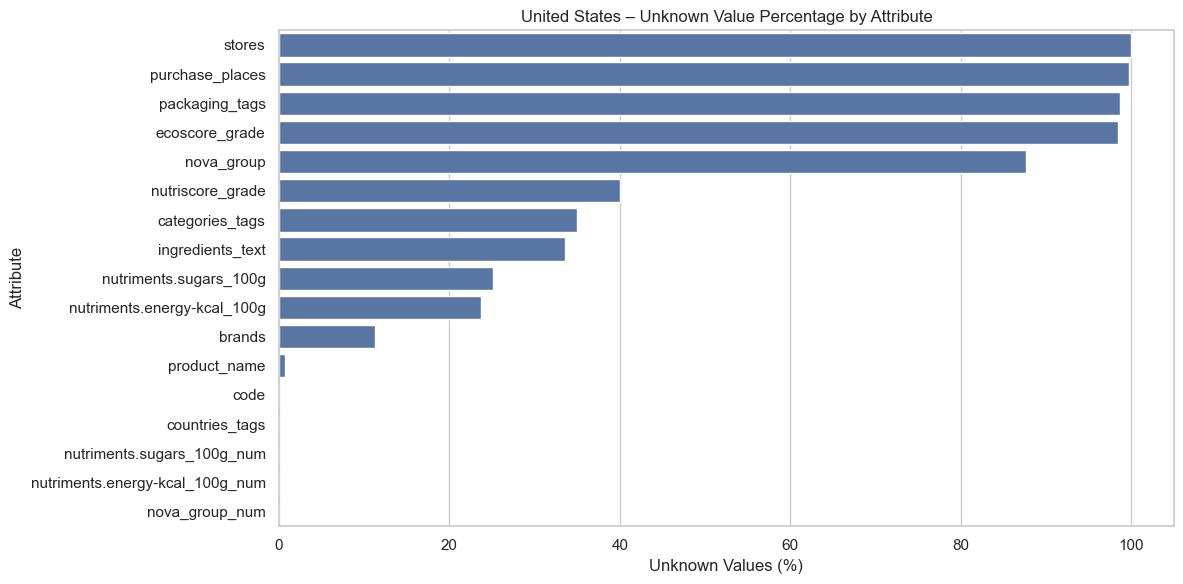

In [10]:
# ============================================================
# UNITED STATES — UNKNOWN VALUE ANALYSIS
# ============================================================

us_unknown_summary = []

for col in us_df.columns:
    unknown_count = (
        us_df[col].astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    us_unknown_summary.append({
        "Attribute": col,
        "Unknown_Count": unknown_count,
        "Total_Records": len(us_df),
        "Unknown_Percentage": round(
            unknown_count / len(us_df) * 100, 2
        )
    })

us_unknown_df = pd.DataFrame(us_unknown_summary).sort_values(
    "Unknown_Percentage", ascending=False
)

display(us_unknown_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=us_unknown_df,
            x="Unknown_Percentage", y="Attribute")
plt.title("United States – Unknown Value Percentage by Attribute")
plt.xlabel("Unknown Values (%)")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

Top 20 Products:


,Product_Name,Frequency
0,Fanta,11
1,Fanta orange,5
2,Orange soda,3
3,Strawberry Fanta,3
4,Monster Energy Ultra Fantasy Ruby Red,3
5,Tropical fantasy,3
6,Tropical Fantasy,3
7,Unknown,3
8,Fantasy Mix,3
9,Fanta lemon,2


Total Product Records: 435
Unique Products: 338
Product Uniqueness Rate: 77.7 %


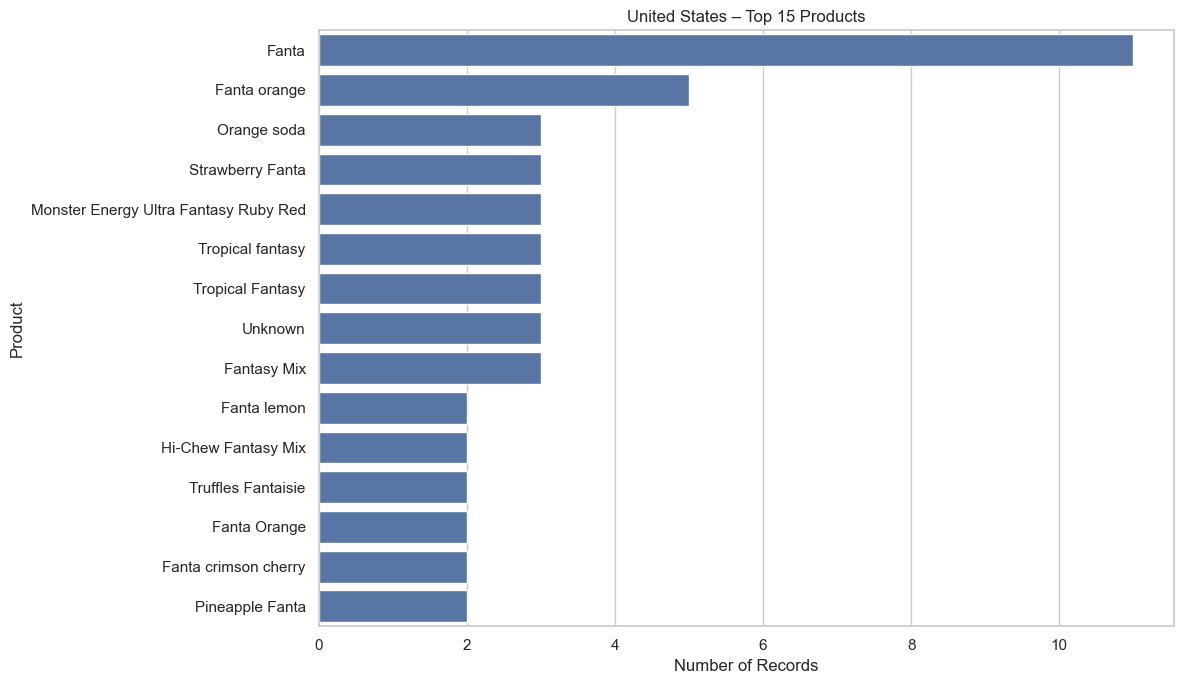

In [11]:
# ============================================================
# UNITED STATES — PRODUCT ANALYSIS
# ============================================================

us_product_counts = (
    us_df["product_name"].value_counts().reset_index()
)
us_product_counts.columns = ["Product_Name", "Frequency"]

print("Top 20 Products:")
display(us_product_counts.head(20))

print("Total Product Records:", len(us_df))
print("Unique Products:", us_df["product_name"].nunique())
print(
    "Product Uniqueness Rate:",
    round(us_df["product_name"].nunique() / len(us_df) * 100, 2),
    "%"
)

plt.figure(figsize=(12, 7))
sns.barplot(data=us_product_counts.head(15),
            x="Frequency", y="Product_Name")
plt.title("United States – Top 15 Products")
plt.xlabel("Number of Records")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

Top 20 Brands:


,Brand,Product_Count
0,Fanta,76
1,Firehouse Subs,72
2,Unknown,49
3,Zaxby's,32
4,White Castle,30
5,Whataburger,14
6,Sonic,10
7,Church's Chicken,10
8,Jack in the Box,8
9,McDonald's,8


Unique Brands: 88
Brand Diversity Ratio: 20.23 %


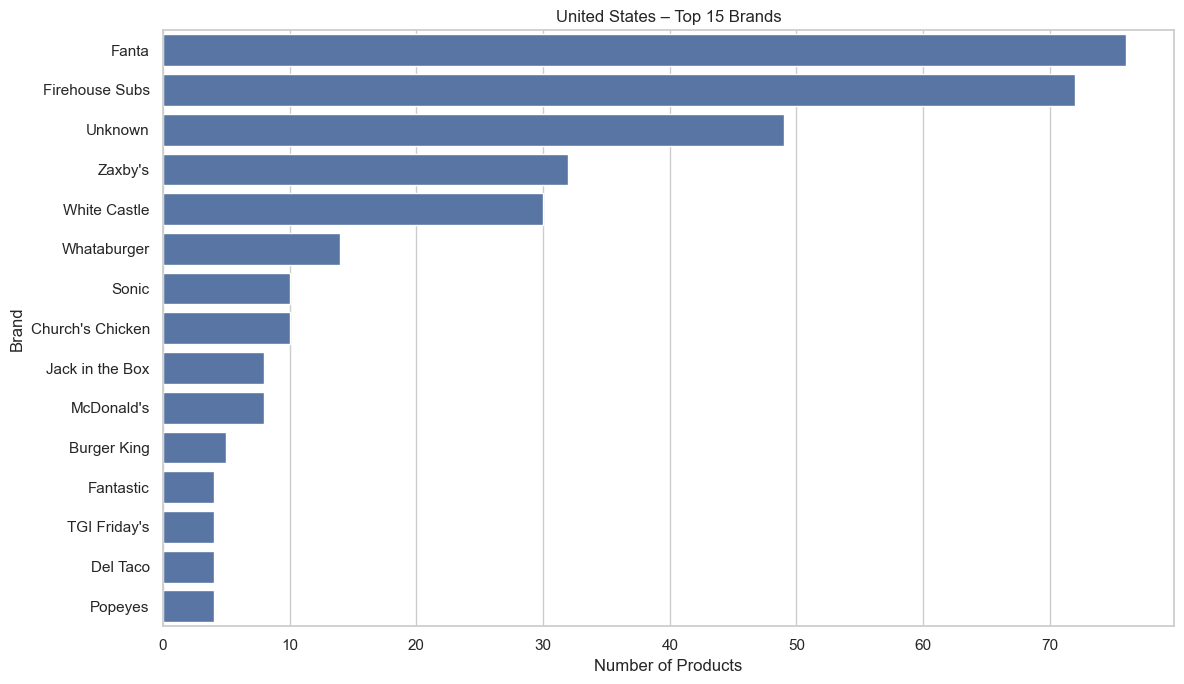

In [12]:
# ============================================================
# UNITED STATES — BRAND ANALYSIS
# ============================================================

us_brand_counts = (
    us_df["brands"].value_counts().reset_index()
)
us_brand_counts.columns = ["Brand", "Product_Count"]

print("Top 20 Brands:")
display(us_brand_counts.head(20))

print("Unique Brands:", us_df["brands"].nunique())

us_brand_diversity = (
    us_df["brands"].nunique() / len(us_df) * 100
)
print("Brand Diversity Ratio:", round(us_brand_diversity, 2), "%")

plt.figure(figsize=(12, 7))
sns.barplot(data=us_brand_counts.head(15),
            x="Product_Count", y="Brand")
plt.title("United States – Top 15 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Top 25 Categories:


categories_tags
beverages                               257
beverages-and-beverages-preparations    243
carbonated-drinks                        19
sodas                                    18
plant-based-foods-and-beverages          13
snacks                                   11
sweet-snacks                             10
confectioneries                           9
plant-based-foods                         7
plant-based-beverages                     6
fruit-based-beverages                     5
fruit-sodas                               5
sweetened-beverages                       4
cereals-and-their-products                4
cereals-and-potatoes                      4
cocoa-and-its-products                    3
chocolate-candies                         3
energy-drinks                             3
artificially-sweetened-beverages          2
pastas                                    2
entrees                                   2
fruits-and-vegetables-based-foods         2
orange-soft-drin

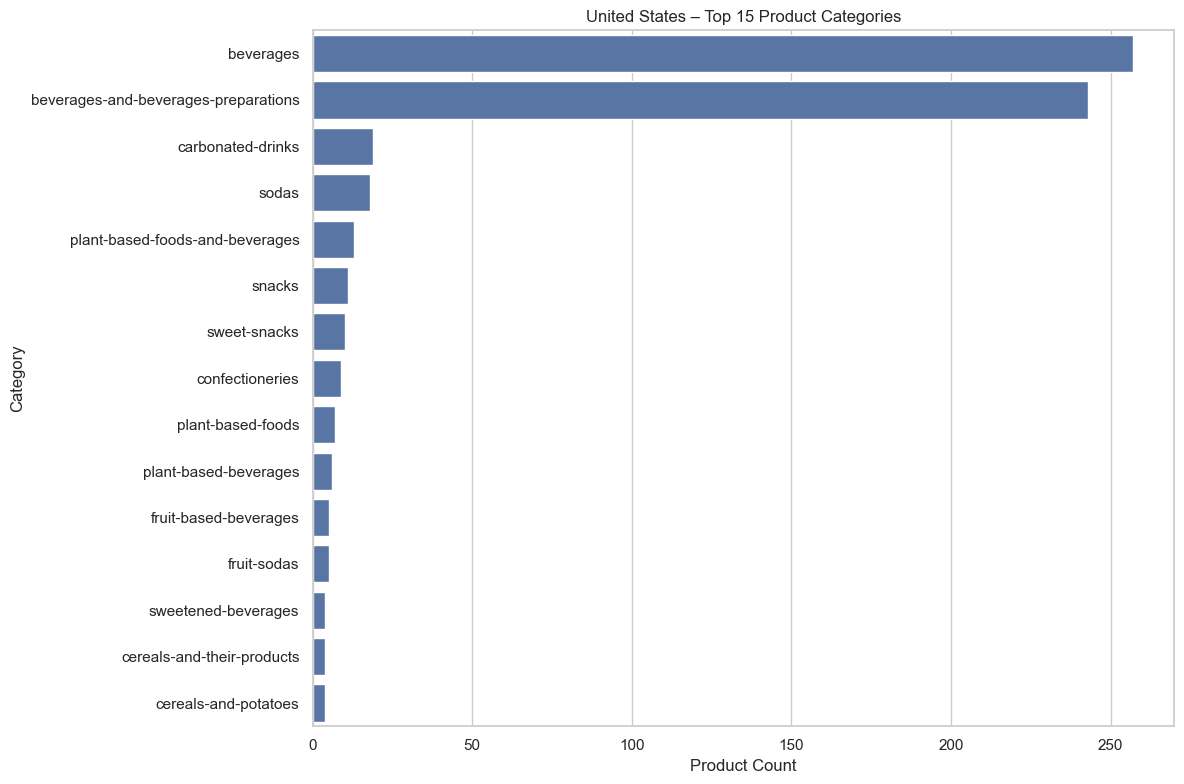

In [13]:
# ============================================================
# UNITED STATES — CATEGORY ANALYSIS
# ============================================================

us_category_series = (
    us_df["categories_tags"].astype(str)
    .str.split(",").explode().str.strip()
)

us_category_series = us_category_series[
    us_category_series.str.lower() != "unknown"
]

us_category_counts = us_category_series.value_counts()

print("Top 25 Categories:")
display(us_category_counts.head(25))

us_top_categories = us_category_counts.head(15).reset_index()
us_top_categories.columns = ["Category", "Product_Count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=us_top_categories,
            x="Product_Count", y="Category")
plt.title("United States – Top 15 Product Categories")
plt.xlabel("Product Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# UNITED STATES — PACKAGING, STORE AND PURCHASE PLACE
# ============================================================

def analyze_multivalue_attribute(country_df, column, label):
    if column not in country_df.columns:
        print(f"Column not found: {column}")
        return pd.Series(dtype="int64")

    s = country_df[column].astype(str).str.split(",").explode().str.strip()
    s = s[s.str.lower() != "unknown"]
    counts = s.value_counts()

    print(f"Top {label}:")
    display(counts.head(20).to_frame("Count"))
    return counts

us_packaging_counts = analyze_multivalue_attribute(
    us_df, "packaging_tags", "Packaging Types"
)
us_store_counts = analyze_multivalue_attribute(
    us_df, "stores", "Stores"
)
us_purchase_counts = analyze_multivalue_attribute(
    us_df, "purchase_places", "Purchase Places"
)

Top Packaging Types:


,Count
packaging_tags,
card-box,3
plastic-bowl,1
bottle,1
hdpe-bottle,1
paper-sleeve,1


Top Stores:


,Count
stores,


Top Purchase Places:


,Count
purchase_places,
Maryland,1
USA,1


Nutri-Score Distribution:


nutriscore_grade
unknown    174
b          150
e           54
c           48
d            8
a            1
Name: count, dtype: int64

Nutri-Score Percentage:


nutriscore_grade
unknown    40.00
b          34.48
e          12.41
c          11.03
d           1.84
a           0.23
Name: proportion, dtype: float64

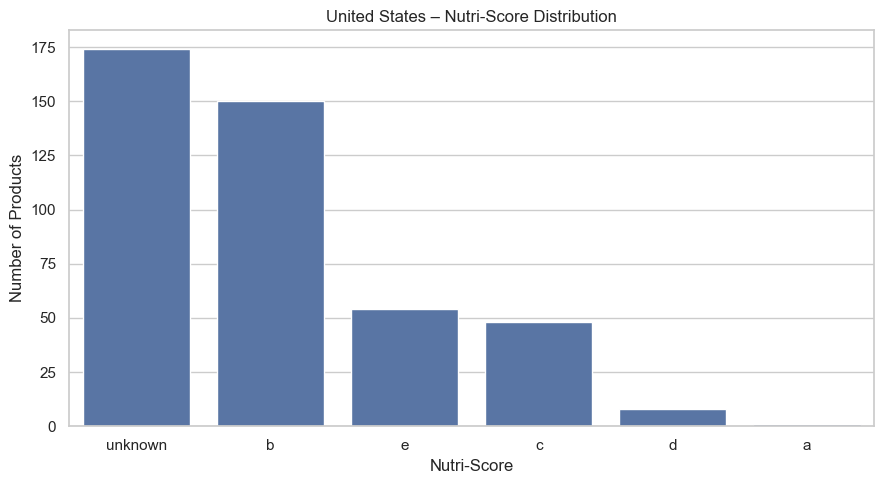

NOVA Group Distribution:


nova_group
Unknown    381
4.0         51
3.0          2
1.0          1
Name: count, dtype: int64

NOVA Group Percentage:


nova_group
Unknown    87.59
4.0        11.72
3.0         0.46
1.0         0.23
Name: proportion, dtype: float64

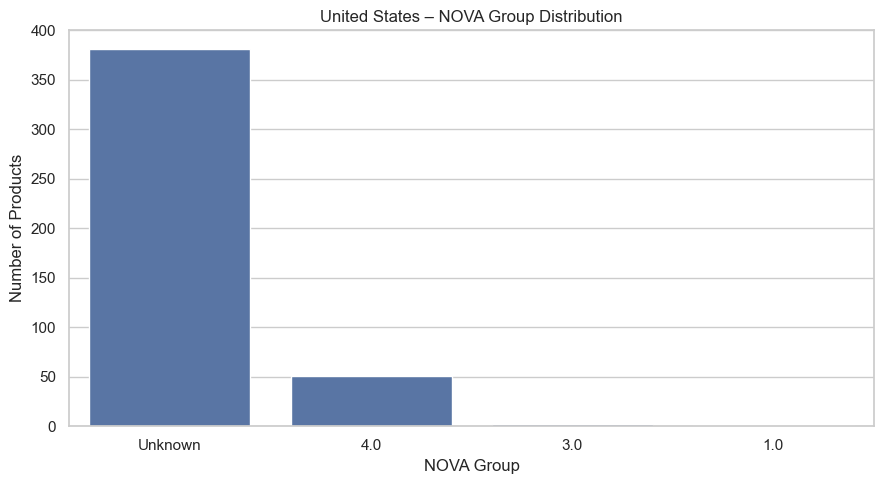

Eco-Score Distribution:


ecoscore_grade
Unknown           346
unknown            82
not-applicable      3
d                   2
f                   2
Name: count, dtype: int64

Eco-Score Percentage:


ecoscore_grade
Unknown           79.54
unknown           18.85
not-applicable     0.69
d                  0.46
f                  0.46
Name: proportion, dtype: float64

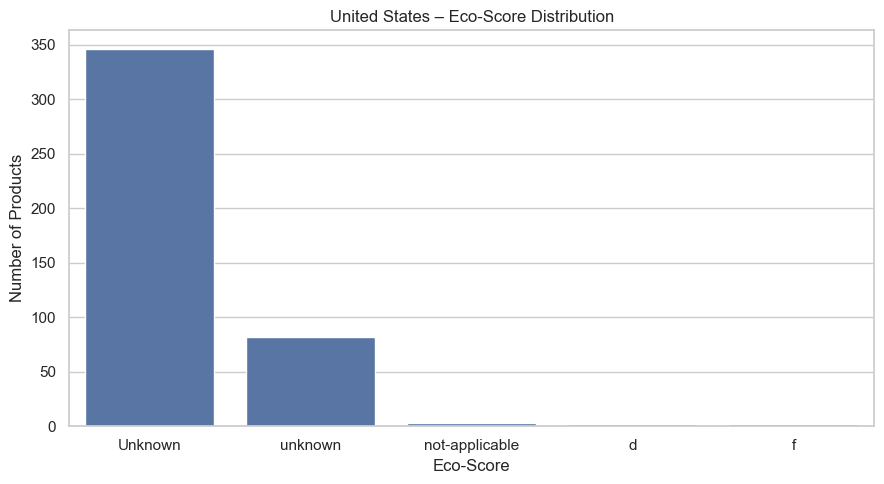

In [15]:
# ============================================================
# UNITED STATES — NUTRI-SCORE, NOVA AND ECO-SCORE
# ============================================================

for col, label in [
    ("nutriscore_grade", "Nutri-Score"),
    ("nova_group", "NOVA Group"),
    ("ecoscore_grade", "Eco-Score")
]:
    if col in us_df.columns:
        counts = us_df[col].value_counts()
        print(f"{label} Distribution:")
        display(counts)
        print(f"{label} Percentage:")
        display(us_df[col].value_counts(normalize=True).mul(100).round(2))

        plt.figure(figsize=(9, 5))
        sns.countplot(
            data=us_df,
            x=col,
            order=us_df[col].value_counts().index
        )
        plt.title(f"United States – {label} Distribution")
        plt.xlabel(label)
        plt.ylabel("Number of Products")
        plt.tight_layout()
        plt.show()

Sugar Statistics:


count    326.000000
mean      14.707321
std       29.361912
min        0.000000
25%        1.050000
50%        2.000000
75%       12.675000
max      254.000000
Name: nutriments.sugars_100g_num, dtype: float64

Energy Statistics:


count      332.000000
mean       182.620579
std       1435.189239
min          0.000000
25%          5.070000
50%          9.345000
75%        126.000000
max      26000.000000
Name: nutriments.energy-kcal_100g_num, dtype: float64

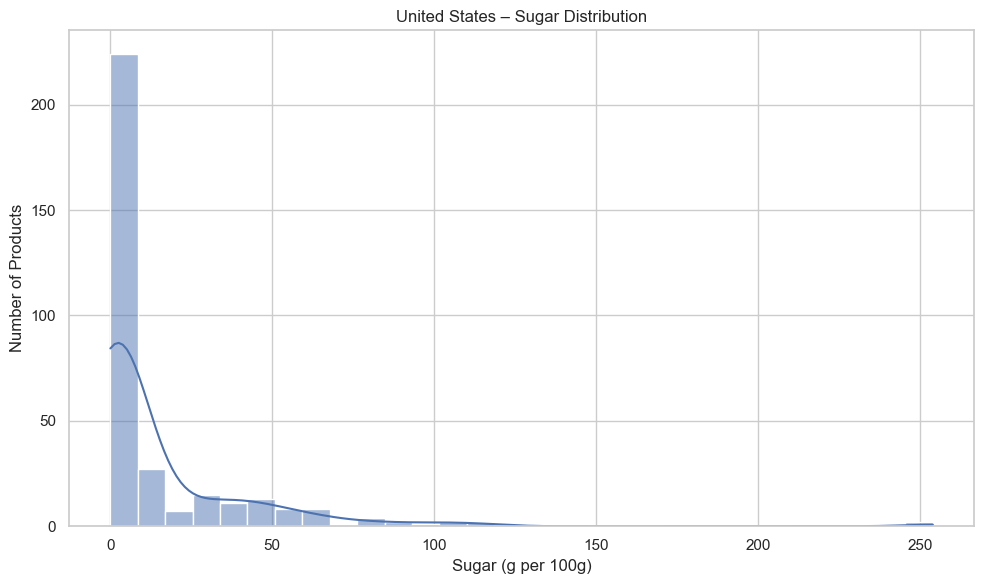

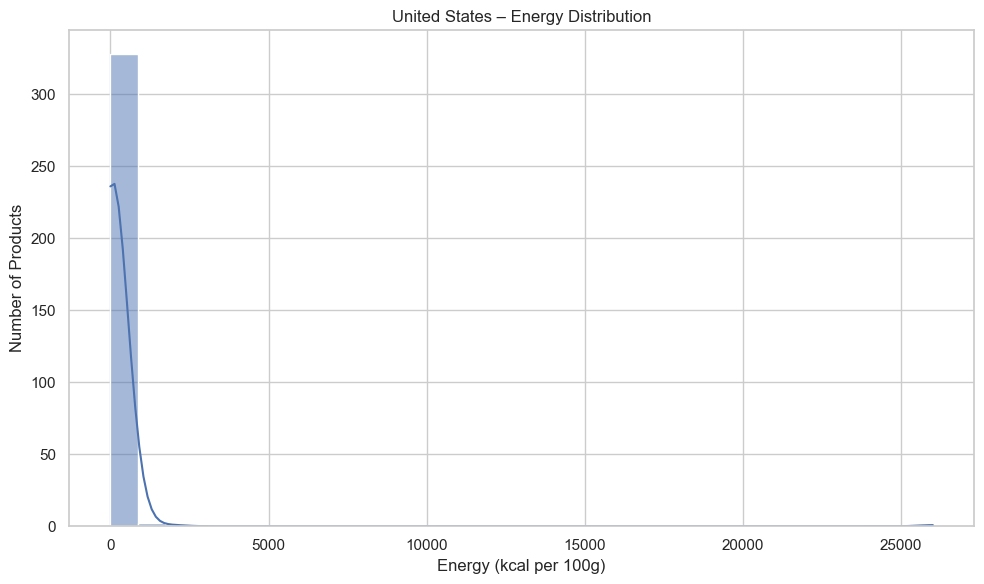

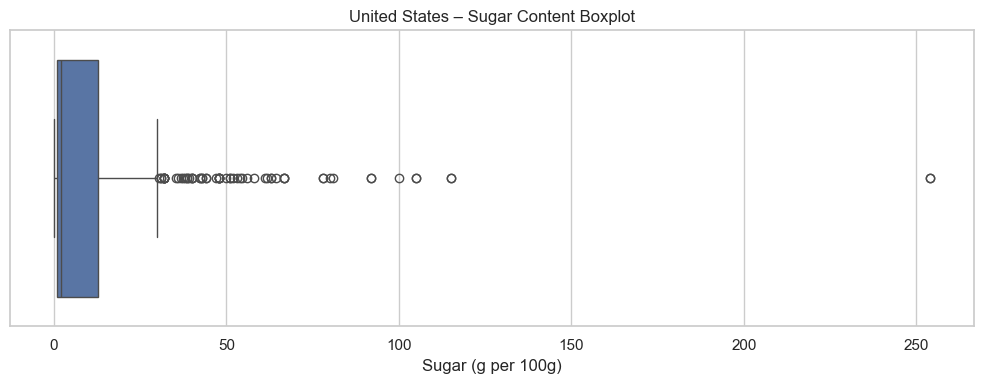

In [16]:
# ============================================================
# UNITED STATES — SUGAR AND ENERGY
# ============================================================

us_sugar = us_df["nutriments.sugars_100g_num"].dropna()
us_energy = us_df["nutriments.energy-kcal_100g_num"].dropna()

print("Sugar Statistics:")
display(us_sugar.describe())

print("Energy Statistics:")
display(us_energy.describe())

plt.figure(figsize=(10, 6))
sns.histplot(us_sugar, bins=30, kde=True)
plt.title("United States – Sugar Distribution")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(us_energy, bins=30, kde=True)
plt.title("United States – Energy Distribution")
plt.xlabel("Energy (kcal per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=us_sugar)
plt.title("United States – Sugar Content Boxplot")
plt.xlabel("Sugar (g per 100g)")
plt.tight_layout()
plt.show()

Valid nutritional records: 324
Sugar–Energy Correlation: 0.062


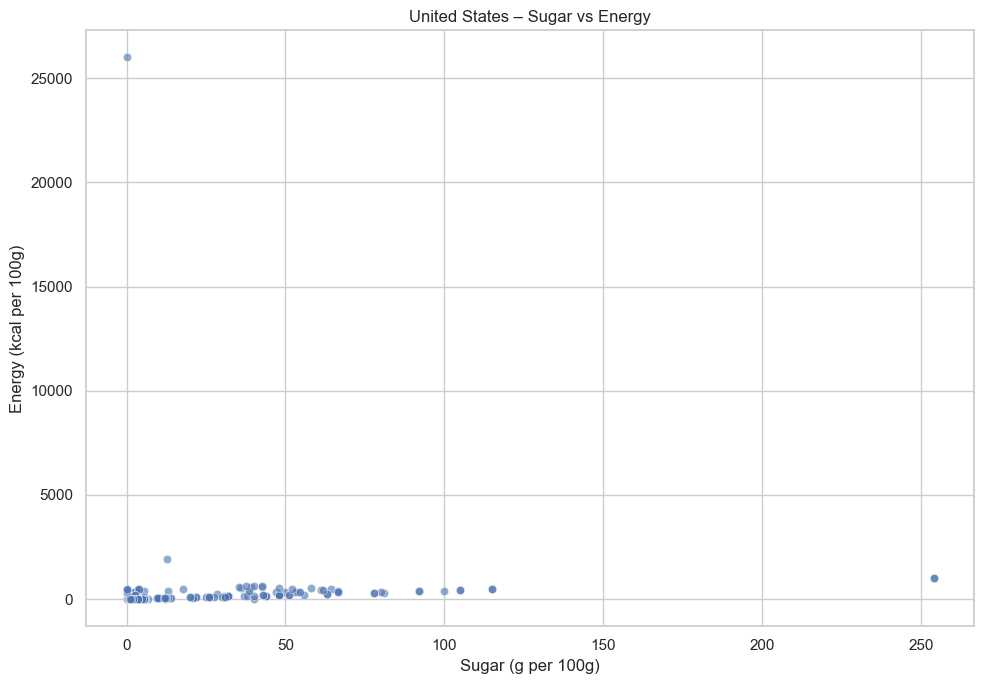

In [17]:
# ============================================================
# UNITED STATES — SUGAR VS ENERGY
# ============================================================

us_nutrition = us_df[
    ["nutriments.sugars_100g_num", "nutriments.energy-kcal_100g_num"]
].dropna()

us_sugar_energy_corr = (
    us_nutrition["nutriments.sugars_100g_num"]
    .corr(us_nutrition["nutriments.energy-kcal_100g_num"])
)

print("Valid nutritional records:", len(us_nutrition))
print("Sugar–Energy Correlation:", round(us_sugar_energy_corr, 3))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=us_nutrition,
    x="nutriments.sugars_100g_num",
    y="nutriments.energy-kcal_100g_num",
    alpha=0.6
)
plt.title("United States – Sugar vs Energy")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Energy (kcal per 100g)")
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# UNITED STATES — OUTLIER ANALYSIS
# ============================================================

def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

us_sugar_outliers = find_outliers(us_sugar)
us_energy_outliers = find_outliers(us_energy)

print("Sugar Outliers:", len(us_sugar_outliers))
print("Energy Outliers:", len(us_energy_outliers))

print("\nHighest Sugar Products:")
display(
    us_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.sugars_100g_num"]
    ].dropna(subset=["nutriments.sugars_100g_num"])
     .sort_values("nutriments.sugars_100g_num", ascending=False)
     .head(20)
)

print("\nHighest Energy Products:")
display(
    us_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.energy-kcal_100g_num"]
    ].dropna(subset=["nutriments.energy-kcal_100g_num"])
     .sort_values("nutriments.energy-kcal_100g_num", ascending=False)
     .head(20)
)

Sugar Outliers: 62
Energy Outliers: 52

Highest Sugar Products:


,product_name,brands,categories_tags,nutriments.sugars_100g_num
808,"Papa John's, Fanta Orange, 2 Liter",Papa John's,"beverages-and-beverages-preparations, beverages",254.000000
751,"Papa John's, Fanta Orange, 2 Liter",Papa John's,"beverages-and-beverages-preparations, beverages",254.000000
764,"Wendy's, Fanta Orange, Large",Wendy's,"beverages-and-beverages-preparations, beverages",115.000000
822,"Wendy's, Fanta Orange, Large",Wendy's,"beverages-and-beverages-preparations, beverages",115.000000
817,"Sonic, Fanta Orange, RT 44",Sonic,"beverages-and-beverages-preparations, beverages",105.000000
759,"Sonic, Fanta Orange, RT 44",Sonic,"beverages-and-beverages-preparations, beverages",105.000000
333,Tropical fantasy,Unknown,Unknown,100.000000
823,"Wendy's, Fanta Orange, Medium",Wendy's,"beverages-and-beverages-preparations, beverages",92.000000
765,"Wendy's, Fanta Orange, Medium",Wendy's,"beverages-and-beverages-preparations, beverages",92.000000
200,16 Fl Oz,Fanta,Unknown,81.000000



Highest Energy Products:


,product_name,brands,categories_tags,nutriments.energy-kcal_100g_num
910,chucky's punch,Fanta,Unknown,26000.000000
3,Oriental Fantasy Mix,"Weis, Weis Markets Inc.",undefined,1950.000000
751,"Papa John's, Fanta Orange, 2 Liter",Papa John's,"beverages-and-beverages-preparations, beverages",1020.000000
808,"Papa John's, Fanta Orange, 2 Liter",Papa John's,"beverages-and-beverages-preparations, beverages",1020.000000
882,Truffles Fantaisie,Cémoi,Unknown,633.000000
51,Arabica truffes cappuccino fantaisie,Unknown,"snacks, sweet-snacks, cocoa-and-its-products, confectioneries, chocolate-candies",625.000000
880,Coeurs De Truffes Fantaisie,Guyaux,Unknown,625.000000
88,Fudge Fantasies,Unknown,Unknown,604.650000
471,Truffes Fantaisie,Unknown,Unknown,588.235294
4,"Truffle Fantaisie Cacao Powdered Truffles, Plain",Alaus Mathez Chocolatier,Unknown,575.000000


In [19]:
# ============================================================
# UNITED STATES — BRAND NUTRITION ANALYSIS
# ============================================================

us_brand_nutrition = (
    us_df.groupby("brands")
    .agg(
        Product_Count=("product_name", "count"),
        Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
        Median_Sugar=("nutriments.sugars_100g_num", "median"),
        Avg_Energy=("nutriments.energy-kcal_100g_num", "mean"),
        Median_Energy=("nutriments.energy-kcal_100g_num", "median")
    )
    .reset_index()
)

us_brand_nutrition = (
    us_brand_nutrition[
        us_brand_nutrition["Product_Count"] >= 3
    ]
    .sort_values("Product_Count", ascending=False)
)

display(us_brand_nutrition.head(20))

,brands,Product_Count,Avg_Sugar,Median_Sugar,Avg_Energy,Median_Energy
22,Fanta,76,14.847013,12.137419,986.784293,46.500
31,Firehouse Subs,72,0.987528,0.105500,4.022500,2.000
77,Unknown,49,24.464460,12.000000,242.430181,212.000
85,Zaxby's,32,2.016812,1.685000,8.080625,6.740
82,White Castle,30,2.181133,1.690000,8.712667,6.760
81,Whataburger,14,1.516000,1.690000,6.232857,6.760
10,Church's Chicken,10,1.862000,1.845000,7.504000,7.375
70,Sonic,10,57.000000,51.000000,228.000000,204.000
56,McDonald's,8,34.750000,32.000000,143.000000,132.000
45,Jack in the Box,8,0.940000,0.550000,3.756250,2.200


Sugar by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,
a,1,2.38,2.38,2.38,2.38
b,150,1.08,1.27,0.00,5.83
c,46,3.34,3.66,0.00,5.85
d,7,21.24,12.70,3.23,50.00
e,50,56.78,43.00,5.50,254.00
unknown,72,20.67,12.14,0.00,100.00


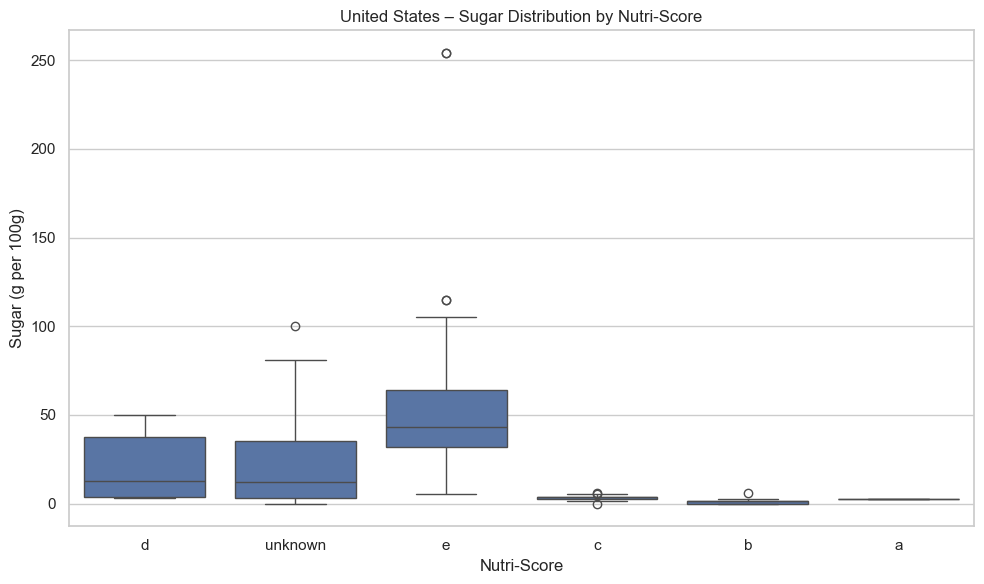

Energy by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,
a,1,357.00,357.00,357.0,357.00
b,150,6.78,5.07,0.0,371.00
c,46,33.56,14.70,8.0,372.22
d,7,488.05,333.33,17.0,1950.00
e,50,275.03,196.00,38.0,1020.00
unknown,78,519.81,53.46,0.0,26000.00


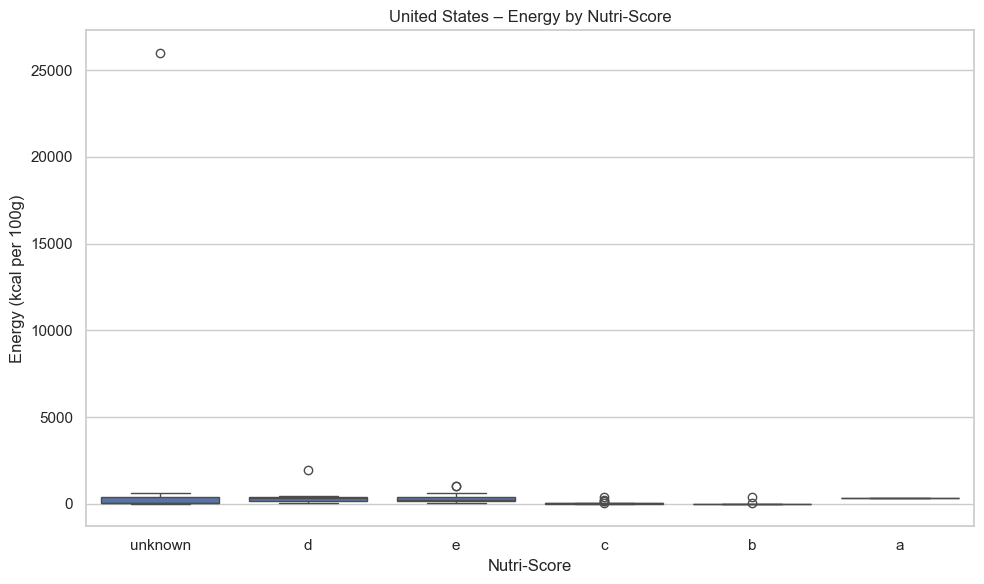

In [20]:
# ============================================================
# UNITED STATES — NUTRI-SCORE VS SUGAR / ENERGY
# ============================================================

if "nutriscore_grade" in us_df.columns:

    us_nutri_sugar = us_df[
        ["nutriscore_grade", "nutriments.sugars_100g_num"]
    ].dropna()

    print("Sugar by Nutri-Score:")
    display(
        us_nutri_sugar.groupby("nutriscore_grade")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=us_nutri_sugar,
        x="nutriscore_grade",
        y="nutriments.sugars_100g_num"
    )
    plt.title("United States – Sugar Distribution by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

    us_nutri_energy = us_df[
        ["nutriscore_grade", "nutriments.energy-kcal_100g_num"]
    ].dropna()

    print("Energy by Nutri-Score:")
    display(
        us_nutri_energy.groupby("nutriscore_grade")
        ["nutriments.energy-kcal_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=us_nutri_energy,
        x="nutriscore_grade",
        y="nutriments.energy-kcal_100g_num"
    )
    plt.title("United States – Energy by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Energy (kcal per 100g)")
    plt.tight_layout()
    plt.show()

,count,mean,median,min,max
nova_group,,,,,
1.0,1,2.38,2.38,2.38,2.38
3.0,2,7.78,7.78,2.86,12.70
4.0,31,26.97,17.86,0.00,66.67
Unknown,292,13.50,2.00,0.00,254.00


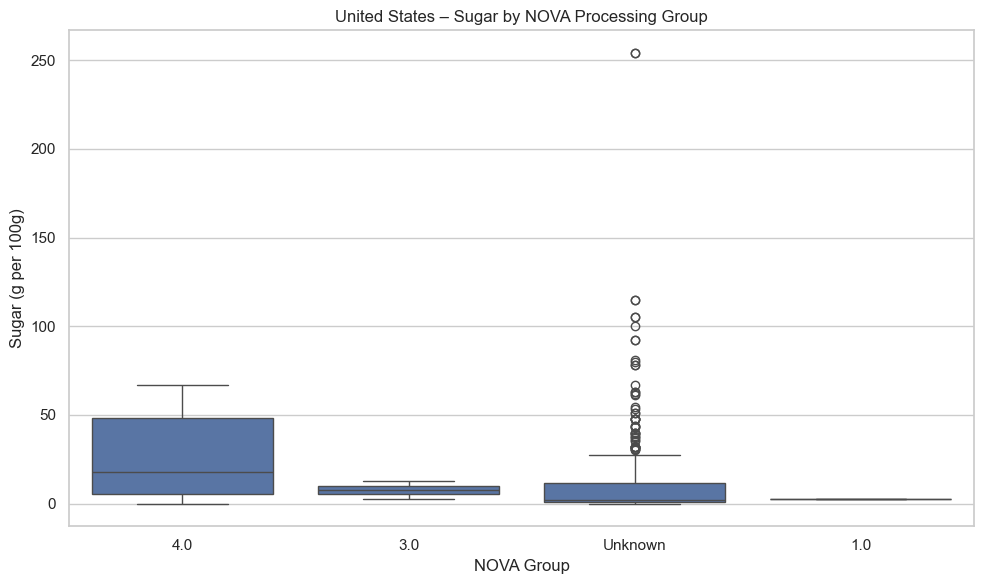

In [21]:
# ============================================================
# UNITED STATES — NOVA VS SUGAR
# ============================================================

if "nova_group" in us_df.columns:

    us_nova_sugar = us_df[
        ["nova_group", "nutriments.sugars_100g_num"]
    ].dropna()

    display(
        us_nova_sugar.groupby("nova_group")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=us_nova_sugar,
        x="nova_group",
        y="nutriments.sugars_100g_num"
    )
    plt.title("United States – Sugar by NOVA Processing Group")
    plt.xlabel("NOVA Group")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

,nova_group_num,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num
nova_group_num,1.000,0.242,0.026
nutriments.sugars_100g_num,0.242,1.000,0.062
nutriments.energy-kcal_100g_num,0.026,0.062,1.000


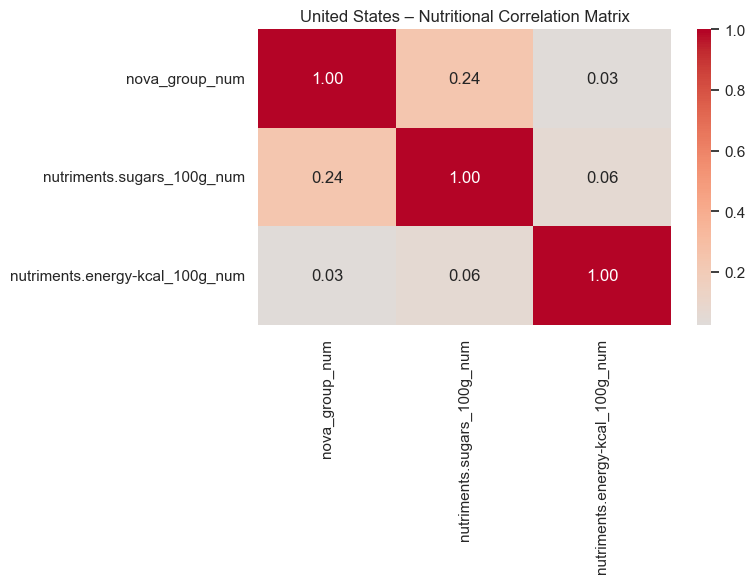

In [22]:
# ============================================================
# UNITED STATES — CORRELATION
# ============================================================

corr_cols = [
    "nova_group_num",
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

available_corr_cols = [c for c in corr_cols if c in us_df.columns]

us_corr = us_df[available_corr_cols].corr()

display(us_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    us_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("United States – Nutritional Correlation Matrix")
plt.tight_layout()
plt.show()

,Ingredient,Frequency
0,undefined,230
1,citric acid,26
2,salt,24
3,sugar,20
4,carbonated water,17
5,natural flavors,17
6,yellow 6,13
7,high fructose corn syrup,13
8,red 40,11
9,modified food starch,10


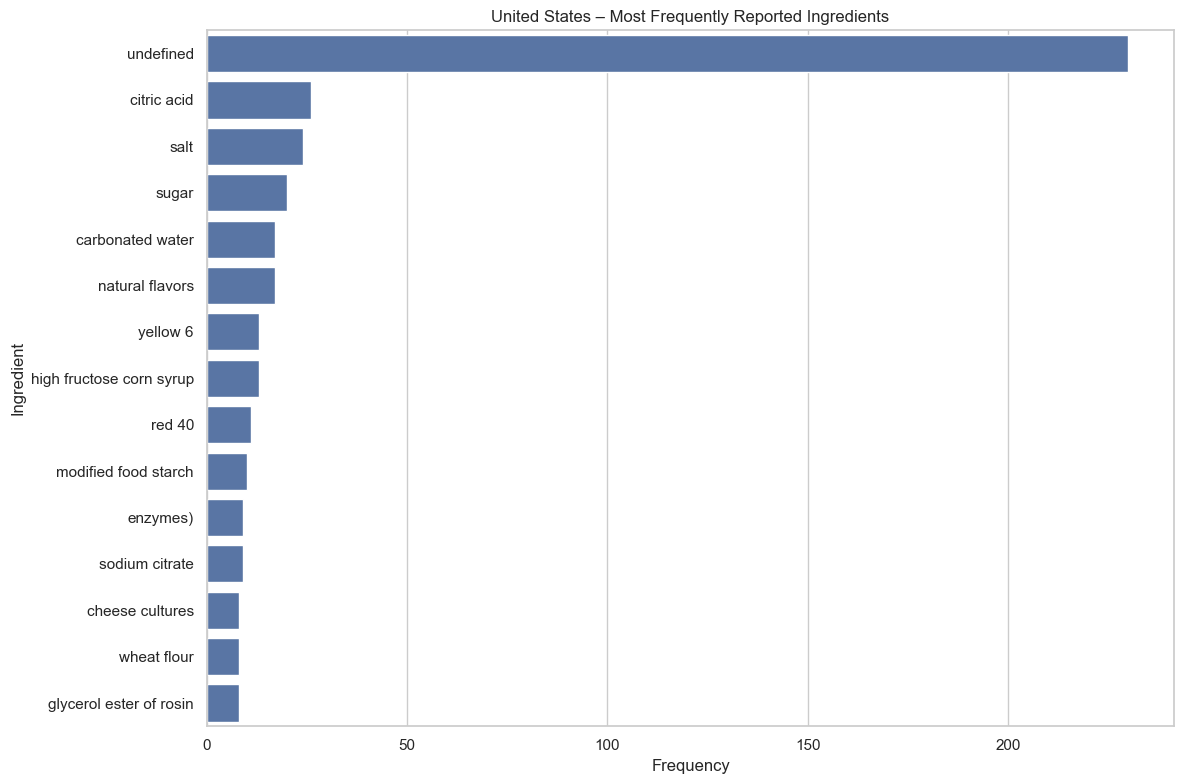

In [23]:
# ============================================================
# UNITED STATES — INGREDIENT ANALYSIS
# ============================================================

if "ingredients_text" in us_df.columns:

    ingredient_text = us_df["ingredients_text"].astype(str).str.lower()
    all_ingredients = []

    for text in ingredient_text:
        if text != "unknown":
            for ingredient in text.split(","):
                ingredient = ingredient.strip()
                if ingredient and ingredient != "unknown":
                    all_ingredients.append(ingredient)

    us_ingredient_counts = Counter(all_ingredients)

    us_ingredient_df = pd.DataFrame(
        us_ingredient_counts.most_common(30),
        columns=["Ingredient", "Frequency"]
    )

    display(us_ingredient_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=us_ingredient_df.head(15),
        x="Frequency",
        y="Ingredient"
    )
    plt.title("United States – Most Frequently Reported Ingredients")
    plt.xlabel("Frequency")
    plt.ylabel("Ingredient")
    plt.tight_layout()
    plt.show()

In [24]:
# ============================================================
# UNITED STATES — CATEGORY VS NUTRITION
# ============================================================

if "categories_tags" in us_df.columns:

    us_category_nutrition = (
        us_df.groupby("categories_tags")
        .agg(
            Product_Count=("product_name", "count"),
            Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
            Avg_Energy=("nutriments.energy-kcal_100g_num", "mean")
        )
        .reset_index()
    )

    us_category_nutrition = (
        us_category_nutrition[
            us_category_nutrition["Product_Count"] >= 2
        ]
        .sort_values("Product_Count", ascending=False)
    )

    display(us_category_nutrition.head(20))

,categories_tags,Product_Count,Avg_Sugar,Avg_Energy
7,"beverages-and-beverages-preparations, beverages",229,11.315943,45.799956
1,Unknown,152,21.841241,570.464696
35,"snacks, sweet-snacks, confectioneries",5,54.105000,337.416667
9,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",4,9.250000,66.500000
2,beverages,4,4.820915,19.750000
5,"beverages, carbonated-drinks, sodas",3,6.700000,28.000000
34,"snacks, sweet-snacks, cocoa-and-its-products, confectioneries, chocolate-candies",3,54.950000,547.000000
13,"beverages-and-beverages-preparations, beverages, energy-drinks",2,NaN,NaN
12,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas, sweetened-beverages",2,NaN,NaN
26,"plant-based-foods-and-beverages, plant-based-foods, cereals-and-potatoes, cereals-and-their-products",2,38.480000,385.000000


In [25]:
# ============================================================
# UNITED STATES — ATTRIBUTE-LEVEL ANALYSIS
# ============================================================

categorical_columns = [
    "brands",
    "categories_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "nutriscore_grade",
    "nova_group",
    "ecoscore_grade"
]

for col in categorical_columns:
    if col in us_df.columns:
        print("\n" + "=" * 70)
        print(f"ATTRIBUTE: {col}")
        print("=" * 70)

        counts = (
            us_df[col]
            .astype(str)
            .value_counts()
            .head(15)
        )

        display(counts.to_frame("Count"))


ATTRIBUTE: brands


,Count
brands,
Fanta,76
Firehouse Subs,72
Unknown,49
Zaxby's,32
White Castle,30
Whataburger,14
Sonic,10
Church's Chicken,10
Jack in the Box,8



ATTRIBUTE: categories_tags


,Count
categories_tags,
"beverages-and-beverages-preparations, beverages",229
Unknown,152
"snacks, sweet-snacks, confectioneries",5
"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",4
beverages,4
"snacks, sweet-snacks, cocoa-and-its-products, confectioneries, chocolate-candies",3
"beverages, carbonated-drinks, sodas",3
"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas, sweetened-beverages",2
"beverages-and-beverages-preparations, beverages, energy-drinks",2



ATTRIBUTE: packaging_tags


...

,Count
nutriscore_grade,
unknown,174
b,150
e,54
c,48
d,8
a,1



ATTRIBUTE: nova_group


,Count
nova_group,
Unknown,381
4.0,51
3.0,2
1.0,1



ATTRIBUTE: ecoscore_grade


,Count
ecoscore_grade,
Unknown,346
unknown,82
not-applicable,3
d,2
f,2


In [26]:
# ============================================================
# UNITED STATES — NUMERICAL ATTRIBUTE ANALYSIS
# ============================================================

numerical_columns = [
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

us_numeric_summary = []

for col in numerical_columns:
    if col in us_df.columns:
        us_numeric_summary.append({
            "Attribute": col,
            "Count": us_df[col].count(),
            "Mean": us_df[col].mean(),
            "Median": us_df[col].median(),
            "Std": us_df[col].std(),
            "Minimum": us_df[col].min(),
            "Maximum": us_df[col].max()
        })

us_numeric_summary = pd.DataFrame(us_numeric_summary)
display(us_numeric_summary.round(2))

,Attribute,Count,Mean,Median,Std,Minimum,Maximum
0,nutriments.sugars_100g_num,326,14.71,2.00,29.36,0.0,254.0
1,nutriments.energy-kcal_100g_num,332,182.62,9.35,1435.19,0.0,26000.0


In [27]:
# ============================================================
# UNITED STATES — DATA QUALITY CHECK
# ============================================================

print("UNITED STATES DATA QUALITY CHECK")
print("=" * 60)

print("Duplicate Rows:", us_df.duplicated().sum())
print("Duplicate Product Names:", us_df["product_name"].duplicated().sum())
print("Unique Products:", us_df["product_name"].nunique())
print("Unique Brands:", us_df["brands"].nunique())
print("Records:", len(us_df))

UNITED STATES DATA QUALITY CHECK
Duplicate Rows: 0
Duplicate Product Names: 97
Unique Products: 338
Unique Brands: 88
Records: 435


In [28]:
# ============================================================
# UNITED STATES — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("🌍 UNITED STATES – ADVANCED DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nTotal Records: {len(us_df):,}")
print(f"Unique Products: {us_df['product_name'].nunique():,}")
print(f"Unique Brands: {us_df['brands'].nunique():,}")

print("\nTop 5 Brands:")
display(us_brand_counts.head(5))

print("\nTop 5 Categories:")
display(us_category_counts.head(5))

print("\nTop Packaging Types:")
display(us_packaging_counts.head(5))

print("\nTop Stores:")
display(us_store_counts.head(5))

print("\nTop Purchase Places:")
display(us_purchase_counts.head(5))

if "nutriscore_grade" in us_df.columns:
    print("\nNutri-Score Distribution:")
    display(us_df["nutriscore_grade"].value_counts())

if "nova_group" in us_df.columns:
    print("\nNOVA Distribution:")
    display(us_df["nova_group"].value_counts())

if "ecoscore_grade" in us_df.columns:
    print("\nEco-Score Distribution:")
    display(us_df["ecoscore_grade"].value_counts())

print("\nNutritional Statistics:")
display(pd.DataFrame({
    "Metric": [
        "Average Sugar", "Median Sugar", "Maximum Sugar",
        "Average Energy", "Median Energy", "Maximum Energy"
    ],
    "Value": [
        us_sugar.mean(), us_sugar.median(), us_sugar.max(),
        us_energy.mean(), us_energy.median(), us_energy.max()
    ]
}).round(2))

print("\nSugar–Energy Correlation:", round(us_sugar_energy_corr, 3))
print("\nAnalysis completed for United States.")

🌍 UNITED STATES – ADVANCED DATA ANALYSIS SUMMARY

Total Records: 435
Unique Products: 338
Unique Brands: 88

Top 5 Brands:


,Brand,Product_Count
0,Fanta,76
1,Firehouse Subs,72
2,Unknown,49
3,Zaxby's,32
4,White Castle,30



Top 5 Categories:


categories_tags
beverages                               257
beverages-and-beverages-preparations    243
carbonated-drinks                        19
sodas                                    18
plant-based-foods-and-beverages          13
Name: count, dtype: int64


Top Packaging Types:


...


Eco-Score Distribution:


ecoscore_grade
Unknown           346
unknown            82
not-applicable      3
d                   2
f                   2
Name: count, dtype: int64


Nutritional Statistics:


,Metric,Value
0,Average Sugar,14.71
1,Median Sugar,2.00
2,Maximum Sugar,254.00
3,Average Energy,182.62
4,Median Energy,9.35
5,Maximum Energy,26000.00



Sugar–Energy Correlation: 0.062

Analysis completed for United States.


# 🇮🇹 PART — ITALY

The same complete analysis framework is applied to **Italy only**.

In [29]:
# ============================================================
# ITALY DATASET
# ============================================================

italy_df = df[
    df["countries_tags"].astype(str).str.lower() == "italy"
].copy()

print("ITALY DATASET")
print("=" * 60)
print("Records:", len(italy_df))
print("Attributes:", len(italy_df.columns))
display(italy_df.head())

ITALY DATASET
Records: 315
Attributes: 17


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num,nova_group_num
9,5449000103789,Fanta zéro orange,The coca cola company,"beverages-and-beverages-preparations, beverages, artificially-sweetened-beverages",italy,it:bottiglia-pet,Unknown,Unknown,c,4.0,Unknown,"Acqua, succo di arancia (12%), anidride carbonica, acidificante acido citrico, aromi naturali di agrumi, correttore ...",Unknown,Unknown,NaN,NaN,4.0
10,8001590947920,Fantasie alle Erbe,"Philadelphia, mondelez",dairies,italy,Unknown,Unknown,Unknown,d,4.0,Unknown,"FORMAGGIO fresco [LATTE pastorizzato, crema di LATTE, sale, addensanti (alginato di sodio, farina di semi di carrube...",Unknown,Unknown,NaN,NaN,4.0
12,8028639000439,Fantasia,Barbagallo,Unknown,italy,Unknown,Unknown,Unknown,unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN
14,5449000241375,Fanta original,Fanta,"plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, ...",italy,bottiglia-pet,Unknown,Unknown,unknown,4.0,Unknown,"acqua, succo di arancia da concentrato (12%), zucchero, anidride carbonica, acidificante acido citrico, aromi natura...",Unknown,Unknown,NaN,NaN,4.0
19,8000571816224,Farfalle fantaisia,"Brezzo, L'antico Forno","plant-based-foods-and-beverages, plant-based-foods, pastas",italy,Unknown,Unknown,Unknown,a,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN


In [30]:
# ============================================================
# ITALY — BASIC OVERVIEW
# ============================================================

print("Dataset Shape:", italy_df.shape)
print("\nColumn Names:")
print(italy_df.columns.tolist())

print("\nData Types:")
display(italy_df.dtypes)

print("\nStatistical Summary:")
display(italy_df.describe(include="all").T)

Dataset Shape: (315, 17)

Column Names:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g', 'nutriments.sugars_100g_num', 'nutriments.energy-kcal_100g_num', 'nova_group_num']

Data Types:


code                                object
product_name                        object
brands                              object
categories_tags                     object
countries_tags                      object
packaging_tags                      object
stores                              object
purchase_places                     object
nutriscore_grade                    object
nova_group                          object
ecoscore_grade                      object
ingredients_text                    object
nutriments.sugars_100g              object
nutriments.energy-kcal_100g         object
nutriments.sugars_100g_num         float64
nutriments.energy-kcal_100g_num    float64
nova_group_num                     float64
dtype: object


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,315,314,8056149708361,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,315,263,Fanta,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brands,315,126,Unknown,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories_tags,315,92,Unknown,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countries_tags,315,1,italy,315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packaging_tags,315,12,Unknown,285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stores,315,15,Unknown,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_places,315,3,Unknown,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutriscore_grade,315,8,unknown,206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nova_group,315,4,Unknown,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Attribute,Unknown_Count,Total_Records,Unknown_Percentage
12,nutriments.sugars_100g,315,315,100.00
10,ecoscore_grade,315,315,100.00
13,nutriments.energy-kcal_100g,315,315,100.00
7,purchase_places,309,315,98.10
6,stores,291,315,92.38
5,packaging_tags,285,315,90.48
9,nova_group,279,315,88.57
11,ingredients_text,274,315,86.98
8,nutriscore_grade,207,315,65.71
3,categories_tags,174,315,55.24


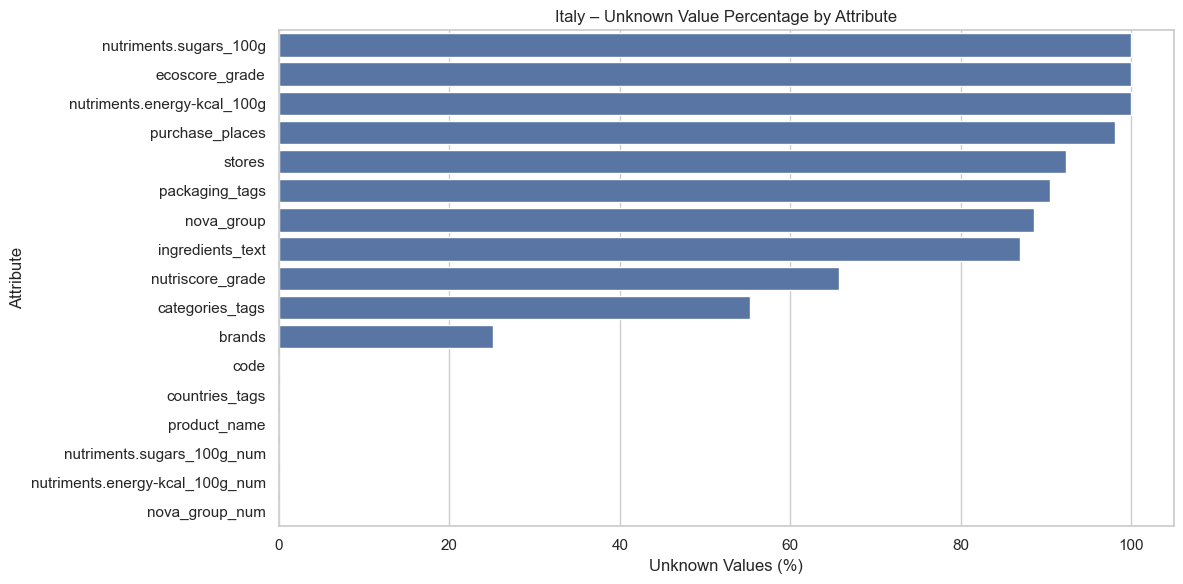

In [31]:
# ============================================================
# ITALY — UNKNOWN VALUE ANALYSIS
# ============================================================

italy_unknown_summary = []

for col in italy_df.columns:
    unknown_count = (
        italy_df[col].astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    italy_unknown_summary.append({
        "Attribute": col,
        "Unknown_Count": unknown_count,
        "Total_Records": len(italy_df),
        "Unknown_Percentage": round(
            unknown_count / len(italy_df) * 100, 2
        )
    })

italy_unknown_df = pd.DataFrame(italy_unknown_summary).sort_values(
    "Unknown_Percentage", ascending=False
)

display(italy_unknown_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=italy_unknown_df,
            x="Unknown_Percentage", y="Attribute")
plt.title("Italy – Unknown Value Percentage by Attribute")
plt.xlabel("Unknown Values (%)")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

Top 20 Products:


,Product_Name,Frequency
0,Fanta,10
1,Fantasia di verdure,7
2,Fantasy,4
3,Aranciata,4
4,Fantasie dell'orto,4
5,Fantasia,4
6,Fantasia di mare,3
7,Insalata fantasia,3
8,Peperoncino,3
9,Fanta limonata,2


Total Product Records: 315
Unique Products: 263
Product Uniqueness Rate: 83.49 %


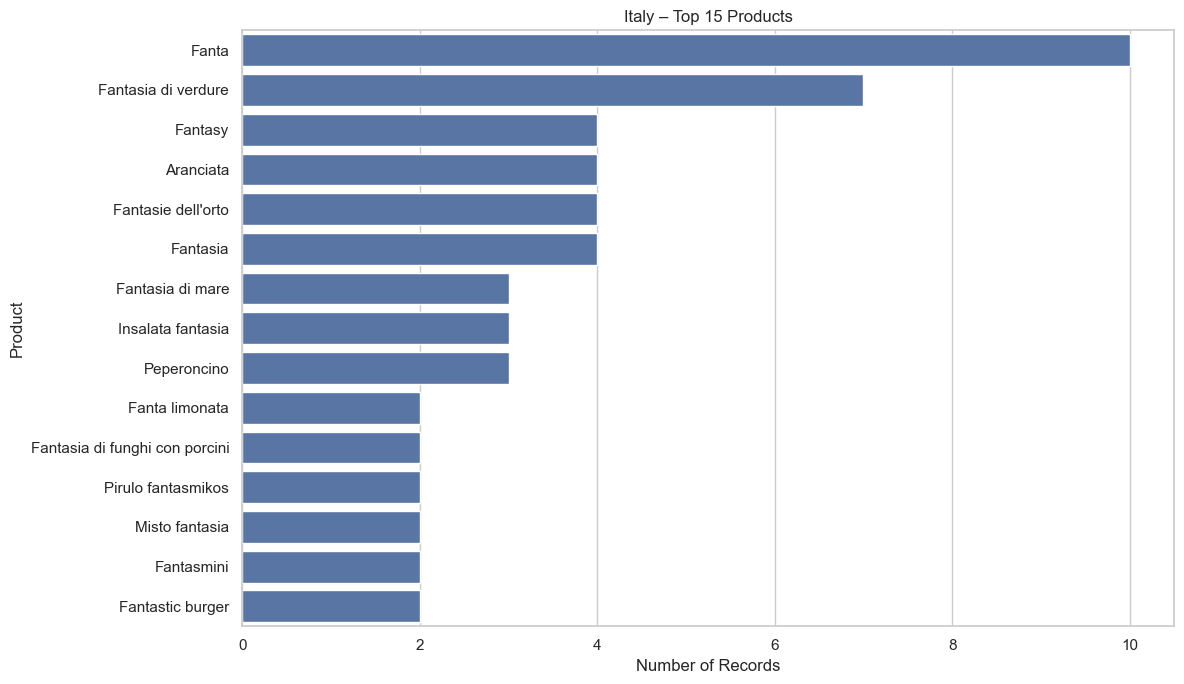

In [32]:
# ============================================================
# ITALY — PRODUCT ANALYSIS
# ============================================================

italy_product_counts = (
    italy_df["product_name"].value_counts().reset_index()
)
italy_product_counts.columns = ["Product_Name", "Frequency"]

print("Top 20 Products:")
display(italy_product_counts.head(20))

print("Total Product Records:", len(italy_df))
print("Unique Products:", italy_df["product_name"].nunique())
print(
    "Product Uniqueness Rate:",
    round(italy_df["product_name"].nunique() / len(italy_df) * 100, 2),
    "%"
)

plt.figure(figsize=(12, 7))
sns.barplot(data=italy_product_counts.head(15),
            x="Frequency", y="Product_Name")
plt.title("Italy – Top 15 Products")
plt.xlabel("Number of Records")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

Top 20 Brands:


,Brand,Product_Count
0,Unknown,79
1,Fanta,29
2,Fantasie Aromatiche,27
3,"Fantasy, Menz & Gasser",8
4,Gusto e fantasia,6
5,"Euroverde, Fantasie dell'Orto",5
6,Coop,5
7,Gallo,4
8,Selex,4
9,Conad,3


Unique Brands: 126
Brand Diversity Ratio: 40.0 %


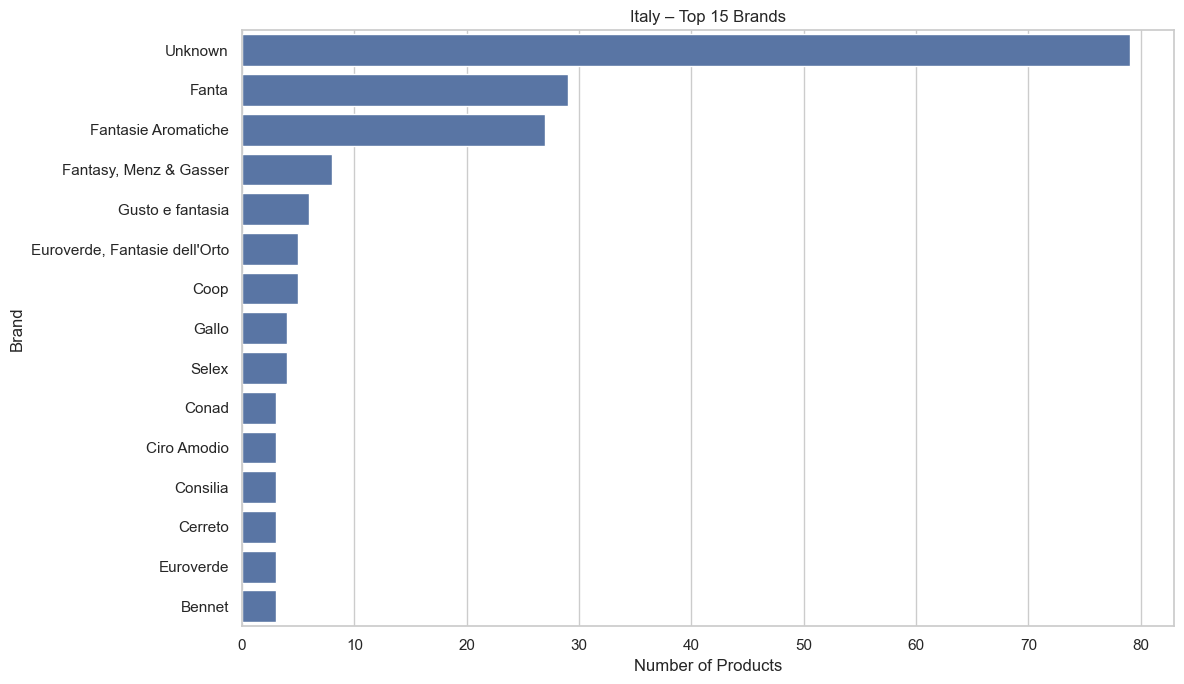

In [33]:
# ============================================================
# ITALY — BRAND ANALYSIS
# ============================================================

italy_brand_counts = (
    italy_df["brands"].value_counts().reset_index()
)
italy_brand_counts.columns = ["Brand", "Product_Count"]

print("Top 20 Brands:")
display(italy_brand_counts.head(20))

print("Unique Brands:", italy_df["brands"].nunique())

italy_brand_diversity = (
    italy_df["brands"].nunique() / len(italy_df) * 100
)
print("Brand Diversity Ratio:", round(italy_brand_diversity, 2), "%")

plt.figure(figsize=(12, 7))
sns.barplot(data=italy_brand_counts.head(15),
            x="Product_Count", y="Brand")
plt.title("Italy – Top 15 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Top 25 Categories:


categories_tags
plant-based-foods-and-beverages         75
plant-based-foods                       66
beverages                               20
frozen-foods                            17
snacks                                  16
fruits-and-vegetables-based-foods       15
sweet-snacks                            14
meals                                   13
seeds                                   12
cereals-and-potatoes                    12
vegetables-based-foods                  12
carbonated-drinks                       11
cereals-and-their-products              11
beverages-and-beverages-preparations    10
desserts                                10
breakfasts                              10
sodas                                   10
frozen-desserts                          9
sweet-spreads                            8
seafood                                  8
spreads                                  8
legumes                                  7
legumes-and-their-products            

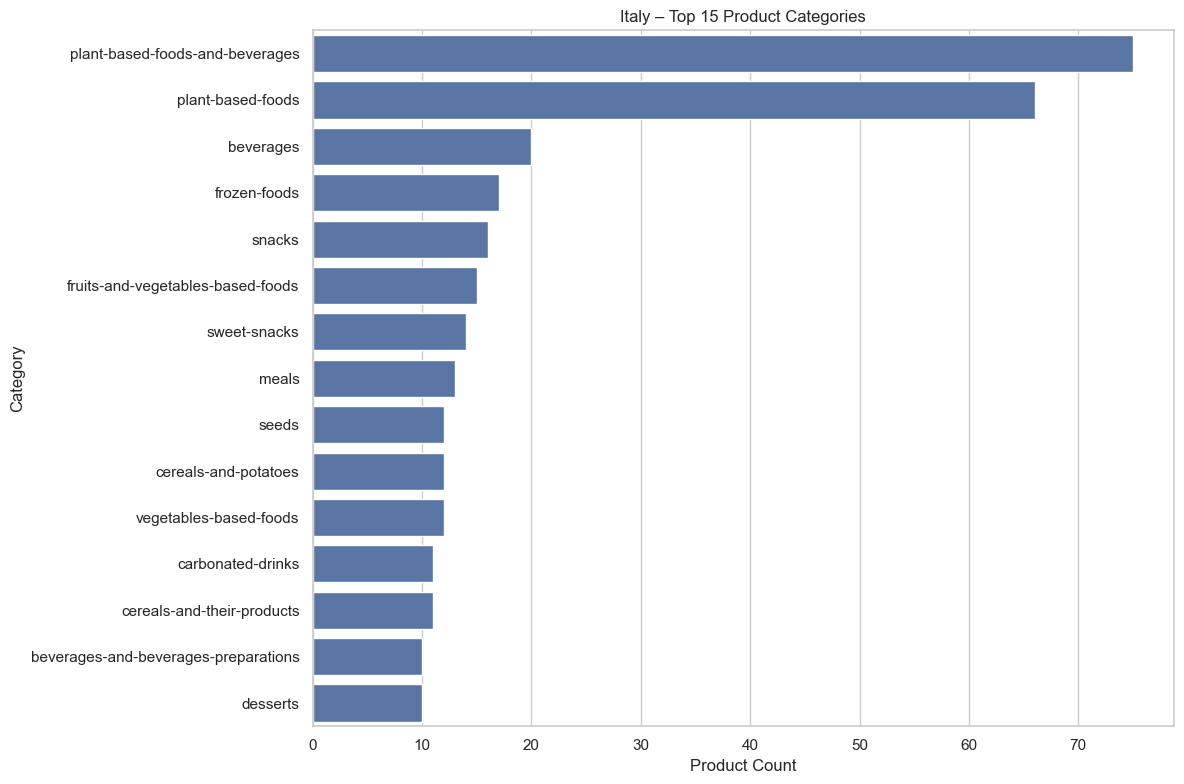

In [34]:
# ============================================================
# ITALY — CATEGORY ANALYSIS
# ============================================================

italy_category_series = (
    italy_df["categories_tags"].astype(str)
    .str.split(",").explode().str.strip()
)

italy_category_series = italy_category_series[
    italy_category_series.str.lower() != "unknown"
]

italy_category_counts = italy_category_series.value_counts()

print("Top 25 Categories:")
display(italy_category_counts.head(25))

italy_top_categories = italy_category_counts.head(15).reset_index()
italy_top_categories.columns = ["Category", "Product_Count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=italy_top_categories,
            x="Product_Count", y="Category")
plt.title("Italy – Top 15 Product Categories")
plt.xlabel("Product Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# ITALY — PACKAGING, STORE AND PURCHASE PLACE
# ============================================================

def analyze_multivalue_attribute(country_df, column, label):
    if column not in country_df.columns:
        print(f"Column not found: {column}")
        return pd.Series(dtype="int64")

    s = country_df[column].astype(str).str.split(",").explode().str.strip()
    s = s[s.str.lower() != "unknown"]
    counts = s.value_counts()

    print(f"Top {label}:")
    display(counts.head(20).to_frame("Count"))
    return counts

italy_packaging_counts = analyze_multivalue_attribute(
    italy_df, "packaging_tags", "Packaging Types"
)
italy_store_counts = analyze_multivalue_attribute(
    italy_df, "stores", "Stores"
)
italy_purchase_counts = analyze_multivalue_attribute(
    italy_df, "purchase_places", "Purchase Places"
)

Top Packaging Types:


,Count
packaging_tags,
it:bottiglia-pet,13
plastic,7
aluminium,4
paper,4
metal,4
recyclable-metals,4
glass,3
bottiglia-pet,2
composite-material,2


Top Stores:


,Count
stores,
Coop,5
Eurospin,3
Bennet,3
Esselunga,2
Conad,2
conad,1
In's,1
crai,1
iperal,1


Top Purchase Places:


,Count
purchase_places,
Italia,6
Mazara del Vallo,1
Trapani,1


Nutri-Score Distribution:


nutriscore_grade
unknown           206
d                  26
c                  25
a                  18
e                  16
b                  14
not-applicable      9
Unknown             1
Name: count, dtype: int64

Nutri-Score Percentage:


nutriscore_grade
unknown           65.40
d                  8.25
c                  7.94
a                  5.71
e                  5.08
b                  4.44
not-applicable     2.86
Unknown            0.32
Name: proportion, dtype: float64

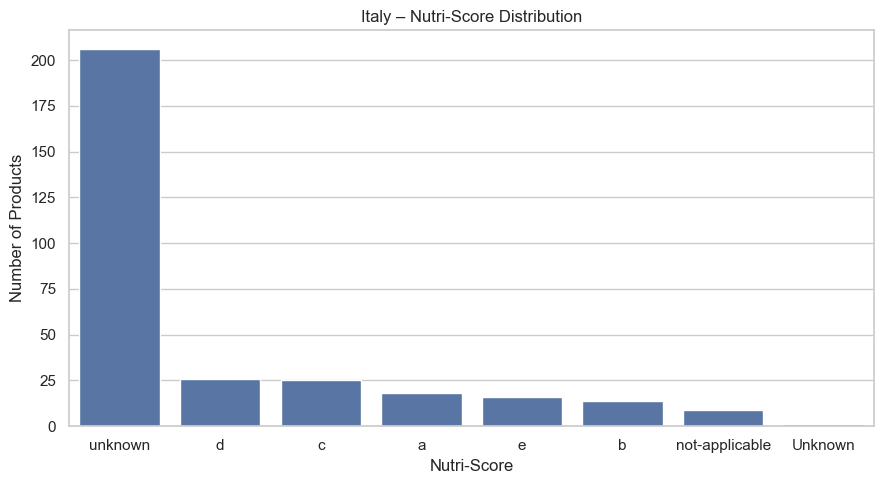

NOVA Group Distribution:


nova_group
Unknown    279
4.0         23
3.0          7
1.0          6
Name: count, dtype: int64

NOVA Group Percentage:


nova_group
Unknown    88.57
4.0         7.30
3.0         2.22
1.0         1.90
Name: proportion, dtype: float64

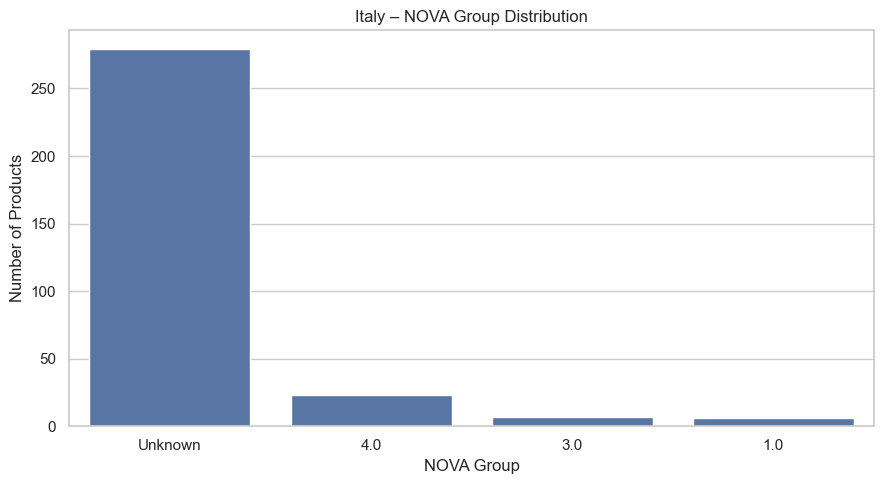

Eco-Score Distribution:


ecoscore_grade
Unknown    314
unknown      1
Name: count, dtype: int64

Eco-Score Percentage:


ecoscore_grade
Unknown    99.68
unknown     0.32
Name: proportion, dtype: float64

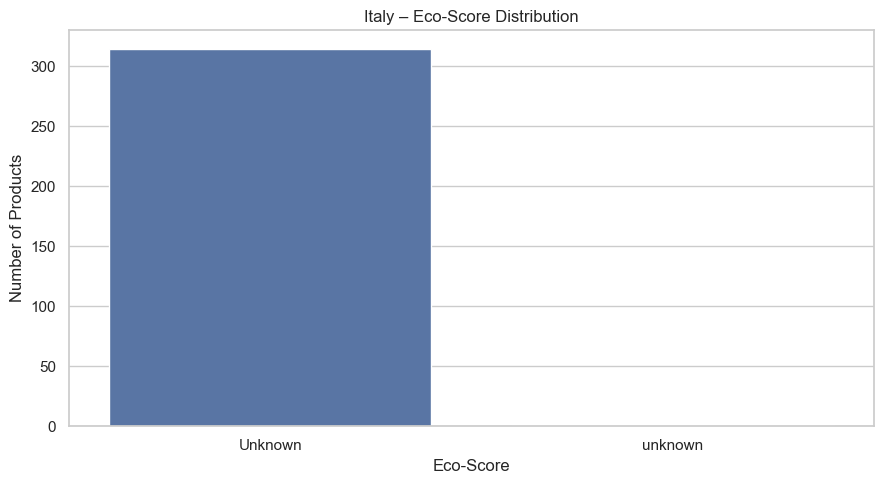

In [36]:
# ============================================================
# ITALY — NUTRI-SCORE, NOVA AND ECO-SCORE
# ============================================================

for col, label in [
    ("nutriscore_grade", "Nutri-Score"),
    ("nova_group", "NOVA Group"),
    ("ecoscore_grade", "Eco-Score")
]:
    if col in italy_df.columns:
        counts = italy_df[col].value_counts()
        print(f"{label} Distribution:")
        display(counts)
        print(f"{label} Percentage:")
        display(italy_df[col].value_counts(normalize=True).mul(100).round(2))

        plt.figure(figsize=(9, 5))
        sns.countplot(
            data=italy_df,
            x=col,
            order=italy_df[col].value_counts().index
        )
        plt.title(f"Italy – {label} Distribution")
        plt.xlabel(label)
        plt.ylabel("Number of Products")
        plt.tight_layout()
        plt.show()

Sugar Statistics:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: nutriments.sugars_100g_num, dtype: float64

Energy Statistics:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: nutriments.energy-kcal_100g_num, dtype: float64

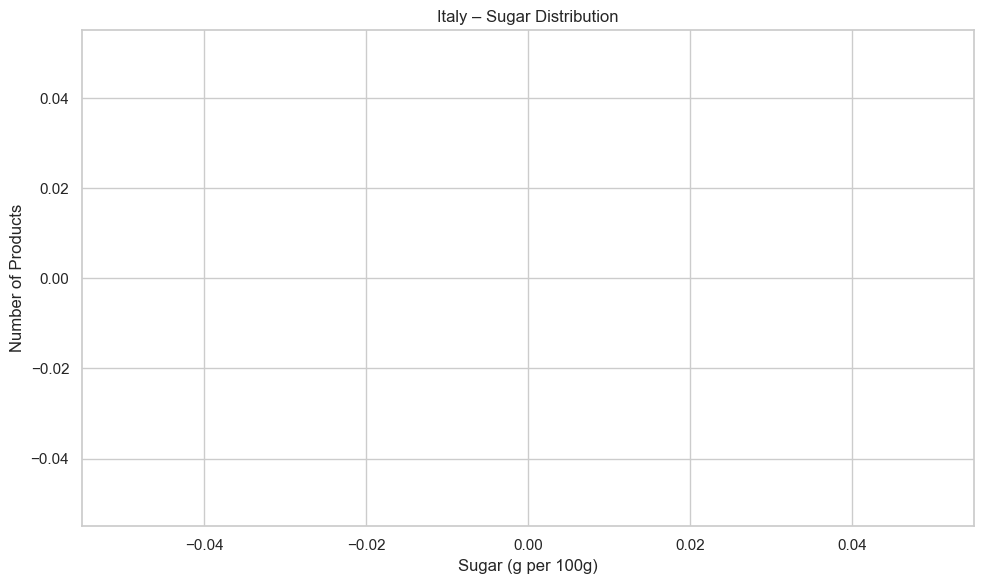

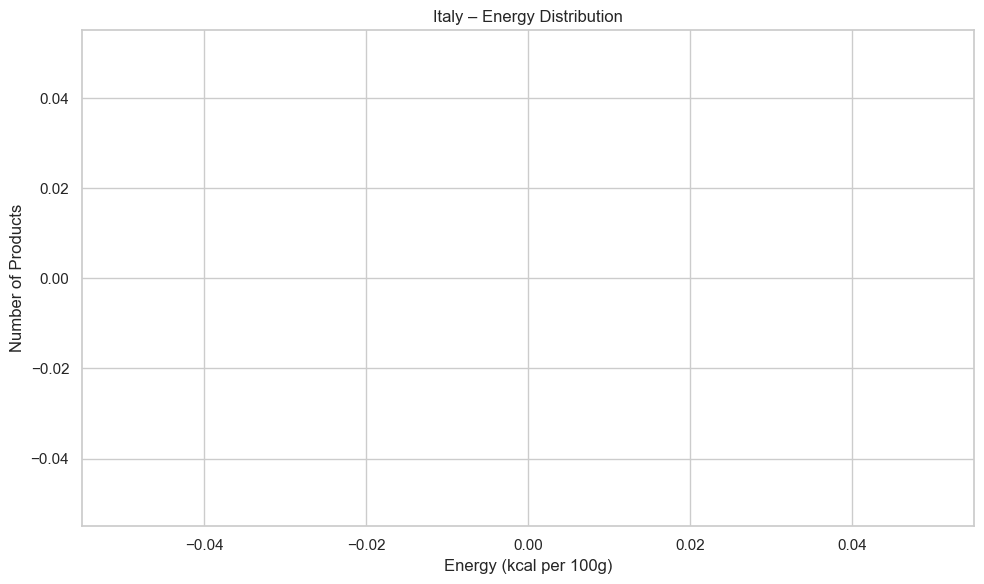

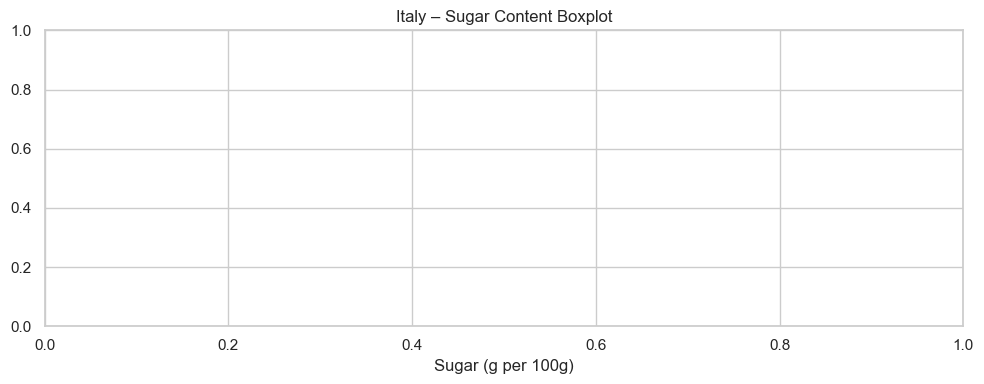

In [37]:
# ============================================================
# ITALY — SUGAR AND ENERGY
# ============================================================

italy_sugar = italy_df["nutriments.sugars_100g_num"].dropna()
italy_energy = italy_df["nutriments.energy-kcal_100g_num"].dropna()

print("Sugar Statistics:")
display(italy_sugar.describe())

print("Energy Statistics:")
display(italy_energy.describe())

plt.figure(figsize=(10, 6))
sns.histplot(italy_sugar, bins=30, kde=True)
plt.title("Italy – Sugar Distribution")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(italy_energy, bins=30, kde=True)
plt.title("Italy – Energy Distribution")
plt.xlabel("Energy (kcal per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=italy_sugar)
plt.title("Italy – Sugar Content Boxplot")
plt.xlabel("Sugar (g per 100g)")
plt.tight_layout()
plt.show()

Valid nutritional records: 0
Sugar–Energy Correlation: nan


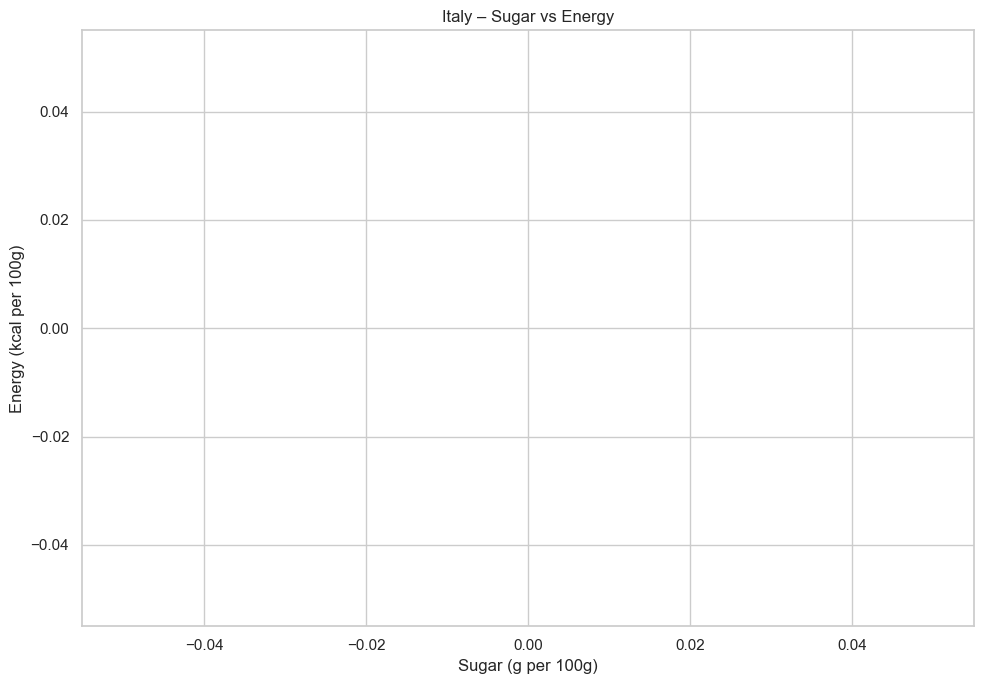

In [38]:
# ============================================================
# ITALY — SUGAR VS ENERGY
# ============================================================

italy_nutrition = italy_df[
    ["nutriments.sugars_100g_num", "nutriments.energy-kcal_100g_num"]
].dropna()

italy_sugar_energy_corr = (
    italy_nutrition["nutriments.sugars_100g_num"]
    .corr(italy_nutrition["nutriments.energy-kcal_100g_num"])
)

print("Valid nutritional records:", len(italy_nutrition))
print("Sugar–Energy Correlation:", round(italy_sugar_energy_corr, 3))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=italy_nutrition,
    x="nutriments.sugars_100g_num",
    y="nutriments.energy-kcal_100g_num",
    alpha=0.6
)
plt.title("Italy – Sugar vs Energy")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Energy (kcal per 100g)")
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# ITALY — OUTLIER ANALYSIS
# ============================================================

def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

italy_sugar_outliers = find_outliers(italy_sugar)
italy_energy_outliers = find_outliers(italy_energy)

print("Sugar Outliers:", len(italy_sugar_outliers))
print("Energy Outliers:", len(italy_energy_outliers))

print("\nHighest Sugar Products:")
display(
    italy_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.sugars_100g_num"]
    ].dropna(subset=["nutriments.sugars_100g_num"])
     .sort_values("nutriments.sugars_100g_num", ascending=False)
     .head(20)
)

print("\nHighest Energy Products:")
display(
    italy_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.energy-kcal_100g_num"]
    ].dropna(subset=["nutriments.energy-kcal_100g_num"])
     .sort_values("nutriments.energy-kcal_100g_num", ascending=False)
     .head(20)
)

Sugar Outliers: 0
Energy Outliers: 0

Highest Sugar Products:


,product_name,brands,categories_tags,nutriments.sugars_100g_num



Highest Energy Products:


,product_name,brands,categories_tags,nutriments.energy-kcal_100g_num


In [40]:
# ============================================================
# ITALY — BRAND NUTRITION ANALYSIS
# ============================================================

italy_brand_nutrition = (
    italy_df.groupby("brands")
    .agg(
        Product_Count=("product_name", "count"),
        Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
        Median_Sugar=("nutriments.sugars_100g_num", "median"),
        Avg_Energy=("nutriments.energy-kcal_100g_num", "mean"),
        Median_Energy=("nutriments.energy-kcal_100g_num", "median")
    )
    .reset_index()
)

italy_brand_nutrition = (
    italy_brand_nutrition[
        italy_brand_nutrition["Product_Count"] >= 3
    ]
    .sort_values("Product_Count", ascending=False)
)

display(italy_brand_nutrition.head(20))

,brands,Product_Count,Avg_Sugar,Median_Sugar,Avg_Energy,Median_Energy
115,Unknown,79,NaN,NaN,NaN,NaN
48,Fanta,29,NaN,NaN,NaN,NaN
50,Fantasie Aromatiche,27,NaN,NaN,NaN,NaN
54,"Fantasy, Menz & Gasser",8,NaN,NaN,NaN,NaN
65,Gusto e fantasia,6,NaN,NaN,NaN,NaN
45,"Euroverde, Fantasie dell'Orto",5,NaN,NaN,NaN,NaN
31,Coop,5,NaN,NaN,NaN,NaN
60,Gallo,4,NaN,NaN,NaN,NaN
109,Selex,4,NaN,NaN,NaN,NaN
30,Consilia,3,NaN,NaN,NaN,NaN


Sugar by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,


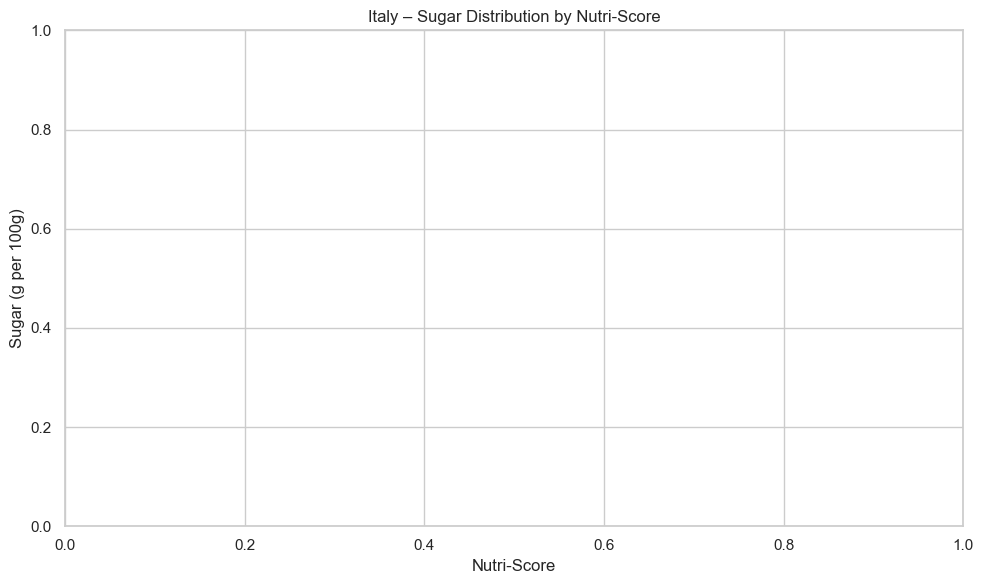

Energy by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,


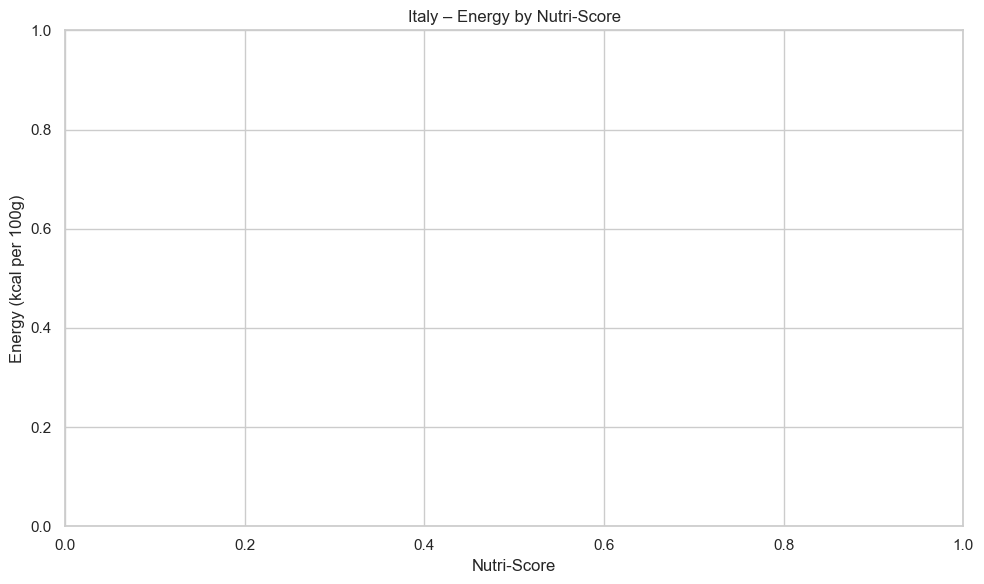

In [41]:
# ============================================================
# ITALY — NUTRI-SCORE VS SUGAR / ENERGY
# ============================================================

if "nutriscore_grade" in italy_df.columns:

    italy_nutri_sugar = italy_df[
        ["nutriscore_grade", "nutriments.sugars_100g_num"]
    ].dropna()

    print("Sugar by Nutri-Score:")
    display(
        italy_nutri_sugar.groupby("nutriscore_grade")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=italy_nutri_sugar,
        x="nutriscore_grade",
        y="nutriments.sugars_100g_num"
    )
    plt.title("Italy – Sugar Distribution by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

    italy_nutri_energy = italy_df[
        ["nutriscore_grade", "nutriments.energy-kcal_100g_num"]
    ].dropna()

    print("Energy by Nutri-Score:")
    display(
        italy_nutri_energy.groupby("nutriscore_grade")
        ["nutriments.energy-kcal_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=italy_nutri_energy,
        x="nutriscore_grade",
        y="nutriments.energy-kcal_100g_num"
    )
    plt.title("Italy – Energy by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Energy (kcal per 100g)")
    plt.tight_layout()
    plt.show()

,count,mean,median,min,max
nova_group,,,,,


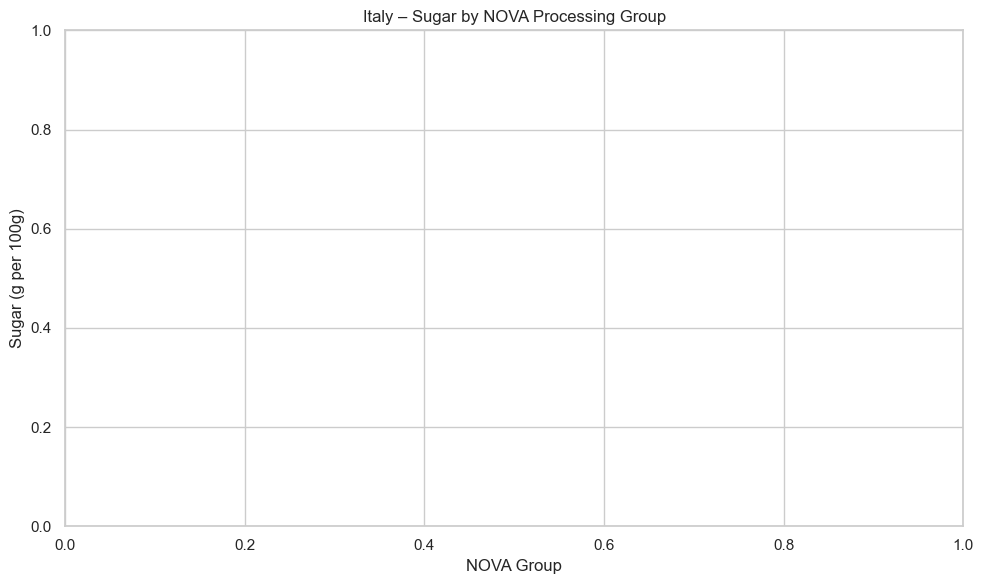

In [42]:
# ============================================================
# ITALY — NOVA VS SUGAR
# ============================================================

if "nova_group" in italy_df.columns:

    italy_nova_sugar = italy_df[
        ["nova_group", "nutriments.sugars_100g_num"]
    ].dropna()

    display(
        italy_nova_sugar.groupby("nova_group")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=italy_nova_sugar,
        x="nova_group",
        y="nutriments.sugars_100g_num"
    )
    plt.title("Italy – Sugar by NOVA Processing Group")
    plt.xlabel("NOVA Group")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

,nova_group_num,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num
nova_group_num,1.0,NaN,NaN
nutriments.sugars_100g_num,NaN,NaN,NaN
nutriments.energy-kcal_100g_num,NaN,NaN,NaN


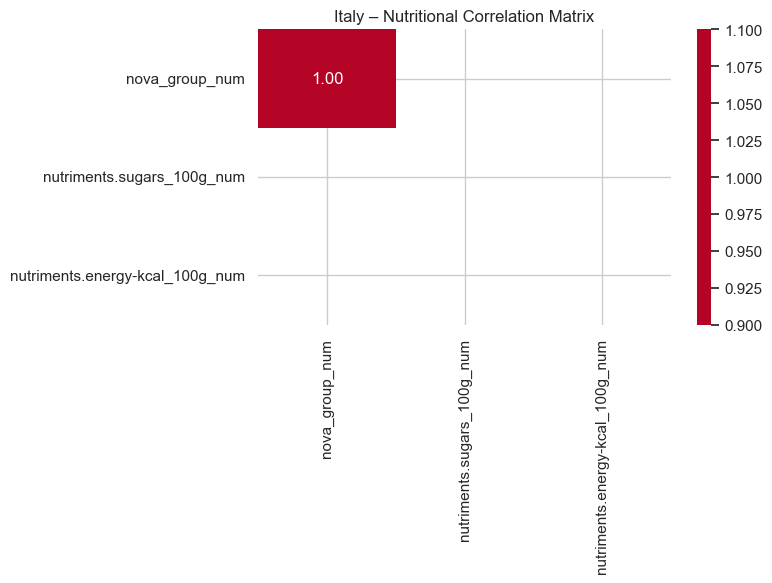

In [43]:
# ============================================================
# ITALY — CORRELATION
# ============================================================

corr_cols = [
    "nova_group_num",
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

available_corr_cols = [c for c in corr_cols if c in italy_df.columns]

italy_corr = italy_df[available_corr_cols].corr()

display(italy_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    italy_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Italy – Nutritional Correlation Matrix")
plt.tight_layout()
plt.show()

,Ingredient,Frequency
0,acqua,16
1,zucchero,11
2,anidride carbonica,9
3,sale,8
4,acidificante acido citrico,7
5,aromi,7
6,aromi naturali di agrumi,6
7,stabilizzante gomma d'acacia,5
8,acesulfame k e sucralosio,4
9,correttore di acidità citrato trisodico,3


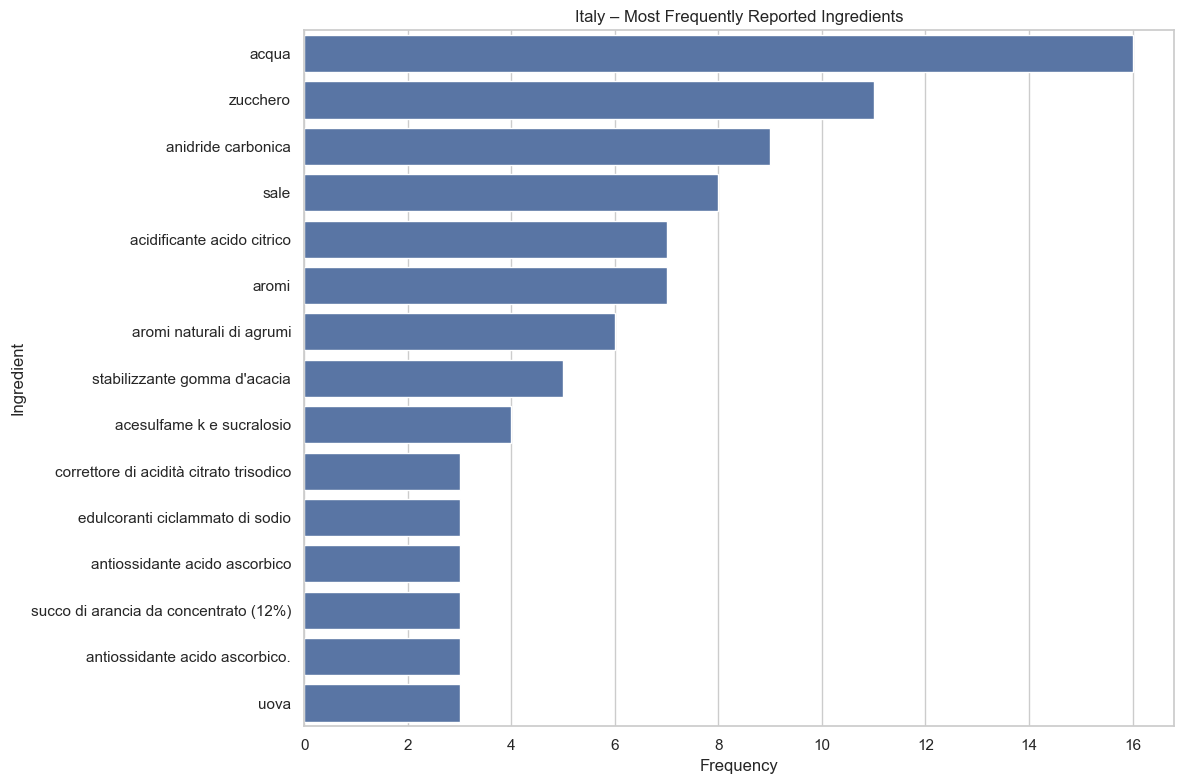

In [44]:
# ============================================================
# ITALY — INGREDIENT ANALYSIS
# ============================================================

if "ingredients_text" in italy_df.columns:

    ingredient_text = italy_df["ingredients_text"].astype(str).str.lower()
    all_ingredients = []

    for text in ingredient_text:
        if text != "unknown":
            for ingredient in text.split(","):
                ingredient = ingredient.strip()
                if ingredient and ingredient != "unknown":
                    all_ingredients.append(ingredient)

    italy_ingredient_counts = Counter(all_ingredients)

    italy_ingredient_df = pd.DataFrame(
        italy_ingredient_counts.most_common(30),
        columns=["Ingredient", "Frequency"]
    )

    display(italy_ingredient_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=italy_ingredient_df.head(15),
        x="Frequency",
        y="Ingredient"
    )
    plt.title("Italy – Most Frequently Reported Ingredients")
    plt.xlabel("Frequency")
    plt.ylabel("Ingredient")
    plt.tight_layout()
    plt.show()

In [45]:
# ============================================================
# ITALY — CATEGORY VS NUTRITION
# ============================================================

if "categories_tags" in italy_df.columns:

    italy_category_nutrition = (
        italy_df.groupby("categories_tags")
        .agg(
            Product_Count=("product_name", "count"),
            Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
            Avg_Energy=("nutriments.energy-kcal_100g_num", "mean")
        )
        .reset_index()
    )

    italy_category_nutrition = (
        italy_category_nutrition[
            italy_category_nutrition["Product_Count"] >= 2
        ]
        .sort_values("Product_Count", ascending=False)
    )

    display(italy_category_nutrition.head(20))

,categories_tags,Product_Count,Avg_Sugar,Avg_Energy
0,Unknown,174,NaN,NaN
34,"plant-based-foods-and-beverages, plant-based-foods",14,NaN,NaN
17,"desserts, frozen-foods, frozen-desserts",6,NaN,NaN
69,"plant-based-foods-and-beverages, plant-based-foods, meals, soups",4,NaN,NaN
2,"beverages, alcoholic-beverages",3,NaN,NaN
36,"plant-based-foods-and-beverages, plant-based-foods, breakfasts, spreads, plant-based-spreads, sweet-spreads, fruit-a...",3,NaN,NaN
57,"plant-based-foods-and-beverages, plant-based-foods, fruits-and-vegetables-based-foods, vegetables-based-foods",3,NaN,NaN
7,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",3,NaN,NaN
14,"breakfasts, spreads, sweet-spreads",3,NaN,NaN
77,"seafood, frozen-foods, frozen-seafood",3,NaN,NaN


In [46]:
# ============================================================
# ITALY — ATTRIBUTE-LEVEL ANALYSIS
# ============================================================

categorical_columns = [
    "brands",
    "categories_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "nutriscore_grade",
    "nova_group",
    "ecoscore_grade"
]

for col in categorical_columns:
    if col in italy_df.columns:
        print("\n" + "=" * 70)
        print(f"ATTRIBUTE: {col}")
        print("=" * 70)

        counts = (
            italy_df[col]
            .astype(str)
            .value_counts()
            .head(15)
        )

        display(counts.to_frame("Count"))


ATTRIBUTE: brands


,Count
brands,
Unknown,79
Fanta,29
Fantasie Aromatiche,27
"Fantasy, Menz & Gasser",8
Gusto e fantasia,6
"Euroverde, Fantasie dell'Orto",5
Coop,5
Gallo,4
Selex,4



ATTRIBUTE: categories_tags


,Count
categories_tags,
Unknown,174
"plant-based-foods-and-beverages, plant-based-foods",14
"desserts, frozen-foods, frozen-desserts",6
"plant-based-foods-and-beverages, plant-based-foods, meals, soups",4
"seafood, frozen-foods, frozen-seafood",3
"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",3
"plant-based-foods-and-beverages, plant-based-foods, breakfasts, spreads, plant-based-spreads, sweet-spreads, fruit-and-vegetable-preserves, jams",3
"breakfasts, spreads, sweet-spreads",3
"snacks, sweet-snacks, confectioneries",3



ATTRIBUTE: packaging_tags


...

,Count
nutriscore_grade,
unknown,206
d,26
c,25
a,18
e,16
b,14
not-applicable,9
Unknown,1



ATTRIBUTE: nova_group


,Count
nova_group,
Unknown,279
4.0,23
3.0,7
1.0,6



ATTRIBUTE: ecoscore_grade


,Count
ecoscore_grade,
Unknown,314
unknown,1


In [47]:
# ============================================================
# ITALY — NUMERICAL ATTRIBUTE ANALYSIS
# ============================================================

numerical_columns = [
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

italy_numeric_summary = []

for col in numerical_columns:
    if col in italy_df.columns:
        italy_numeric_summary.append({
            "Attribute": col,
            "Count": italy_df[col].count(),
            "Mean": italy_df[col].mean(),
            "Median": italy_df[col].median(),
            "Std": italy_df[col].std(),
            "Minimum": italy_df[col].min(),
            "Maximum": italy_df[col].max()
        })

italy_numeric_summary = pd.DataFrame(italy_numeric_summary)
display(italy_numeric_summary.round(2))

c:\Users\Sahil bopche\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Sahil bopche\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,Attribute,Count,Mean,Median,Std,Minimum,Maximum
0,nutriments.sugars_100g_num,0,NaN,NaN,NaN,NaN,NaN
1,nutriments.energy-kcal_100g_num,0,NaN,NaN,NaN,NaN,NaN


In [48]:
# ============================================================
# ITALY — DATA QUALITY CHECK
# ============================================================

print("ITALY DATA QUALITY CHECK")
print("=" * 60)

print("Duplicate Rows:", italy_df.duplicated().sum())
print("Duplicate Product Names:", italy_df["product_name"].duplicated().sum())
print("Unique Products:", italy_df["product_name"].nunique())
print("Unique Brands:", italy_df["brands"].nunique())
print("Records:", len(italy_df))

ITALY DATA QUALITY CHECK
Duplicate Rows: 0
Duplicate Product Names: 52
Unique Products: 263
Unique Brands: 126
Records: 315


In [49]:
# ============================================================
# ITALY — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("🌍 ITALY – ADVANCED DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nTotal Records: {len(italy_df):,}")
print(f"Unique Products: {italy_df['product_name'].nunique():,}")
print(f"Unique Brands: {italy_df['brands'].nunique():,}")

print("\nTop 5 Brands:")
display(italy_brand_counts.head(5))

print("\nTop 5 Categories:")
display(italy_category_counts.head(5))

print("\nTop Packaging Types:")
display(italy_packaging_counts.head(5))

print("\nTop Stores:")
display(italy_store_counts.head(5))

print("\nTop Purchase Places:")
display(italy_purchase_counts.head(5))

if "nutriscore_grade" in italy_df.columns:
    print("\nNutri-Score Distribution:")
    display(italy_df["nutriscore_grade"].value_counts())

if "nova_group" in italy_df.columns:
    print("\nNOVA Distribution:")
    display(italy_df["nova_group"].value_counts())

if "ecoscore_grade" in italy_df.columns:
    print("\nEco-Score Distribution:")
    display(italy_df["ecoscore_grade"].value_counts())

print("\nNutritional Statistics:")
display(pd.DataFrame({
    "Metric": [
        "Average Sugar", "Median Sugar", "Maximum Sugar",
        "Average Energy", "Median Energy", "Maximum Energy"
    ],
    "Value": [
        italy_sugar.mean(), italy_sugar.median(), italy_sugar.max(),
        italy_energy.mean(), italy_energy.median(), italy_energy.max()
    ]
}).round(2))

print("\nSugar–Energy Correlation:", round(italy_sugar_energy_corr, 3))
print("\nAnalysis completed for Italy.")

🌍 ITALY – ADVANCED DATA ANALYSIS SUMMARY

Total Records: 315
Unique Products: 263
Unique Brands: 126

Top 5 Brands:


,Brand,Product_Count
0,Unknown,79
1,Fanta,29
2,Fantasie Aromatiche,27
3,"Fantasy, Menz & Gasser",8
4,Gusto e fantasia,6



Top 5 Categories:


categories_tags
plant-based-foods-and-beverages    75
plant-based-foods                  66
beverages                          20
frozen-foods                       17
snacks                             16
Name: count, dtype: int64


Top Packaging Types:


...


Eco-Score Distribution:


ecoscore_grade
Unknown    314
unknown      1
Name: count, dtype: int64


Nutritional Statistics:


,Metric,Value
0,Average Sugar,NaN
1,Median Sugar,NaN
2,Maximum Sugar,NaN
3,Average Energy,NaN
4,Median Energy,NaN
5,Maximum Energy,NaN



Sugar–Energy Correlation: nan

Analysis completed for Italy.


# 🇬🇧 PART — UNITED KINGDOM

The same complete analysis framework is applied to **United Kingdom only**.

In [50]:
# ============================================================
# UNITED KINGDOM DATASET
# ============================================================

uk_df = df[
    df["countries_tags"].astype(str).str.lower() == "united-kingdom"
].copy()

print("UNITED KINGDOM DATASET")
print("=" * 60)
print("Records:", len(uk_df))
print("Attributes:", len(uk_df.columns))
display(uk_df.head())

UNITED KINGDOM DATASET
Records: 143
Attributes: 17


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num,nova_group_num
7,20284299,Fantail Prawns,"OceanSea,Tesco","seafood, crustaceans, shrimps, prawns",united-kingdom,"tray, plastic-tray, sleeve-board","Lidl,Tesco","Barnet,London,UK",c,3.0,Unknown,"Prawns 95% (_crustaceans_), salt, lactic acid, acetic acid",Unknown,Unknown,NaN,NaN,3.0
15,5000112628944,Fanta Fruit Twist,Fanta,Unknown,united-kingdom,pet-bottle,Unknown,Unknown,unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN
21,5000112631593,Fanta fruit twist,Fanta,Unknown,united-kingdom,Unknown,Unknown,Unknown,unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN
22,5449000265197,Fanta,"Fanta, Coco Coka",Unknown,united-kingdom,pet-bottle,Unknown,Unknown,unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN
23,5000112639605,Fanta Grape,Fanta,"plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas",united-kingdom,Unknown,Unknown,Unknown,b,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN


In [51]:
# ============================================================
# UNITED KINGDOM — BASIC OVERVIEW
# ============================================================

print("Dataset Shape:", uk_df.shape)
print("\nColumn Names:")
print(uk_df.columns.tolist())

print("\nData Types:")
display(uk_df.dtypes)

print("\nStatistical Summary:")
display(uk_df.describe(include="all").T)

Dataset Shape: (143, 17)

Column Names:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g', 'nutriments.sugars_100g_num', 'nutriments.energy-kcal_100g_num', 'nova_group_num']

Data Types:


code                                object
product_name                        object
brands                              object
categories_tags                     object
countries_tags                      object
packaging_tags                      object
stores                              object
purchase_places                     object
nutriscore_grade                    object
nova_group                          object
ecoscore_grade                      object
ingredients_text                    object
nutriments.sugars_100g              object
nutriments.energy-kcal_100g         object
nutriments.sugars_100g_num         float64
nutriments.energy-kcal_100g_num    float64
nova_group_num                     float64
dtype: object


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,143,143,20284299,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,143,101,Fanta,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brands,143,30,Fanta,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories_tags,143,35,Unknown,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countries_tags,143,1,united-kingdom,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packaging_tags,143,8,Unknown,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stores,143,6,Unknown,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_places,143,2,Unknown,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutriscore_grade,143,6,unknown,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nova_group,143,4,Unknown,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Attribute,Unknown_Count,Total_Records,Unknown_Percentage
13,nutriments.energy-kcal_100g,143,143,100.00
12,nutriments.sugars_100g,143,143,100.00
7,purchase_places,142,143,99.30
10,ecoscore_grade,142,143,99.30
6,stores,138,143,96.50
5,packaging_tags,128,143,89.51
9,nova_group,109,143,76.22
8,nutriscore_grade,106,143,74.13
11,ingredients_text,103,143,72.03
3,categories_tags,97,143,67.83


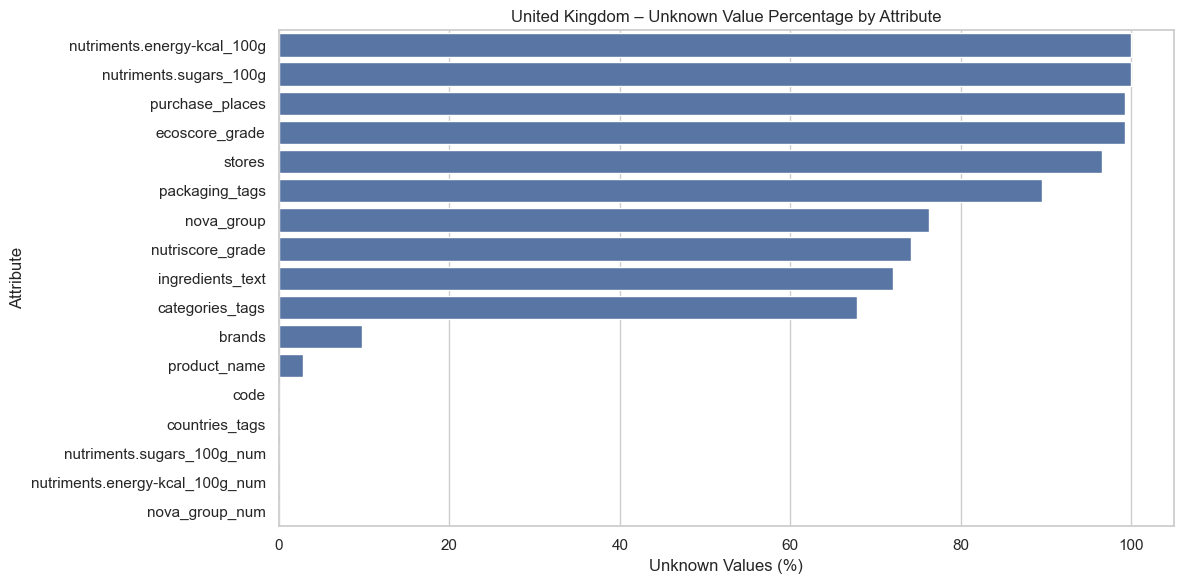

In [52]:
# ============================================================
# UNITED KINGDOM — UNKNOWN VALUE ANALYSIS
# ============================================================

uk_unknown_summary = []

for col in uk_df.columns:
    unknown_count = (
        uk_df[col].astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    uk_unknown_summary.append({
        "Attribute": col,
        "Unknown_Count": unknown_count,
        "Total_Records": len(uk_df),
        "Unknown_Percentage": round(
            unknown_count / len(uk_df) * 100, 2
        )
    })

uk_unknown_df = pd.DataFrame(uk_unknown_summary).sort_values(
    "Unknown_Percentage", ascending=False
)

display(uk_unknown_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=uk_unknown_df,
            x="Unknown_Percentage", y="Attribute")
plt.title("United Kingdom – Unknown Value Percentage by Attribute")
plt.xlabel("Unknown Values (%)")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

Top 20 Products:


,Product_Name,Frequency
0,Fanta,14
1,Fanta fruit twist,6
2,Fanta Orange,6
3,Fanta Lemon,4
4,Unknown,4
5,Fanta Grape,3
6,Fruit Twist,3
7,Fantasy brownies,2
8,Fanta Fruit Twist,2
9,fanta fruit twist,2


Total Product Records: 143
Unique Products: 101
Product Uniqueness Rate: 70.63 %


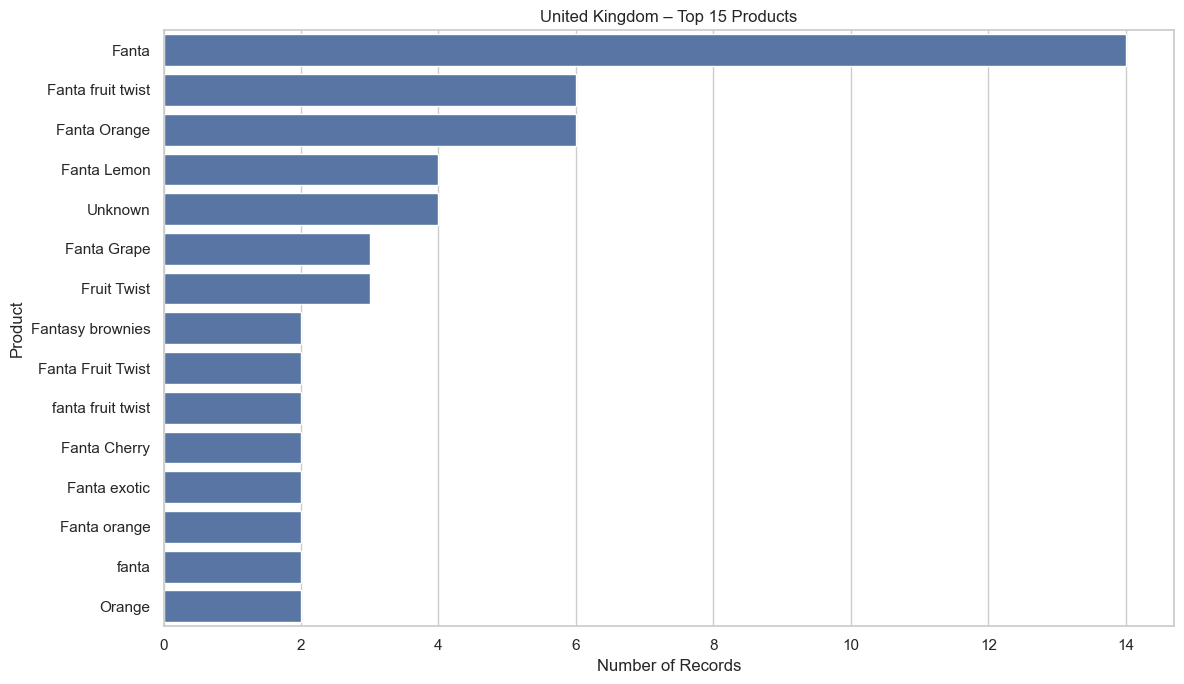

In [53]:
# ============================================================
# UNITED KINGDOM — PRODUCT ANALYSIS
# ============================================================

uk_product_counts = (
    uk_df["product_name"].value_counts().reset_index()
)
uk_product_counts.columns = ["Product_Name", "Frequency"]

print("Top 20 Products:")
display(uk_product_counts.head(20))

print("Total Product Records:", len(uk_df))
print("Unique Products:", uk_df["product_name"].nunique())
print(
    "Product Uniqueness Rate:",
    round(uk_df["product_name"].nunique() / len(uk_df) * 100, 2),
    "%"
)

plt.figure(figsize=(12, 7))
sns.barplot(data=uk_product_counts.head(15),
            x="Frequency", y="Product_Name")
plt.title("United Kingdom – Top 15 Products")
plt.xlabel("Number of Records")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

Top 20 Brands:


,Brand,Product_Count
0,Fanta,96
1,Unknown,14
2,Coca Cola,3
3,Brompton House,3
4,Sunfeast,2
5,"OceanSea,Tesco",1
6,Dorset cereals,1
7,"Sierra, Fanta",1
8,Gelatelli,1
9,"Fanta, Coca-Cola",1


Unique Brands: 30
Brand Diversity Ratio: 20.98 %


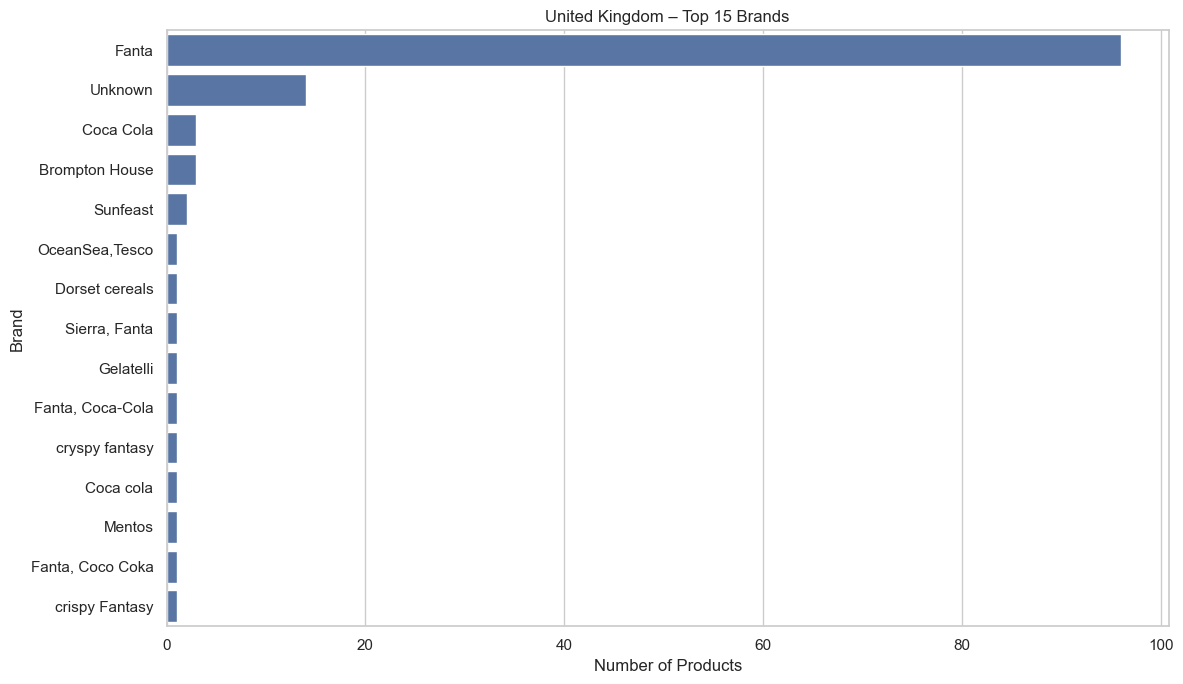

In [54]:
# ============================================================
# UNITED KINGDOM — BRAND ANALYSIS
# ============================================================

uk_brand_counts = (
    uk_df["brands"].value_counts().reset_index()
)
uk_brand_counts.columns = ["Brand", "Product_Count"]

print("Top 20 Brands:")
display(uk_brand_counts.head(20))

print("Unique Brands:", uk_df["brands"].nunique())

uk_brand_diversity = (
    uk_df["brands"].nunique() / len(uk_df) * 100
)
print("Brand Diversity Ratio:", round(uk_brand_diversity, 2), "%")

plt.figure(figsize=(12, 7))
sns.barplot(data=uk_brand_counts.head(15),
            x="Product_Count", y="Brand")
plt.title("United Kingdom – Top 15 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Top 25 Categories:


categories_tags
beverages                               34
carbonated-drinks                       25
sodas                                   23
beverages-and-beverages-preparations    22
plant-based-foods-and-beverages         18
fruit-based-beverages                   15
plant-based-beverages                   15
fruit-sodas                             14
sweetened-beverages                     11
artificially-sweetened-beverages         9
orange-soft-drinks                       6
snacks                                   5
sweet-snacks                             5
cereals-and-their-products               3
plant-based-foods                        3
cereals-and-potatoes                     3
breakfasts                               3
carbonated-fruit-soft-drink              3
biscuits-and-cakes                       3
breakfast-cereals                        3
chocolate-cakes                          2
energy-drinks                            2
confectioneries                       

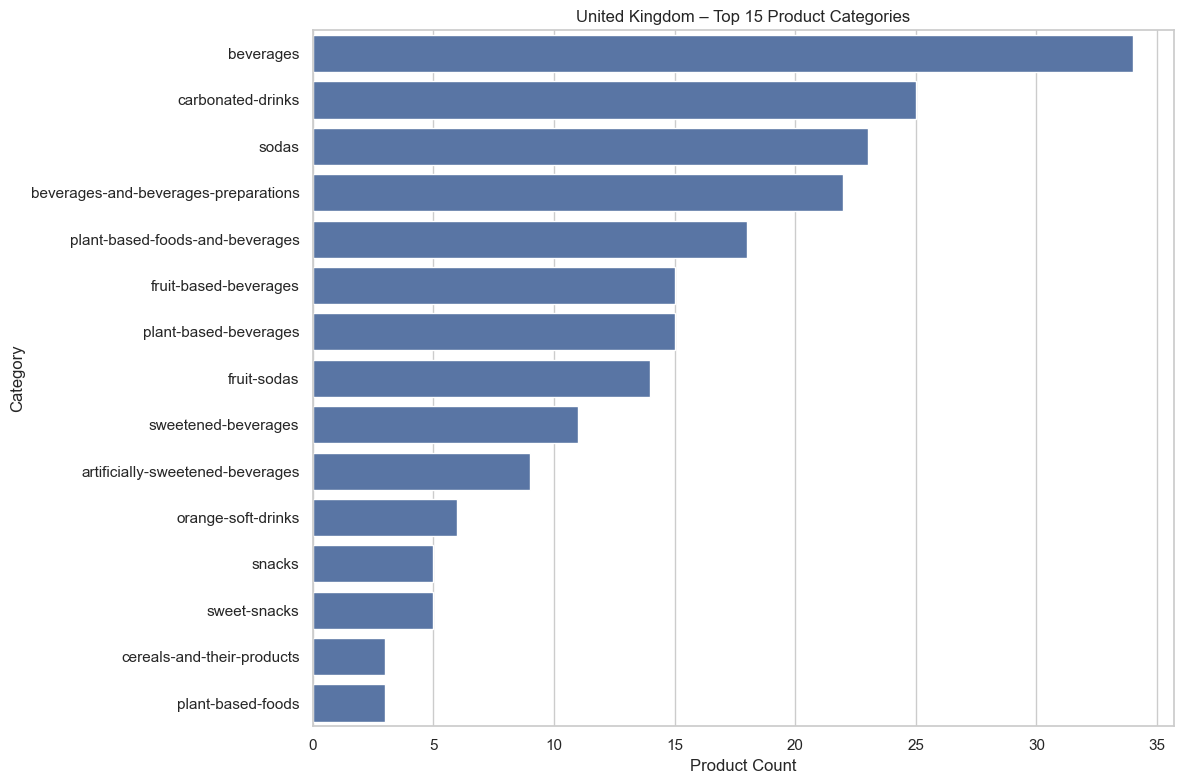

In [55]:
# ============================================================
# UNITED KINGDOM — CATEGORY ANALYSIS
# ============================================================

uk_category_series = (
    uk_df["categories_tags"].astype(str)
    .str.split(",").explode().str.strip()
)

uk_category_series = uk_category_series[
    uk_category_series.str.lower() != "unknown"
]

uk_category_counts = uk_category_series.value_counts()

print("Top 25 Categories:")
display(uk_category_counts.head(25))

uk_top_categories = uk_category_counts.head(15).reset_index()
uk_top_categories.columns = ["Category", "Product_Count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=uk_top_categories,
            x="Product_Count", y="Category")
plt.title("United Kingdom – Top 15 Product Categories")
plt.xlabel("Product Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# UNITED KINGDOM — PACKAGING, STORE AND PURCHASE PLACE
# ============================================================

def analyze_multivalue_attribute(country_df, column, label):
    if column not in country_df.columns:
        print(f"Column not found: {column}")
        return pd.Series(dtype="int64")

    s = country_df[column].astype(str).str.split(",").explode().str.strip()
    s = s[s.str.lower() != "unknown"]
    counts = s.value_counts()

    print(f"Top {label}:")
    display(counts.head(20).to_frame("Count"))
    return counts

uk_packaging_counts = analyze_multivalue_attribute(
    uk_df, "packaging_tags", "Packaging Types"
)
uk_store_counts = analyze_multivalue_attribute(
    uk_df, "stores", "Stores"
)
uk_purchase_counts = analyze_multivalue_attribute(
    uk_df, "purchase_places", "Purchase Places"
)

Top Packaging Types:


,Count
packaging_tags,
pet-bottle,10
glass-bottle,2
tray,1
sleeve-board,1
plastic-tray,1
pet-cap,1
bottle-or-vial,1
bottle,1
ldpe-bag,1


Top Stores:


,Count
stores,
Tesco,2
Lidl,1
migros,1
B&M,1
ASDA,1


Top Purchase Places:


,Count
purchase_places,
Barnet,1
London,1
UK,1


Nutri-Score Distribution:


nutriscore_grade
unknown    106
c           14
d           11
b            6
e            5
a            1
Name: count, dtype: int64

Nutri-Score Percentage:


nutriscore_grade
unknown    74.13
c           9.79
d           7.69
b           4.20
e           3.50
a           0.70
Name: proportion, dtype: float64

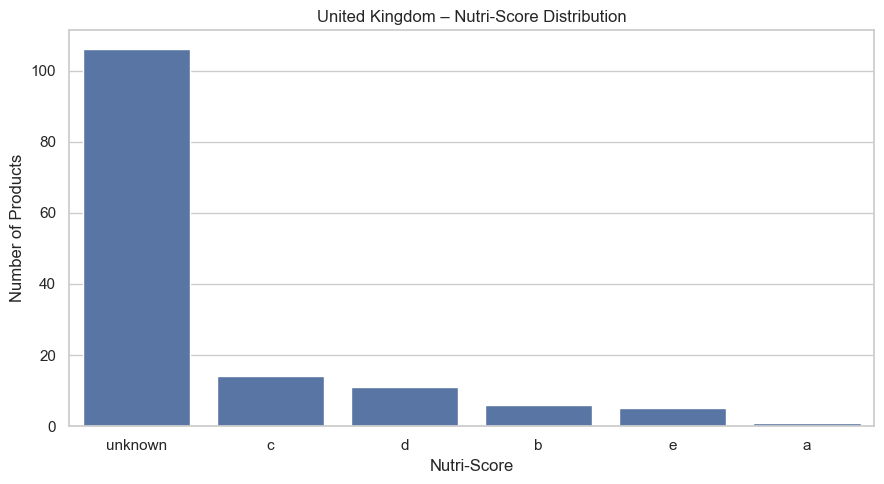

NOVA Group Distribution:


nova_group
Unknown    109
4.0         29
3.0          4
1.0          1
Name: count, dtype: int64

NOVA Group Percentage:


nova_group
Unknown    76.22
4.0        20.28
3.0         2.80
1.0         0.70
Name: proportion, dtype: float64

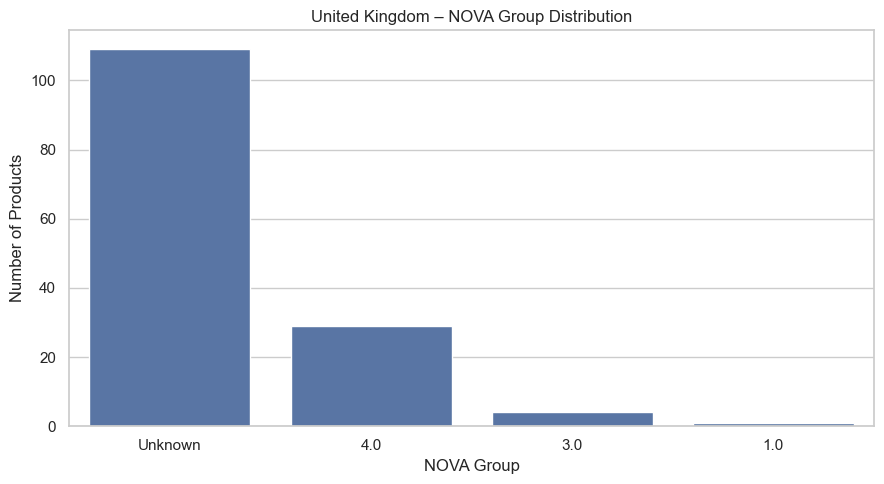

Eco-Score Distribution:


ecoscore_grade
Unknown           134
unknown             8
not-applicable      1
Name: count, dtype: int64

Eco-Score Percentage:


ecoscore_grade
Unknown           93.71
unknown            5.59
not-applicable     0.70
Name: proportion, dtype: float64

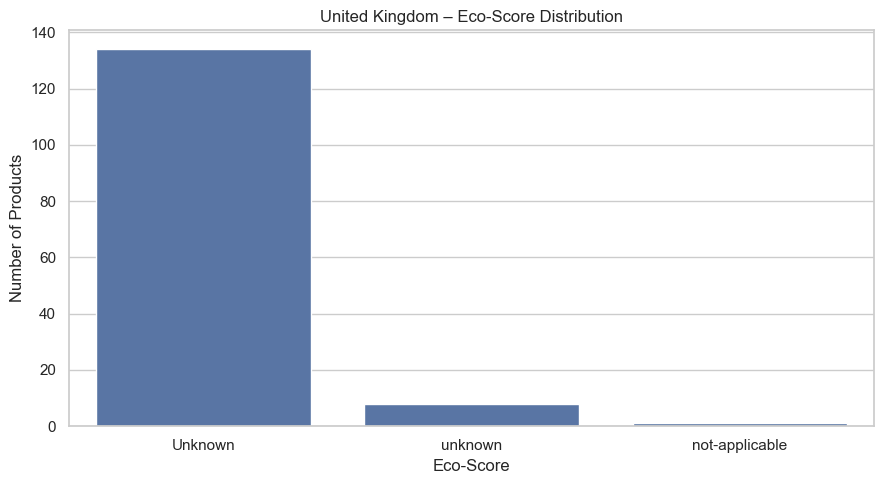

In [57]:
# ============================================================
# UNITED KINGDOM — NUTRI-SCORE, NOVA AND ECO-SCORE
# ============================================================

for col, label in [
    ("nutriscore_grade", "Nutri-Score"),
    ("nova_group", "NOVA Group"),
    ("ecoscore_grade", "Eco-Score")
]:
    if col in uk_df.columns:
        counts = uk_df[col].value_counts()
        print(f"{label} Distribution:")
        display(counts)
        print(f"{label} Percentage:")
        display(uk_df[col].value_counts(normalize=True).mul(100).round(2))

        plt.figure(figsize=(9, 5))
        sns.countplot(
            data=uk_df,
            x=col,
            order=uk_df[col].value_counts().index
        )
        plt.title(f"United Kingdom – {label} Distribution")
        plt.xlabel(label)
        plt.ylabel("Number of Products")
        plt.tight_layout()
        plt.show()

Sugar Statistics:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: nutriments.sugars_100g_num, dtype: float64

Energy Statistics:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: nutriments.energy-kcal_100g_num, dtype: float64

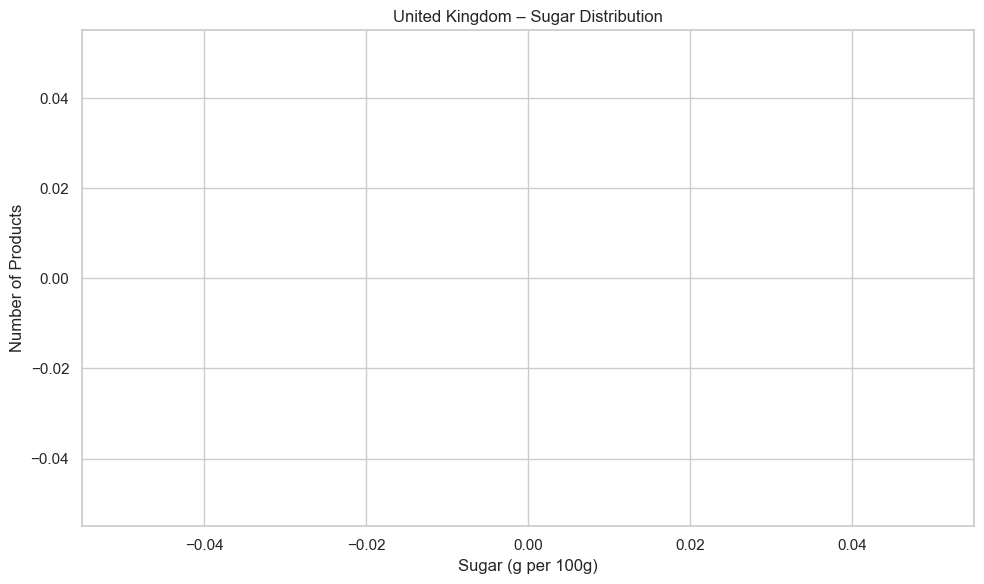

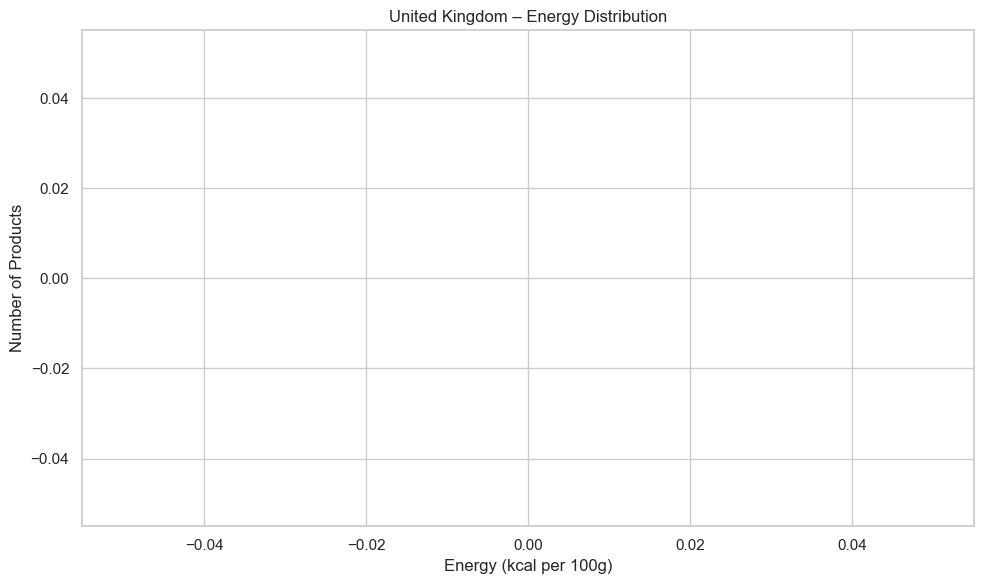

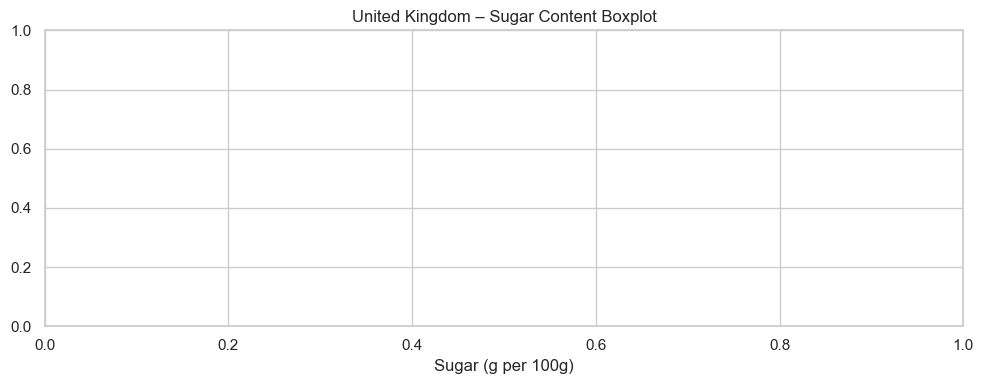

In [58]:
# ============================================================
# UNITED KINGDOM — SUGAR AND ENERGY
# ============================================================

uk_sugar = uk_df["nutriments.sugars_100g_num"].dropna()
uk_energy = uk_df["nutriments.energy-kcal_100g_num"].dropna()

print("Sugar Statistics:")
display(uk_sugar.describe())

print("Energy Statistics:")
display(uk_energy.describe())

plt.figure(figsize=(10, 6))
sns.histplot(uk_sugar, bins=30, kde=True)
plt.title("United Kingdom – Sugar Distribution")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(uk_energy, bins=30, kde=True)
plt.title("United Kingdom – Energy Distribution")
plt.xlabel("Energy (kcal per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=uk_sugar)
plt.title("United Kingdom – Sugar Content Boxplot")
plt.xlabel("Sugar (g per 100g)")
plt.tight_layout()
plt.show()

Valid nutritional records: 0
Sugar–Energy Correlation: nan


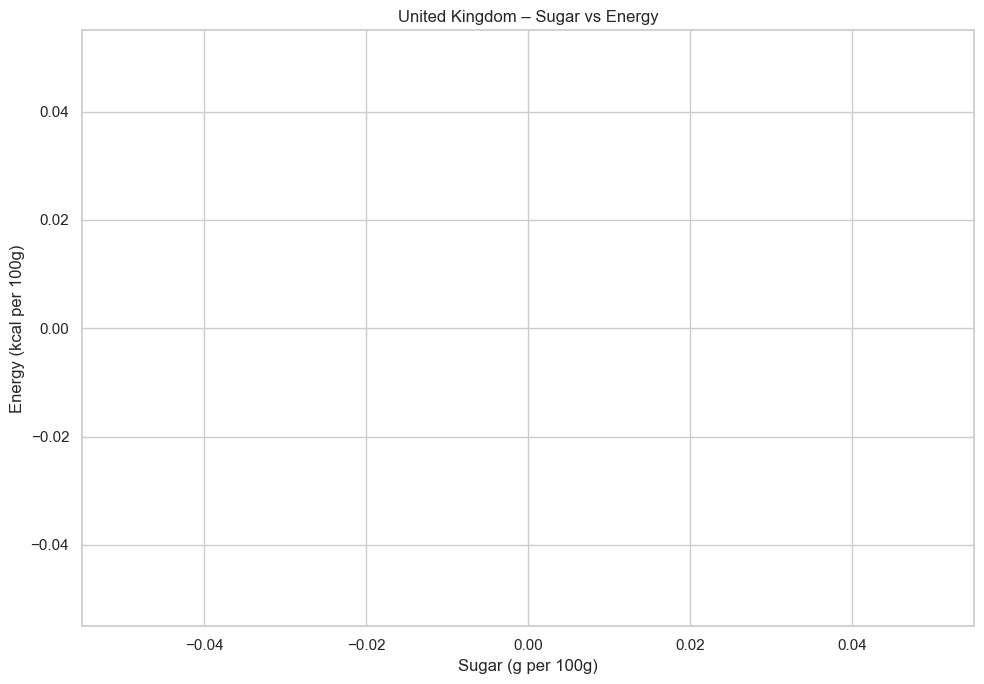

In [59]:
# ============================================================
# UNITED KINGDOM — SUGAR VS ENERGY
# ============================================================

uk_nutrition = uk_df[
    ["nutriments.sugars_100g_num", "nutriments.energy-kcal_100g_num"]
].dropna()

uk_sugar_energy_corr = (
    uk_nutrition["nutriments.sugars_100g_num"]
    .corr(uk_nutrition["nutriments.energy-kcal_100g_num"])
)

print("Valid nutritional records:", len(uk_nutrition))
print("Sugar–Energy Correlation:", round(uk_sugar_energy_corr, 3))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=uk_nutrition,
    x="nutriments.sugars_100g_num",
    y="nutriments.energy-kcal_100g_num",
    alpha=0.6
)
plt.title("United Kingdom – Sugar vs Energy")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Energy (kcal per 100g)")
plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# UNITED KINGDOM — OUTLIER ANALYSIS
# ============================================================

def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

uk_sugar_outliers = find_outliers(uk_sugar)
uk_energy_outliers = find_outliers(uk_energy)

print("Sugar Outliers:", len(uk_sugar_outliers))
print("Energy Outliers:", len(uk_energy_outliers))

print("\nHighest Sugar Products:")
display(
    uk_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.sugars_100g_num"]
    ].dropna(subset=["nutriments.sugars_100g_num"])
     .sort_values("nutriments.sugars_100g_num", ascending=False)
     .head(20)
)

print("\nHighest Energy Products:")
display(
    uk_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.energy-kcal_100g_num"]
    ].dropna(subset=["nutriments.energy-kcal_100g_num"])
     .sort_values("nutriments.energy-kcal_100g_num", ascending=False)
     .head(20)
)

Sugar Outliers: 0
Energy Outliers: 0

Highest Sugar Products:


,product_name,brands,categories_tags,nutriments.sugars_100g_num



Highest Energy Products:


,product_name,brands,categories_tags,nutriments.energy-kcal_100g_num


In [61]:
# ============================================================
# UNITED KINGDOM — BRAND NUTRITION ANALYSIS
# ============================================================

uk_brand_nutrition = (
    uk_df.groupby("brands")
    .agg(
        Product_Count=("product_name", "count"),
        Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
        Median_Sugar=("nutriments.sugars_100g_num", "median"),
        Avg_Energy=("nutriments.energy-kcal_100g_num", "mean"),
        Median_Energy=("nutriments.energy-kcal_100g_num", "median")
    )
    .reset_index()
)

uk_brand_nutrition = (
    uk_brand_nutrition[
        uk_brand_nutrition["Product_Count"] >= 3
    ]
    .sort_values("Product_Count", ascending=False)
)

display(uk_brand_nutrition.head(20))

,brands,Product_Count,Avg_Sugar,Median_Sugar,Avg_Energy,Median_Energy
12,Fanta,96,NaN,NaN,NaN,NaN
26,Unknown,14,NaN,NaN,NaN,NaN
3,Coca Cola,3,NaN,NaN,NaN,NaN
1,Brompton House,3,NaN,NaN,NaN,NaN


Sugar by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,


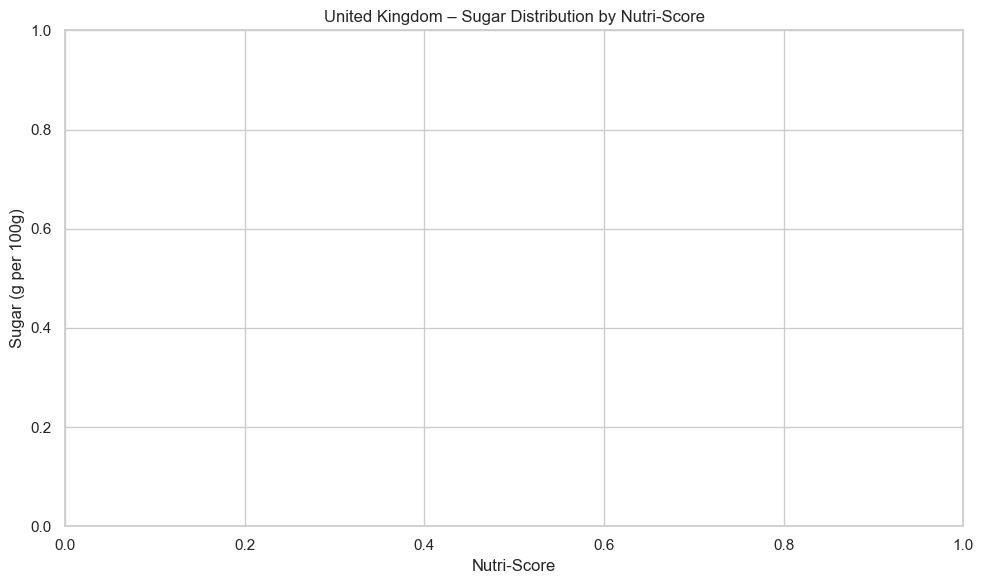

Energy by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,


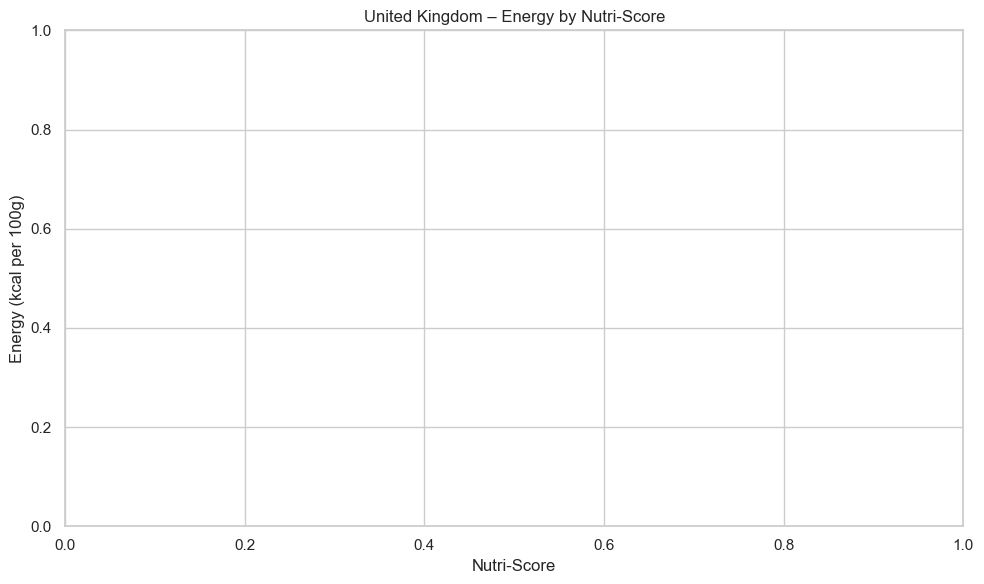

In [62]:
# ============================================================
# UNITED KINGDOM — NUTRI-SCORE VS SUGAR / ENERGY
# ============================================================

if "nutriscore_grade" in uk_df.columns:

    uk_nutri_sugar = uk_df[
        ["nutriscore_grade", "nutriments.sugars_100g_num"]
    ].dropna()

    print("Sugar by Nutri-Score:")
    display(
        uk_nutri_sugar.groupby("nutriscore_grade")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=uk_nutri_sugar,
        x="nutriscore_grade",
        y="nutriments.sugars_100g_num"
    )
    plt.title("United Kingdom – Sugar Distribution by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

    uk_nutri_energy = uk_df[
        ["nutriscore_grade", "nutriments.energy-kcal_100g_num"]
    ].dropna()

    print("Energy by Nutri-Score:")
    display(
        uk_nutri_energy.groupby("nutriscore_grade")
        ["nutriments.energy-kcal_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=uk_nutri_energy,
        x="nutriscore_grade",
        y="nutriments.energy-kcal_100g_num"
    )
    plt.title("United Kingdom – Energy by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Energy (kcal per 100g)")
    plt.tight_layout()
    plt.show()

,count,mean,median,min,max
nova_group,,,,,


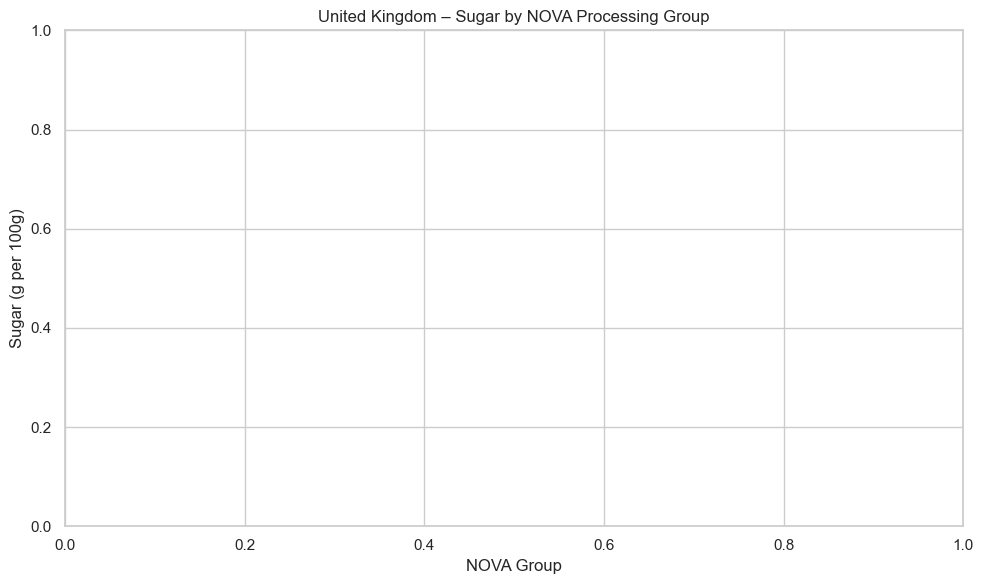

In [63]:
# ============================================================
# UNITED KINGDOM — NOVA VS SUGAR
# ============================================================

if "nova_group" in uk_df.columns:

    uk_nova_sugar = uk_df[
        ["nova_group", "nutriments.sugars_100g_num"]
    ].dropna()

    display(
        uk_nova_sugar.groupby("nova_group")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=uk_nova_sugar,
        x="nova_group",
        y="nutriments.sugars_100g_num"
    )
    plt.title("United Kingdom – Sugar by NOVA Processing Group")
    plt.xlabel("NOVA Group")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

,nova_group_num,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num
nova_group_num,1.0,NaN,NaN
nutriments.sugars_100g_num,NaN,NaN,NaN
nutriments.energy-kcal_100g_num,NaN,NaN,NaN


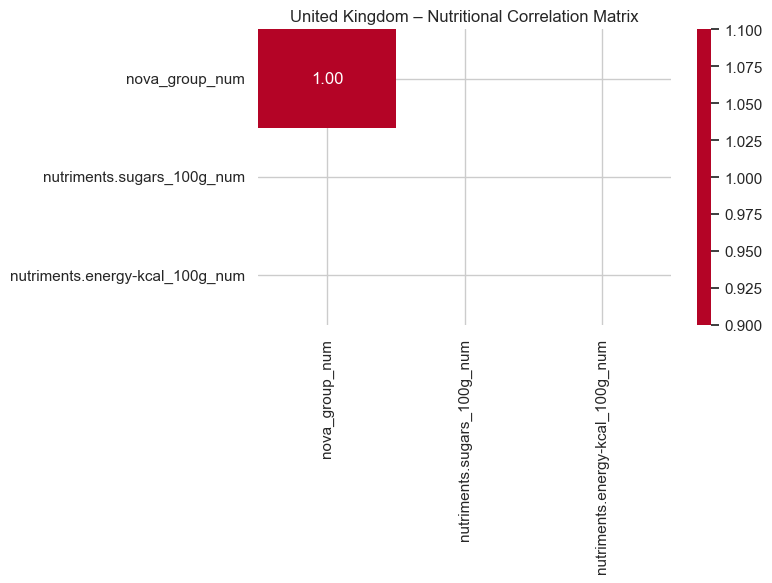

In [64]:
# ============================================================
# UNITED KINGDOM — CORRELATION
# ============================================================

corr_cols = [
    "nova_group_num",
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

available_corr_cols = [c for c in corr_cols if c in uk_df.columns]

uk_corr = uk_df[available_corr_cols].corr()

display(uk_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    uk_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("United Kingdom – Nutritional Correlation Matrix")
plt.tight_layout()
plt.show()

,Ingredient,Frequency
0,carbonated water,19
1,sugar,13
2,acid (citric acid),8
3,preservative (potassium sorbate),8
4,natural flavourings,6
5,acids (citric acid,6
6,salt,5
7,glucose syrup,5
8,sucralose),4
9,malic acid),4


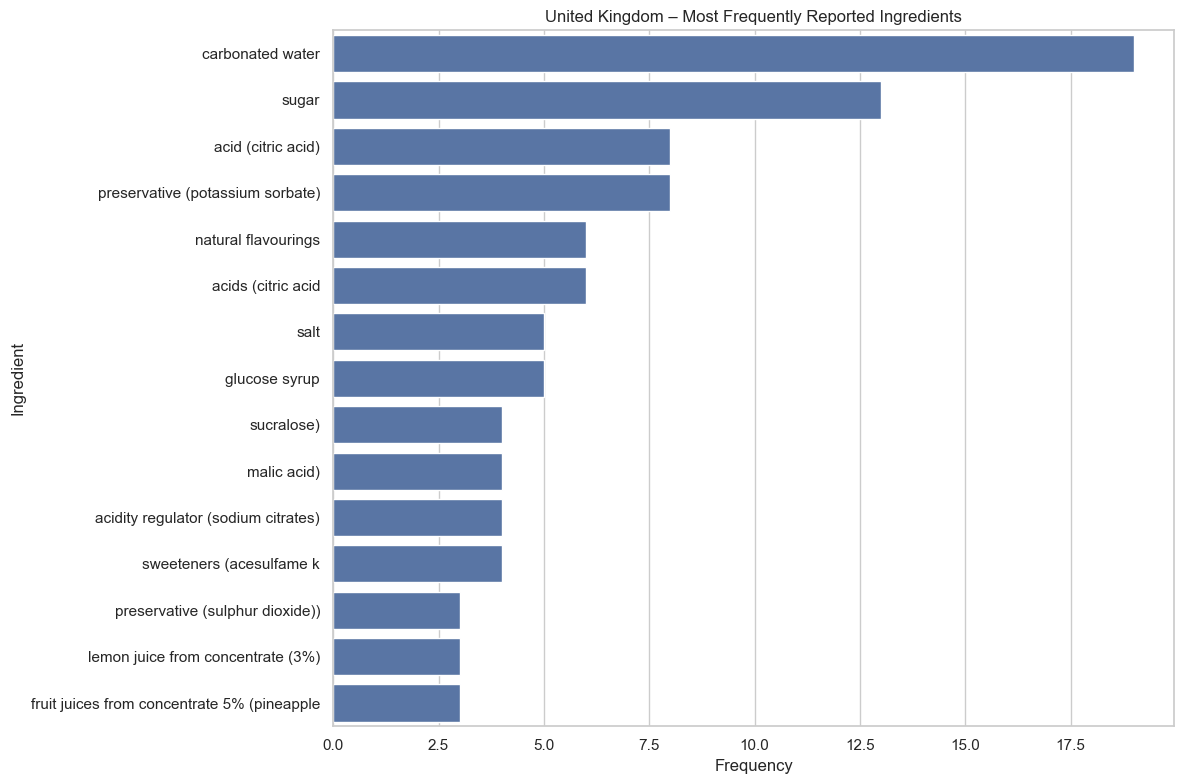

In [65]:
# ============================================================
# UNITED KINGDOM — INGREDIENT ANALYSIS
# ============================================================

if "ingredients_text" in uk_df.columns:

    ingredient_text = uk_df["ingredients_text"].astype(str).str.lower()
    all_ingredients = []

    for text in ingredient_text:
        if text != "unknown":
            for ingredient in text.split(","):
                ingredient = ingredient.strip()
                if ingredient and ingredient != "unknown":
                    all_ingredients.append(ingredient)

    uk_ingredient_counts = Counter(all_ingredients)

    uk_ingredient_df = pd.DataFrame(
        uk_ingredient_counts.most_common(30),
        columns=["Ingredient", "Frequency"]
    )

    display(uk_ingredient_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=uk_ingredient_df.head(15),
        x="Frequency",
        y="Ingredient"
    )
    plt.title("United Kingdom – Most Frequently Reported Ingredients")
    plt.xlabel("Frequency")
    plt.ylabel("Ingredient")
    plt.tight_layout()
    plt.show()

In [66]:
# ============================================================
# UNITED KINGDOM — CATEGORY VS NUTRITION
# ============================================================

if "categories_tags" in uk_df.columns:

    uk_category_nutrition = (
        uk_df.groupby("categories_tags")
        .agg(
            Product_Count=("product_name", "count"),
            Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
            Avg_Energy=("nutriments.energy-kcal_100g_num", "mean")
        )
        .reset_index()
    )

    uk_category_nutrition = (
        uk_category_nutrition[
            uk_category_nutrition["Product_Count"] >= 2
        ]
        .sort_values("Product_Count", ascending=False)
    )

    display(uk_category_nutrition.head(20))

,categories_tags,Product_Count,Avg_Sugar,Avg_Energy
1,Unknown,97,NaN,NaN
5,"beverages, carbonated-drinks, sodas",5,NaN,NaN
20,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",3,NaN,NaN
12,"beverages-and-beverages-preparations, beverages, energy-drinks",2,NaN,NaN
2,beverages,2,NaN,NaN
13,"beverages-and-beverages-preparations, beverages, sweetened-beverages",2,NaN,NaN
17,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",2,NaN,NaN
22,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",2,NaN,NaN
32,"snacks, sweet-snacks, biscuits-and-cakes, cakes, chocolate-cakes, brownies",2,NaN,NaN


In [67]:
# ============================================================
# UNITED KINGDOM — ATTRIBUTE-LEVEL ANALYSIS
# ============================================================

categorical_columns = [
    "brands",
    "categories_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "nutriscore_grade",
    "nova_group",
    "ecoscore_grade"
]

for col in categorical_columns:
    if col in uk_df.columns:
        print("\n" + "=" * 70)
        print(f"ATTRIBUTE: {col}")
        print("=" * 70)

        counts = (
            uk_df[col]
            .astype(str)
            .value_counts()
            .head(15)
        )

        display(counts.to_frame("Count"))


ATTRIBUTE: brands


,Count
brands,
Fanta,96
Unknown,14
Coca Cola,3
Brompton House,3
Sunfeast,2
"OceanSea,Tesco",1
Dorset cereals,1
"Sierra, Fanta",1
Gelatelli,1



ATTRIBUTE: categories_tags


,Count
categories_tags,
Unknown,97
"beverages, carbonated-drinks, sodas",5
"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, fruit-sodas, orange-soft-drinks",3
"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, fruit-sodas, sweetened-beverages",2
"beverages-and-beverages-preparations, beverages, energy-drinks",2
beverages,2
"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, artificially-sweetened-beverages, sodas, fruit-sodas, sweetened-beverages",2
"beverages-and-beverages-preparations, beverages, sweetened-beverages",2
"snacks, sweet-snacks, biscuits-and-cakes, cakes, chocolate-cakes, brownies",2



ATTRIBUTE: packaging_tags


...

,Count
nutriscore_grade,
unknown,106
c,14
d,11
b,6
e,5
a,1



ATTRIBUTE: nova_group


,Count
nova_group,
Unknown,109
4.0,29
3.0,4
1.0,1



ATTRIBUTE: ecoscore_grade


,Count
ecoscore_grade,
Unknown,134
unknown,8
not-applicable,1


In [68]:
# ============================================================
# UNITED KINGDOM — NUMERICAL ATTRIBUTE ANALYSIS
# ============================================================

numerical_columns = [
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

uk_numeric_summary = []

for col in numerical_columns:
    if col in uk_df.columns:
        uk_numeric_summary.append({
            "Attribute": col,
            "Count": uk_df[col].count(),
            "Mean": uk_df[col].mean(),
            "Median": uk_df[col].median(),
            "Std": uk_df[col].std(),
            "Minimum": uk_df[col].min(),
            "Maximum": uk_df[col].max()
        })

uk_numeric_summary = pd.DataFrame(uk_numeric_summary)
display(uk_numeric_summary.round(2))

c:\Users\Sahil bopche\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Sahil bopche\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,Attribute,Count,Mean,Median,Std,Minimum,Maximum
0,nutriments.sugars_100g_num,0,NaN,NaN,NaN,NaN,NaN
1,nutriments.energy-kcal_100g_num,0,NaN,NaN,NaN,NaN,NaN


In [69]:
# ============================================================
# UNITED KINGDOM — DATA QUALITY CHECK
# ============================================================

print("UNITED KINGDOM DATA QUALITY CHECK")
print("=" * 60)

print("Duplicate Rows:", uk_df.duplicated().sum())
print("Duplicate Product Names:", uk_df["product_name"].duplicated().sum())
print("Unique Products:", uk_df["product_name"].nunique())
print("Unique Brands:", uk_df["brands"].nunique())
print("Records:", len(uk_df))

UNITED KINGDOM DATA QUALITY CHECK
Duplicate Rows: 0
Duplicate Product Names: 42
Unique Products: 101
Unique Brands: 30
Records: 143


In [70]:
# ============================================================
# UNITED KINGDOM — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("🌍 UNITED KINGDOM – ADVANCED DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nTotal Records: {len(uk_df):,}")
print(f"Unique Products: {uk_df['product_name'].nunique():,}")
print(f"Unique Brands: {uk_df['brands'].nunique():,}")

print("\nTop 5 Brands:")
display(uk_brand_counts.head(5))

print("\nTop 5 Categories:")
display(uk_category_counts.head(5))

print("\nTop Packaging Types:")
display(uk_packaging_counts.head(5))

print("\nTop Stores:")
display(uk_store_counts.head(5))

print("\nTop Purchase Places:")
display(uk_purchase_counts.head(5))

if "nutriscore_grade" in uk_df.columns:
    print("\nNutri-Score Distribution:")
    display(uk_df["nutriscore_grade"].value_counts())

if "nova_group" in uk_df.columns:
    print("\nNOVA Distribution:")
    display(uk_df["nova_group"].value_counts())

if "ecoscore_grade" in uk_df.columns:
    print("\nEco-Score Distribution:")
    display(uk_df["ecoscore_grade"].value_counts())

print("\nNutritional Statistics:")
display(pd.DataFrame({
    "Metric": [
        "Average Sugar", "Median Sugar", "Maximum Sugar",
        "Average Energy", "Median Energy", "Maximum Energy"
    ],
    "Value": [
        uk_sugar.mean(), uk_sugar.median(), uk_sugar.max(),
        uk_energy.mean(), uk_energy.median(), uk_energy.max()
    ]
}).round(2))

print("\nSugar–Energy Correlation:", round(uk_sugar_energy_corr, 3))
print("\nAnalysis completed for United Kingdom.")

🌍 UNITED KINGDOM – ADVANCED DATA ANALYSIS SUMMARY

Total Records: 143
Unique Products: 101
Unique Brands: 30

Top 5 Brands:


,Brand,Product_Count
0,Fanta,96
1,Unknown,14
2,Coca Cola,3
3,Brompton House,3
4,Sunfeast,2



Top 5 Categories:


categories_tags
beverages                               34
carbonated-drinks                       25
sodas                                   23
beverages-and-beverages-preparations    22
plant-based-foods-and-beverages         18
Name: count, dtype: int64


Top Packaging Types:


...


Eco-Score Distribution:


ecoscore_grade
Unknown           134
unknown             8
not-applicable      1
Name: count, dtype: int64


Nutritional Statistics:


,Metric,Value
0,Average Sugar,NaN
1,Median Sugar,NaN
2,Maximum Sugar,NaN
3,Average Energy,NaN
4,Median Energy,NaN
5,Maximum Energy,NaN



Sugar–Energy Correlation: nan

Analysis completed for United Kingdom.


# 🇦🇺 PART — AUSTRALIA

The same complete analysis framework is applied to **Australia only**.

In [71]:
# ============================================================
# AUSTRALIA DATASET
# ============================================================

australia_df = df[
    df["countries_tags"].astype(str).str.lower() == "australia"
].copy()

print("AUSTRALIA DATASET")
print("=" * 60)
print("Records:", len(australia_df))
print("Attributes:", len(australia_df.columns))
display(australia_df.head())

AUSTRALIA DATASET
Records: 95
Attributes: 17


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num,nova_group_num
17,9310155003223,Crinkle Cut Snacks Sweet Chilli & Sour Cream Flavour,Fantastic,"snacks, salty-snacks, appetizers, biscuits-and-crackers, crackers-appetizers",australia,Unknown,Unknown,Unknown,d,4.0,Unknown,"rice flour (53%), maize starch, seasoning (sugar, maltodextrin, salt, flavour enhancers (e621, e635), flavour (soy, ...",Unknown,Unknown,NaN,NaN,4.0
31,9310155010221,Gluten Free Rice Noodles Chicken,Fantastic,"plant-based-foods-and-beverages, plant-based-foods, dried-products, pastas, dried-products-to-be-rehydrated, noodles...",australia,Unknown,Woolworths,Unknown,unknown,4.0,Unknown,"ingredients noodles: rice noodles: rice flour (90%), tapioca starch, flavour sachet: salt, flavour,herbs and spices,...",2.7605633802817,45.175450704225,2.760563,45.175451,4.0
32,9310155711302,Fantastic Noodles beef bowl,Fantastic,"plant-based-foods-and-beverages, plant-based-foods, cereals-and-potatoes, cereals-and-their-products, dried-products...",australia,Unknown,Unknown,Unknown,unknown,4.0,Unknown,"wheat flour, vegetable oil (antioxidant (319)), modified starch (1420), salt, mineral salts (501, 500, 451), vegetab...",Unknown,Unknown,NaN,NaN,4.0
39,9310155010139,Honey Baked Ham,Fantastic,Unknown,australia,Unknown,Unknown,Unknown,unknown,Unknown,unknown,Unknown,4.4,413.0,4.400000,413.000000,NaN
62,9300675013444,Fanta,Coca-Cola,"beverages, carbonated-drinks, sodas",australia,plastic-bottle,Unknown,Unknown,unknown,Unknown,not-applicable,Unknown,4.5,19.0,4.500000,19.000000,NaN


In [72]:
# ============================================================
# AUSTRALIA — BASIC OVERVIEW
# ============================================================

print("Dataset Shape:", australia_df.shape)
print("\nColumn Names:")
print(australia_df.columns.tolist())

print("\nData Types:")
display(australia_df.dtypes)

print("\nStatistical Summary:")
display(australia_df.describe(include="all").T)

Dataset Shape: (95, 17)

Column Names:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g', 'nutriments.sugars_100g_num', 'nutriments.energy-kcal_100g_num', 'nova_group_num']

Data Types:


code                                object
product_name                        object
brands                              object
categories_tags                     object
countries_tags                      object
packaging_tags                      object
stores                              object
purchase_places                     object
nutriscore_grade                    object
nova_group                          object
ecoscore_grade                      object
ingredients_text                    object
nutriments.sugars_100g              object
nutriments.energy-kcal_100g         object
nutriments.sugars_100g_num         float64
nutriments.energy-kcal_100g_num    float64
nova_group_num                     float64
dtype: object


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,95,95,9310155003223,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,95,90,Fanta,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brands,95,16,Fantastic,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories_tags,95,11,Unknown,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countries_tags,95,1,australia,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packaging_tags,95,3,Unknown,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stores,95,8,Unknown,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_places,95,2,Unknown,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutriscore_grade,95,4,unknown,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nova_group,95,2,Unknown,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Attribute,Unknown_Count,Total_Records,Unknown_Percentage
7,purchase_places,94,95,98.95
10,ecoscore_grade,93,95,97.89
5,packaging_tags,93,95,97.89
8,nutriscore_grade,91,95,95.79
6,stores,81,95,85.26
3,categories_tags,76,95,80.00
9,nova_group,69,95,72.63
11,ingredients_text,62,95,65.26
12,nutriments.sugars_100g,41,95,43.16
13,nutriments.energy-kcal_100g,38,95,40.00


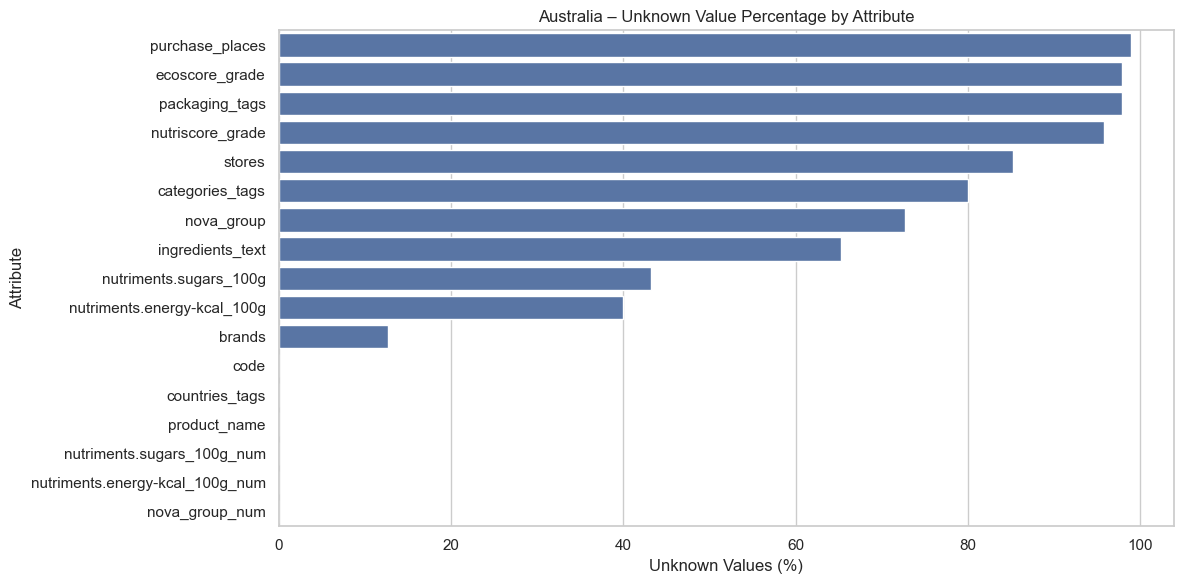

In [73]:
# ============================================================
# AUSTRALIA — UNKNOWN VALUE ANALYSIS
# ============================================================

australia_unknown_summary = []

for col in australia_df.columns:
    unknown_count = (
        australia_df[col].astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    australia_unknown_summary.append({
        "Attribute": col,
        "Unknown_Count": unknown_count,
        "Total_Records": len(australia_df),
        "Unknown_Percentage": round(
            unknown_count / len(australia_df) * 100, 2
        )
    })

australia_unknown_df = pd.DataFrame(australia_unknown_summary).sort_values(
    "Unknown_Percentage", ascending=False
)

display(australia_unknown_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=australia_unknown_df,
            x="Unknown_Percentage", y="Attribute")
plt.title("Australia – Unknown Value Percentage by Attribute")
plt.xlabel("Unknown Values (%)")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

Top 20 Products:


,Product_Name,Frequency
0,Fanta,2
1,Fanta orange,2
2,Lemon,2
3,Fanta zero sugar orange,2
4,Delites,2
5,fantastic rice squares,1
6,Gluten Free Rice Noodles Chicken,1
7,Fantastic Noodles beef bowl,1
8,Honey Baked Ham,1
9,Crinkle Cut Snacks Sweet Chilli & Sour Cream Flavour,1


Total Product Records: 95
Unique Products: 90
Product Uniqueness Rate: 94.74 %


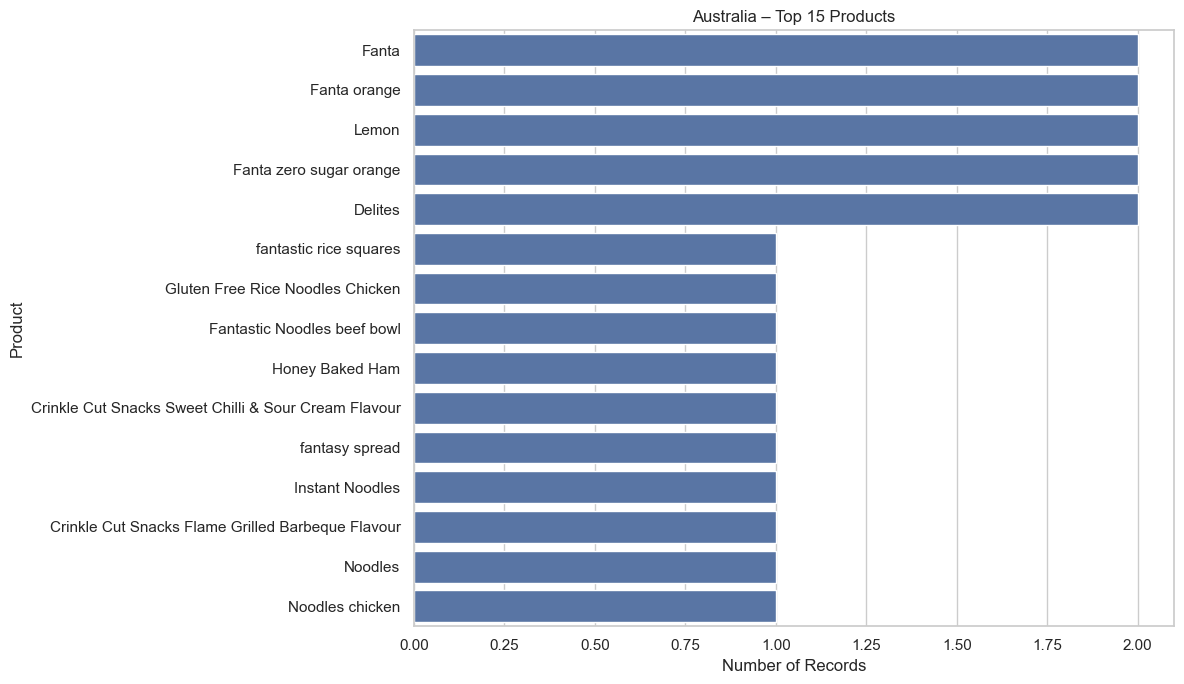

In [74]:
# ============================================================
# AUSTRALIA — PRODUCT ANALYSIS
# ============================================================

australia_product_counts = (
    australia_df["product_name"].value_counts().reset_index()
)
australia_product_counts.columns = ["Product_Name", "Frequency"]

print("Top 20 Products:")
display(australia_product_counts.head(20))

print("Total Product Records:", len(australia_df))
print("Unique Products:", australia_df["product_name"].nunique())
print(
    "Product Uniqueness Rate:",
    round(australia_df["product_name"].nunique() / len(australia_df) * 100, 2),
    "%"
)

plt.figure(figsize=(12, 7))
sns.barplot(data=australia_product_counts.head(15),
            x="Frequency", y="Product_Name")
plt.title("Australia – Top 15 Products")
plt.xlabel("Number of Records")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

Top 20 Brands:


,Brand,Product_Count
0,Fantastic,36
1,Fanta,28
2,Unknown,12
3,Coles,4
4,Coca-Cola,2
5,Bare Bakers,2
6,Dark Fantasy,2
7,"Coles Supermarket, Coles",1
8,Fini,1
9,Nestlé,1


Unique Brands: 16
Brand Diversity Ratio: 16.84 %


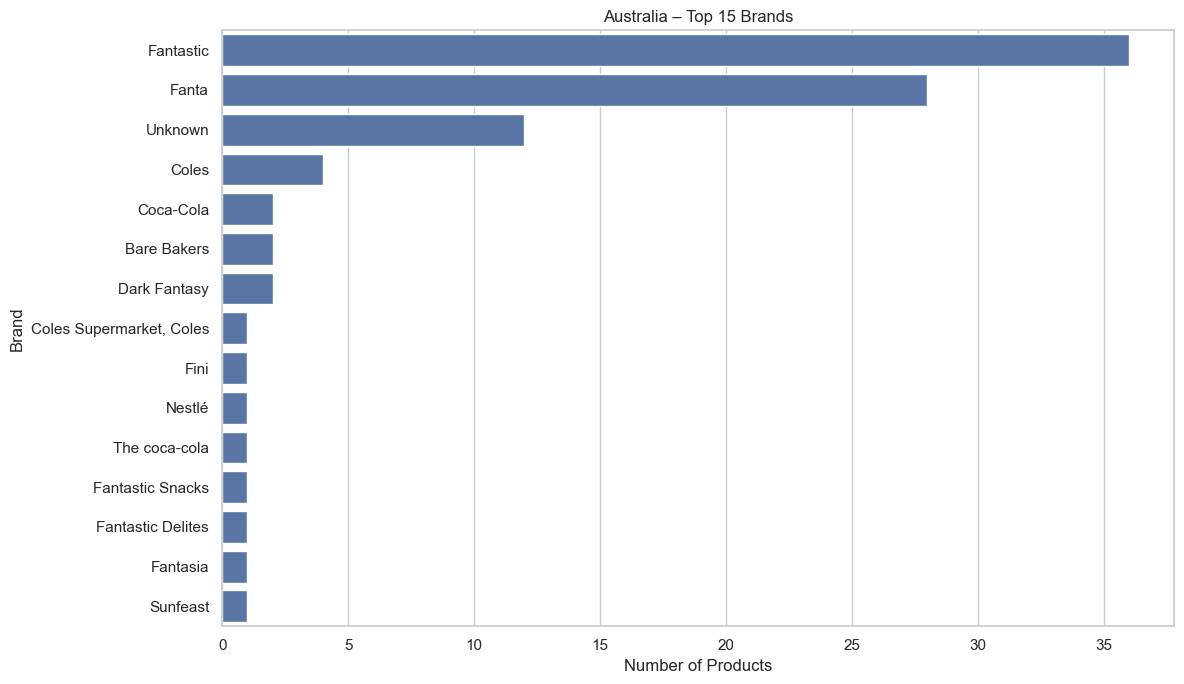

In [75]:
# ============================================================
# AUSTRALIA — BRAND ANALYSIS
# ============================================================

australia_brand_counts = (
    australia_df["brands"].value_counts().reset_index()
)
australia_brand_counts.columns = ["Brand", "Product_Count"]

print("Top 20 Brands:")
display(australia_brand_counts.head(20))

print("Unique Brands:", australia_df["brands"].nunique())

australia_brand_diversity = (
    australia_df["brands"].nunique() / len(australia_df) * 100
)
print("Brand Diversity Ratio:", round(australia_brand_diversity, 2), "%")

plt.figure(figsize=(12, 7))
sns.barplot(data=australia_brand_counts.head(15),
            x="Product_Count", y="Brand")
plt.title("Australia – Top 15 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Top 25 Categories:


categories_tags
plant-based-foods-and-beverages       9
plant-based-foods                     9
pastas                                9
noodles                               9
dried-products                        8
dried-products-to-be-rehydrated       8
instant-noodles                       8
crackers-appetizers                   5
appetizers                            5
salty-snacks                          5
snacks                                5
biscuits-and-crackers                 5
cereals-and-potatoes                  4
cereals-and-their-products            4
beverages                             4
carbonated-drinks                     3
sodas                                 3
breakfasts                            1
spreads                               1
sweet-spreads                         1
cracker-biscuits-with-grains-seeds    1
glut                                  1
Name: count, dtype: int64

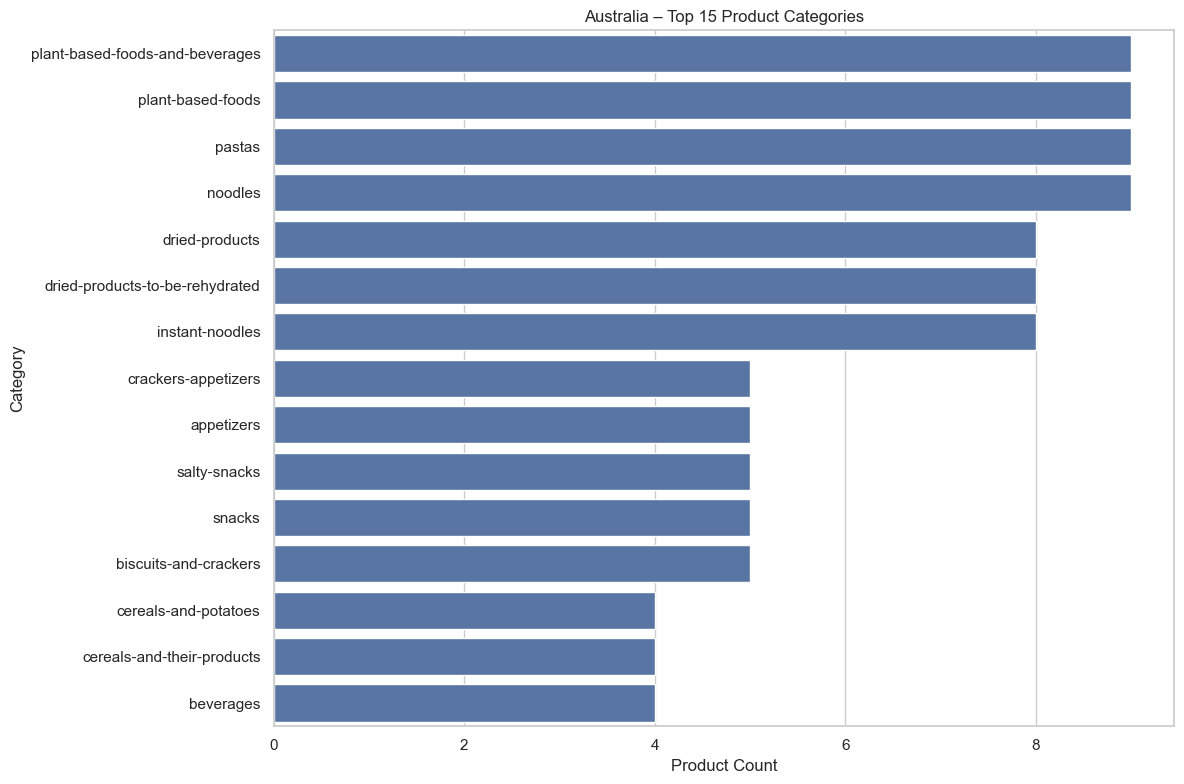

In [76]:
# ============================================================
# AUSTRALIA — CATEGORY ANALYSIS
# ============================================================

australia_category_series = (
    australia_df["categories_tags"].astype(str)
    .str.split(",").explode().str.strip()
)

australia_category_series = australia_category_series[
    australia_category_series.str.lower() != "unknown"
]

australia_category_counts = australia_category_series.value_counts()

print("Top 25 Categories:")
display(australia_category_counts.head(25))

australia_top_categories = australia_category_counts.head(15).reset_index()
australia_top_categories.columns = ["Category", "Product_Count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=australia_top_categories,
            x="Product_Count", y="Category")
plt.title("Australia – Top 15 Product Categories")
plt.xlabel("Product Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# AUSTRALIA — PACKAGING, STORE AND PURCHASE PLACE
# ============================================================

def analyze_multivalue_attribute(country_df, column, label):
    if column not in country_df.columns:
        print(f"Column not found: {column}")
        return pd.Series(dtype="int64")

    s = country_df[column].astype(str).str.split(",").explode().str.strip()
    s = s[s.str.lower() != "unknown"]
    counts = s.value_counts()

    print(f"Top {label}:")
    display(counts.head(20).to_frame("Count"))
    return counts

australia_packaging_counts = analyze_multivalue_attribute(
    australia_df, "packaging_tags", "Packaging Types"
)
australia_store_counts = analyze_multivalue_attribute(
    australia_df, "stores", "Stores"
)
australia_purchase_counts = analyze_multivalue_attribute(
    australia_df, "purchase_places", "Purchase Places"
)

Top Packaging Types:


,Count
packaging_tags,
plastic-bottle,1
glass,1


Top Stores:


,Count
stores,
Woolworths,10
Coles,8
Drakes,2
Coles Supermarket,1
Kmart,1
IGA,1


Top Purchase Places:


,Count
purchase_places,
Australia,1


Nutri-Score Distribution:


nutriscore_grade
unknown    91
d           2
b           1
e           1
Name: count, dtype: int64

Nutri-Score Percentage:


nutriscore_grade
unknown    95.79
d           2.11
b           1.05
e           1.05
Name: proportion, dtype: float64

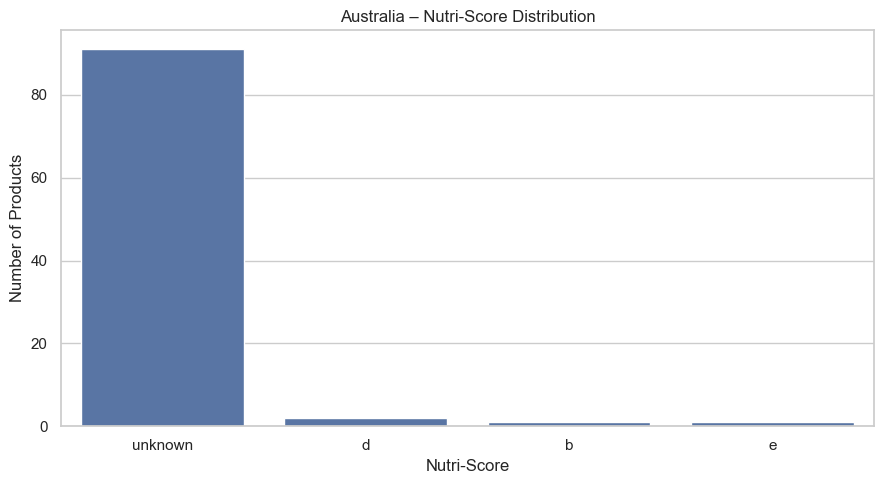

NOVA Group Distribution:


nova_group
Unknown    69
4.0        26
Name: count, dtype: int64

NOVA Group Percentage:


nova_group
Unknown    72.63
4.0        27.37
Name: proportion, dtype: float64

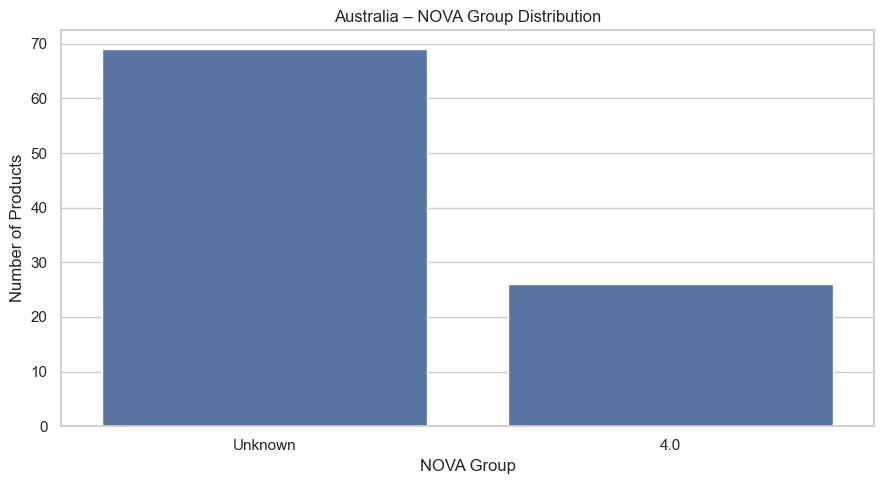

Eco-Score Distribution:


ecoscore_grade
Unknown           64
unknown           29
not-applicable     2
Name: count, dtype: int64

Eco-Score Percentage:


ecoscore_grade
Unknown           67.37
unknown           30.53
not-applicable     2.11
Name: proportion, dtype: float64

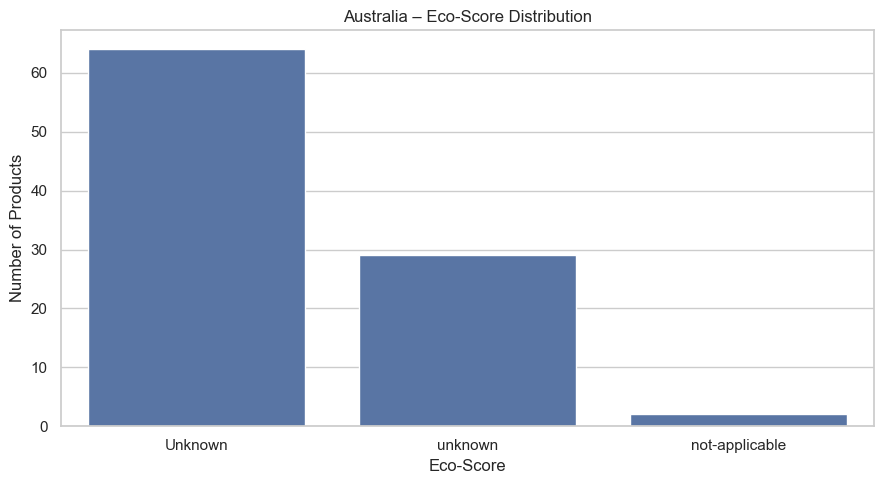

In [78]:
# ============================================================
# AUSTRALIA — NUTRI-SCORE, NOVA AND ECO-SCORE
# ============================================================

for col, label in [
    ("nutriscore_grade", "Nutri-Score"),
    ("nova_group", "NOVA Group"),
    ("ecoscore_grade", "Eco-Score")
]:
    if col in australia_df.columns:
        counts = australia_df[col].value_counts()
        print(f"{label} Distribution:")
        display(counts)
        print(f"{label} Percentage:")
        display(australia_df[col].value_counts(normalize=True).mul(100).round(2))

        plt.figure(figsize=(9, 5))
        sns.countplot(
            data=australia_df,
            x=col,
            order=australia_df[col].value_counts().index
        )
        plt.title(f"Australia – {label} Distribution")
        plt.xlabel(label)
        plt.ylabel("Number of Products")
        plt.tight_layout()
        plt.show()

Sugar Statistics:


count    54.000000
mean     13.615726
std      21.671643
min       0.000000
25%       0.052750
50%       4.200000
75%       8.000000
max      99.900000
Name: nutriments.sugars_100g_num, dtype: float64

Energy Statistics:


count     57.000000
mean     195.468002
std      199.624226
min        0.400000
25%        2.031549
50%       93.100000
75%      402.000000
max      536.000000
Name: nutriments.energy-kcal_100g_num, dtype: float64

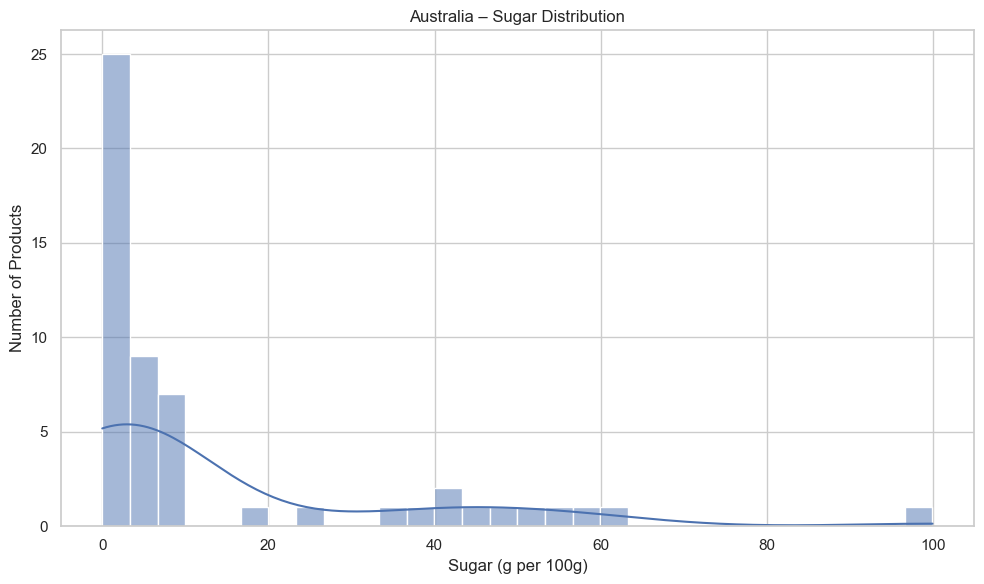

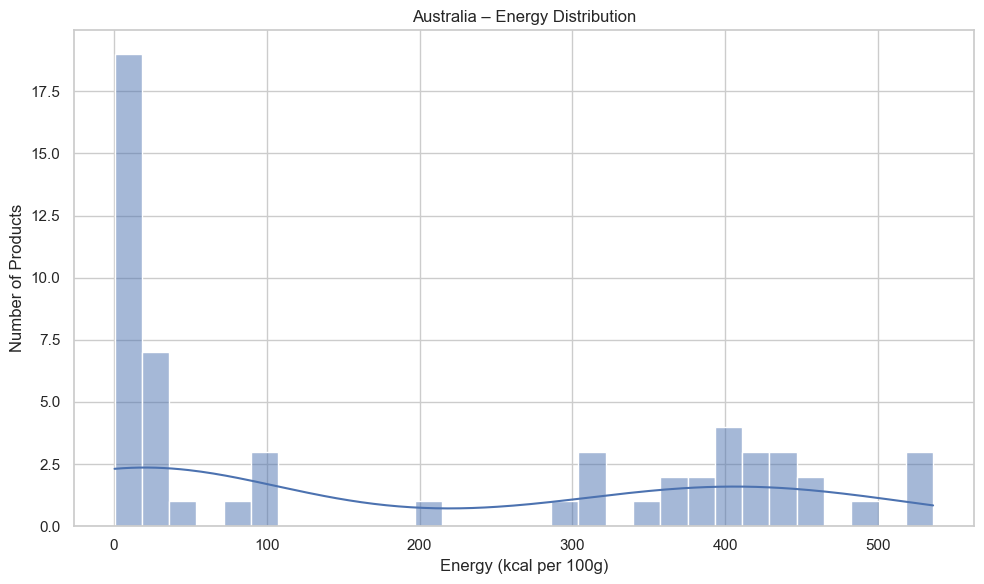

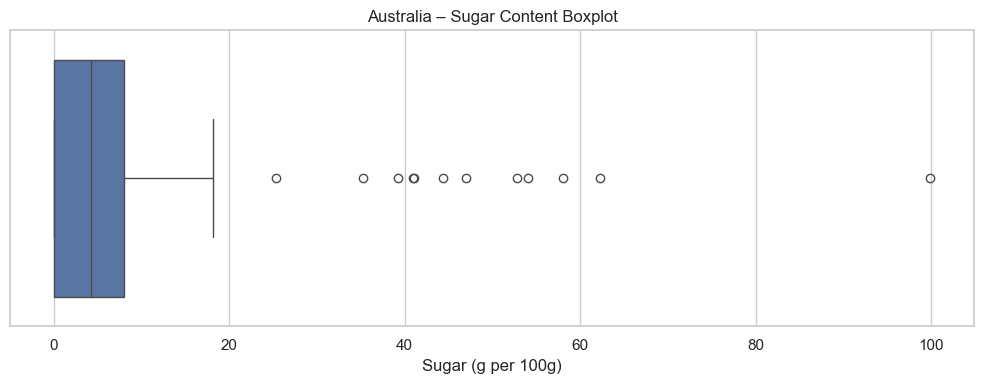

In [79]:
# ============================================================
# AUSTRALIA — SUGAR AND ENERGY
# ============================================================

australia_sugar = australia_df["nutriments.sugars_100g_num"].dropna()
australia_energy = australia_df["nutriments.energy-kcal_100g_num"].dropna()

print("Sugar Statistics:")
display(australia_sugar.describe())

print("Energy Statistics:")
display(australia_energy.describe())

plt.figure(figsize=(10, 6))
sns.histplot(australia_sugar, bins=30, kde=True)
plt.title("Australia – Sugar Distribution")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(australia_energy, bins=30, kde=True)
plt.title("Australia – Energy Distribution")
plt.xlabel("Energy (kcal per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=australia_sugar)
plt.title("Australia – Sugar Content Boxplot")
plt.xlabel("Sugar (g per 100g)")
plt.tight_layout()
plt.show()

Valid nutritional records: 50
Sugar–Energy Correlation: 0.473


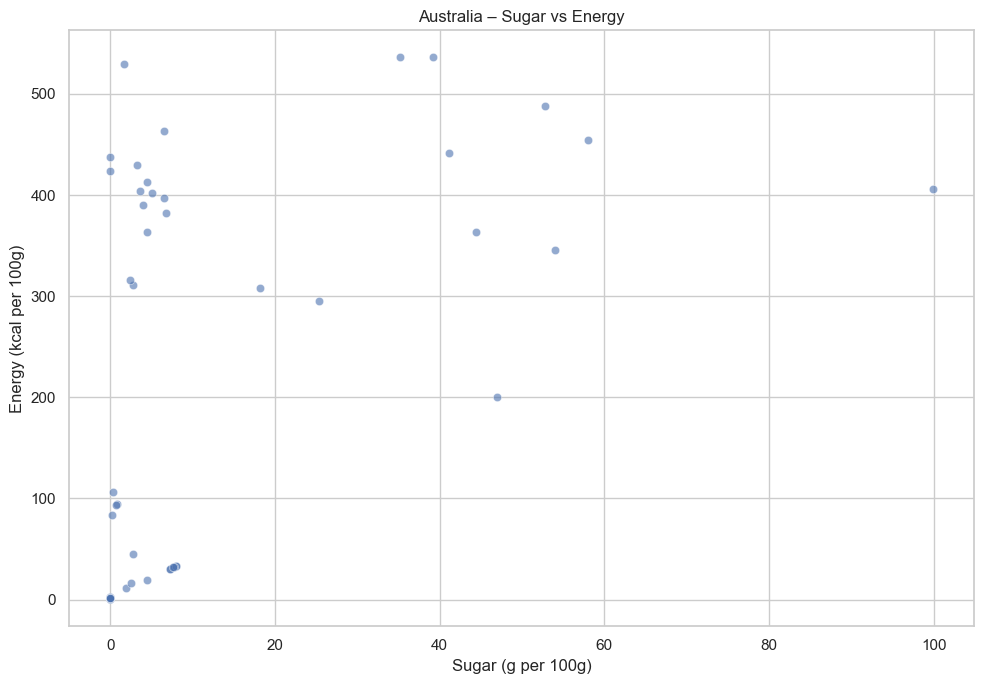

In [80]:
# ============================================================
# AUSTRALIA — SUGAR VS ENERGY
# ============================================================

australia_nutrition = australia_df[
    ["nutriments.sugars_100g_num", "nutriments.energy-kcal_100g_num"]
].dropna()

australia_sugar_energy_corr = (
    australia_nutrition["nutriments.sugars_100g_num"]
    .corr(australia_nutrition["nutriments.energy-kcal_100g_num"])
)

print("Valid nutritional records:", len(australia_nutrition))
print("Sugar–Energy Correlation:", round(australia_sugar_energy_corr, 3))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=australia_nutrition,
    x="nutriments.sugars_100g_num",
    y="nutriments.energy-kcal_100g_num",
    alpha=0.6
)
plt.title("Australia – Sugar vs Energy")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Energy (kcal per 100g)")
plt.tight_layout()
plt.show()

In [81]:
# ============================================================
# AUSTRALIA — OUTLIER ANALYSIS
# ============================================================

def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

australia_sugar_outliers = find_outliers(australia_sugar)
australia_energy_outliers = find_outliers(australia_energy)

print("Sugar Outliers:", len(australia_sugar_outliers))
print("Energy Outliers:", len(australia_energy_outliers))

print("\nHighest Sugar Products:")
display(
    australia_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.sugars_100g_num"]
    ].dropna(subset=["nutriments.sugars_100g_num"])
     .sort_values("nutriments.sugars_100g_num", ascending=False)
     .head(20)
)

print("\nHighest Energy Products:")
display(
    australia_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.energy-kcal_100g_num"]
    ].dropna(subset=["nutriments.energy-kcal_100g_num"])
     .sort_values("nutriments.energy-kcal_100g_num", ascending=False)
     .head(20)
)

Sugar Outliers: 12
Energy Outliers: 0

Highest Sugar Products:


,product_name,brands,categories_tags,nutriments.sugars_100g_num
950,Fairy Floss,Fantasy,Unknown,99.9
93,fantasy spread,"Coles Supermarket, Coles","breakfasts, spreads, sweet-spreads",62.3
477,Fantales,Unknown,Unknown,58.0
353,Fantasy belts,Fini,Unknown,54.0
885,Hazelnu5 Creme Wafer Rolls,Dark Fantasy,Unknown,52.8
277,Fanta Tropical,Unknown,Unknown,47.0
210,Fantales Family Size,Nestlé,Unknown,44.4
608,Fantastically Fudgey Choc Brownie,Bare Bakers,Unknown,41.1
597,Fantastically Fudgy Choc Brownie,Bare Bakers,Unknown,41.0
909,Chocolate Meltz,Dark Fantasy,Unknown,39.2



Highest Energy Products:


,product_name,brands,categories_tags,nutriments.energy-kcal_100g_num
909,Chocolate Meltz,Dark Fantasy,Unknown,536.00000
919,Dark Fantasy (Choco-Style Nut Fills),Sunfeast,Unknown,536.00000
431,Fantastic Flaxseed with Chia + Almond,Unknown,Unknown,530.00000
885,Hazelnu5 Creme Wafer Rolls,Dark Fantasy,Unknown,488.00000
478,Delite curls,Fantastic,Unknown,463.75000
477,Fantales,Unknown,Unknown,454.11090
608,Fantastically Fudgey Choc Brownie,Bare Bakers,Unknown,442.00000
452,ThinnerBite black rice crackers,Fantastic,Unknown,437.40000
617,"Tomatoe, Red Onion & Balsamic Rice Crackers",Fantastic,Unknown,430.00000
201,Fantasy cupcjes,Coles,Unknown,426.00000


In [82]:
# ============================================================
# AUSTRALIA — BRAND NUTRITION ANALYSIS
# ============================================================

australia_brand_nutrition = (
    australia_df.groupby("brands")
    .agg(
        Product_Count=("product_name", "count"),
        Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
        Median_Sugar=("nutriments.sugars_100g_num", "median"),
        Avg_Energy=("nutriments.energy-kcal_100g_num", "mean"),
        Median_Energy=("nutriments.energy-kcal_100g_num", "median")
    )
    .reset_index()
)

australia_brand_nutrition = (
    australia_brand_nutrition[
        australia_brand_nutrition["Product_Count"] >= 3
    ]
    .sort_values("Product_Count", ascending=False)
)

display(australia_brand_nutrition.head(20))

,brands,Product_Count,Avg_Sugar,Median_Sugar,Avg_Energy,Median_Energy
7,Fantastic,36,3.056977,2.800000,289.084747,386.20000
5,Fanta,28,3.046667,0.000000,10.385927,1.12000
15,Unknown,12,21.333333,1.666667,296.127725,327.05545
2,Coles,4,15.333333,18.200000,261.422298,301.50000


Sugar by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,
e,1,6.20,6.2,6.2,6.2
unknown,53,13.76,4.0,0.0,99.9


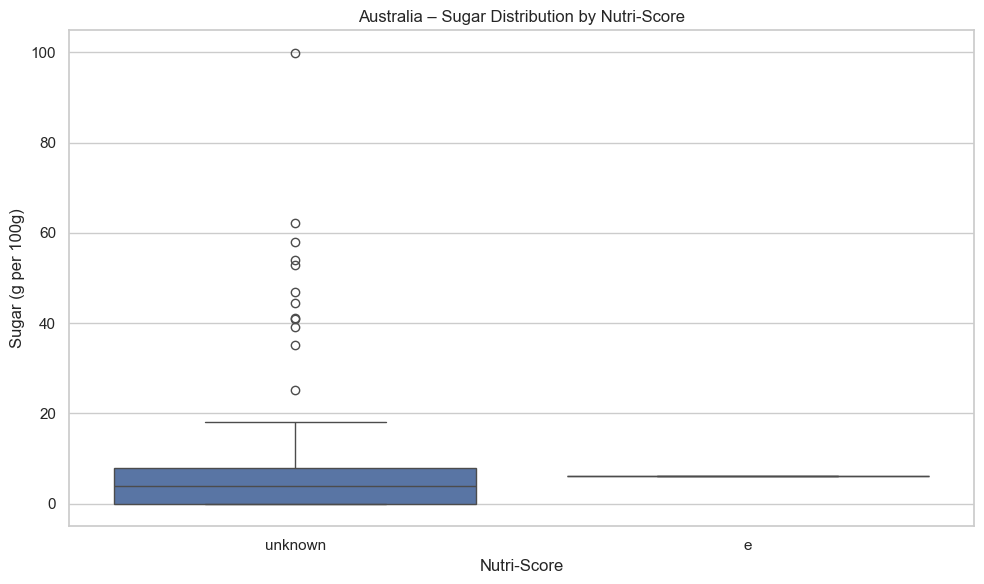

Energy by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,
unknown,57,195.47,93.1,0.4,536.0


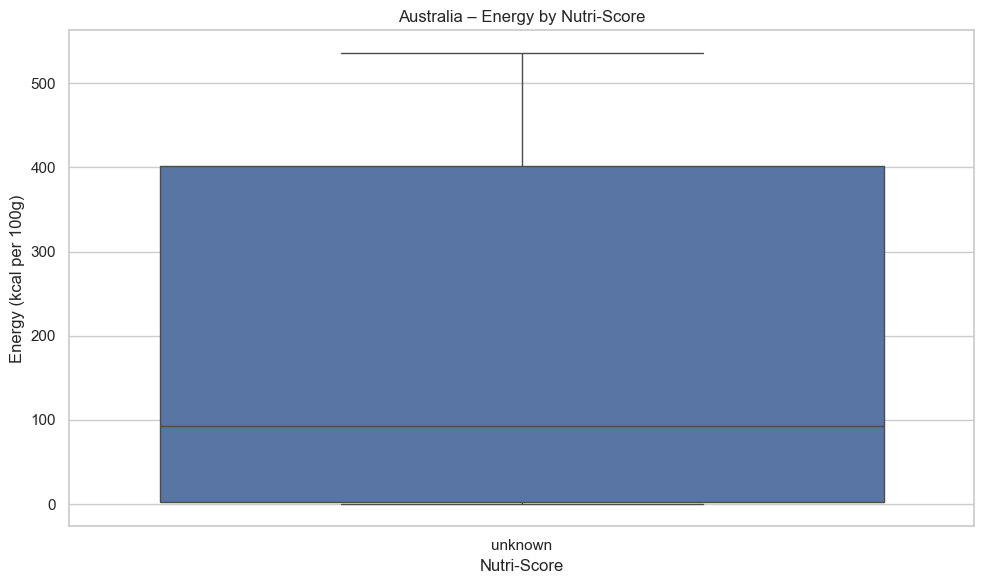

In [83]:
# ============================================================
# AUSTRALIA — NUTRI-SCORE VS SUGAR / ENERGY
# ============================================================

if "nutriscore_grade" in australia_df.columns:

    australia_nutri_sugar = australia_df[
        ["nutriscore_grade", "nutriments.sugars_100g_num"]
    ].dropna()

    print("Sugar by Nutri-Score:")
    display(
        australia_nutri_sugar.groupby("nutriscore_grade")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=australia_nutri_sugar,
        x="nutriscore_grade",
        y="nutriments.sugars_100g_num"
    )
    plt.title("Australia – Sugar Distribution by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

    australia_nutri_energy = australia_df[
        ["nutriscore_grade", "nutriments.energy-kcal_100g_num"]
    ].dropna()

    print("Energy by Nutri-Score:")
    display(
        australia_nutri_energy.groupby("nutriscore_grade")
        ["nutriments.energy-kcal_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=australia_nutri_energy,
        x="nutriscore_grade",
        y="nutriments.energy-kcal_100g_num"
    )
    plt.title("Australia – Energy by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Energy (kcal per 100g)")
    plt.tight_layout()
    plt.show()

,count,mean,median,min,max
nova_group,,,,,
4.0,7,16.98,6.2,0.71,54.0
Unknown,47,13.11,4.0,0.00,99.9


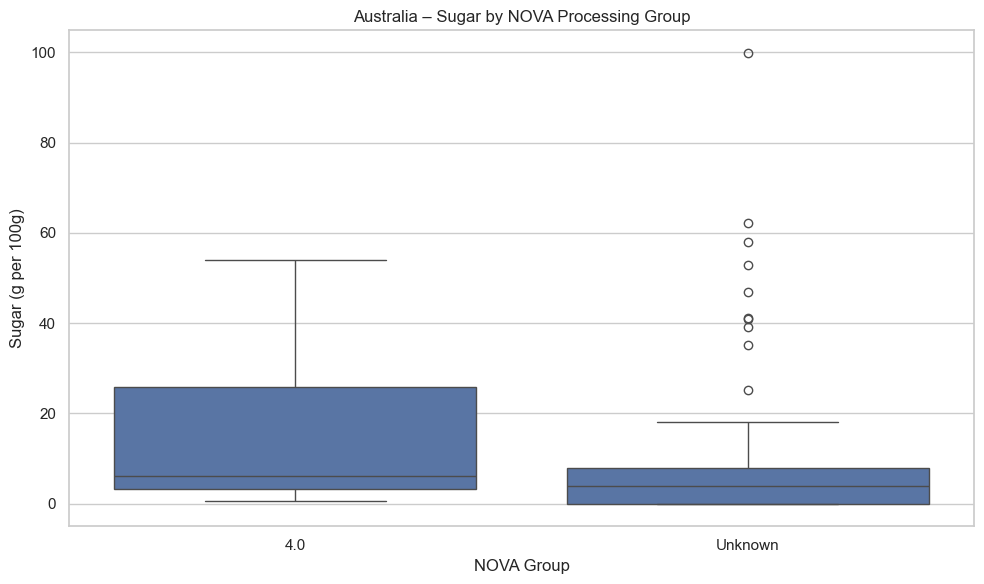

In [84]:
# ============================================================
# AUSTRALIA — NOVA VS SUGAR
# ============================================================

if "nova_group" in australia_df.columns:

    australia_nova_sugar = australia_df[
        ["nova_group", "nutriments.sugars_100g_num"]
    ].dropna()

    display(
        australia_nova_sugar.groupby("nova_group")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=australia_nova_sugar,
        x="nova_group",
        y="nutriments.sugars_100g_num"
    )
    plt.title("Australia – Sugar by NOVA Processing Group")
    plt.xlabel("NOVA Group")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

,nova_group_num,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num
nova_group_num,NaN,NaN,NaN
nutriments.sugars_100g_num,NaN,1.000,0.473
nutriments.energy-kcal_100g_num,NaN,0.473,1.000


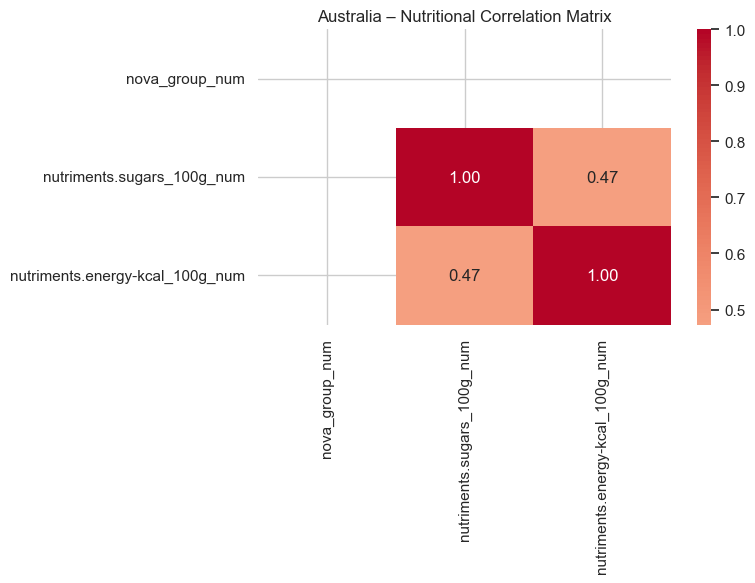

In [85]:
# ============================================================
# AUSTRALIA — CORRELATION
# ============================================================

corr_cols = [
    "nova_group_num",
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

available_corr_cols = [c for c in corr_cols if c in australia_df.columns]

australia_corr = australia_df[available_corr_cols].corr()

display(australia_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    australia_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Australia – Nutritional Correlation Matrix")
plt.tight_layout()
plt.show()

,Ingredient,Frequency
0,sugar,21
1,salt,20
2,maltodextrin,11
3,flavour,11
4,food acids (330,8
5,331),8
6,preservative (202),7
7,carbonated water,6
8,yeast extract,5
9,vegetable oil,5


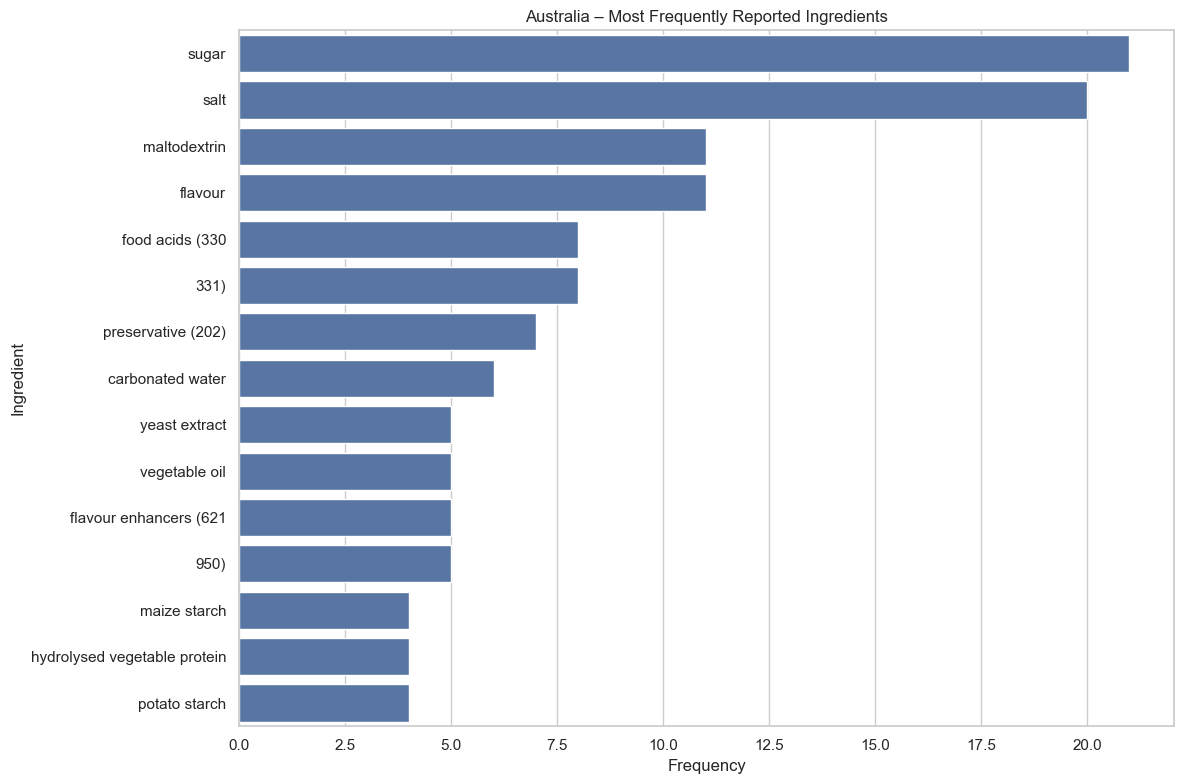

In [86]:
# ============================================================
# AUSTRALIA — INGREDIENT ANALYSIS
# ============================================================

if "ingredients_text" in australia_df.columns:

    ingredient_text = australia_df["ingredients_text"].astype(str).str.lower()
    all_ingredients = []

    for text in ingredient_text:
        if text != "unknown":
            for ingredient in text.split(","):
                ingredient = ingredient.strip()
                if ingredient and ingredient != "unknown":
                    all_ingredients.append(ingredient)

    australia_ingredient_counts = Counter(all_ingredients)

    australia_ingredient_df = pd.DataFrame(
        australia_ingredient_counts.most_common(30),
        columns=["Ingredient", "Frequency"]
    )

    display(australia_ingredient_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=australia_ingredient_df.head(15),
        x="Frequency",
        y="Ingredient"
    )
    plt.title("Australia – Most Frequently Reported Ingredients")
    plt.xlabel("Frequency")
    plt.ylabel("Ingredient")
    plt.tight_layout()
    plt.show()

In [87]:
# ============================================================
# AUSTRALIA — CATEGORY VS NUTRITION
# ============================================================

if "categories_tags" in australia_df.columns:

    australia_category_nutrition = (
        australia_df.groupby("categories_tags")
        .agg(
            Product_Count=("product_name", "count"),
            Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
            Avg_Energy=("nutriments.energy-kcal_100g_num", "mean")
        )
        .reset_index()
    )

    australia_category_nutrition = (
        australia_category_nutrition[
            australia_category_nutrition["Product_Count"] >= 2
        ]
        .sort_values("Product_Count", ascending=False)
    )

    display(australia_category_nutrition.head(20))

,categories_tags,Product_Count,Avg_Sugar,Avg_Energy
0,Unknown,76,14.142754,211.294130
7,"plant-based-foods-and-beverages, plant-based-foods, dried-products, pastas, dried-products-to-be-rehydrated, noodles...",5,1.120641,79.068863
2,"beverages, carbonated-drinks, sodas",3,4.500000,19.000000
8,"snacks, salty-snacks, appetizers, biscuits-and-crackers, crackers-appetizers",3,NaN,NaN
4,"plant-based-foods-and-beverages, plant-based-foods, cereals-and-potatoes, cereals-and-their-products, dried-products...",2,NaN,NaN


In [88]:
# ============================================================
# AUSTRALIA — ATTRIBUTE-LEVEL ANALYSIS
# ============================================================

categorical_columns = [
    "brands",
    "categories_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "nutriscore_grade",
    "nova_group",
    "ecoscore_grade"
]

for col in categorical_columns:
    if col in australia_df.columns:
        print("\n" + "=" * 70)
        print(f"ATTRIBUTE: {col}")
        print("=" * 70)

        counts = (
            australia_df[col]
            .astype(str)
            .value_counts()
            .head(15)
        )

        display(counts.to_frame("Count"))


ATTRIBUTE: brands


,Count
brands,
Fantastic,36
Fanta,28
Unknown,12
Coles,4
Coca-Cola,2
Bare Bakers,2
Dark Fantasy,2
"Coles Supermarket, Coles",1
Fini,1



ATTRIBUTE: categories_tags


,Count
categories_tags,
Unknown,76
"plant-based-foods-and-beverages, plant-based-foods, dried-products, pastas, dried-products-to-be-rehydrated, noodles, instant-noodles",5
"snacks, salty-snacks, appetizers, biscuits-and-crackers, crackers-appetizers",3
"beverages, carbonated-drinks, sodas",3
"plant-based-foods-and-beverages, plant-based-foods, cereals-and-potatoes, cereals-and-their-products, dried-products, dried-products-to-be-rehydrated, pastas, noodles, instant-noodles",2
"breakfasts, spreads, sweet-spreads",1
"plant-based-foods-and-beverages, plant-based-foods, cereals-and-potatoes, cereals-and-their-products, dried-products, pastas, dried-products-to-be-rehydrated, noodles, instant-noodles",1
"plant-based-foods-and-beverages, plant-based-foods, cereals-and-potatoes, cereals-and-their-products, pastas, noodles",1
beverages,1



ATTRIBUTE: packaging_tags


...

,Count
nutriscore_grade,
unknown,91
d,2
b,1
e,1



ATTRIBUTE: nova_group


,Count
nova_group,
Unknown,69
4.0,26



ATTRIBUTE: ecoscore_grade


,Count
ecoscore_grade,
Unknown,64
unknown,29
not-applicable,2


In [89]:
# ============================================================
# AUSTRALIA — NUMERICAL ATTRIBUTE ANALYSIS
# ============================================================

numerical_columns = [
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

australia_numeric_summary = []

for col in numerical_columns:
    if col in australia_df.columns:
        australia_numeric_summary.append({
            "Attribute": col,
            "Count": australia_df[col].count(),
            "Mean": australia_df[col].mean(),
            "Median": australia_df[col].median(),
            "Std": australia_df[col].std(),
            "Minimum": australia_df[col].min(),
            "Maximum": australia_df[col].max()
        })

australia_numeric_summary = pd.DataFrame(australia_numeric_summary)
display(australia_numeric_summary.round(2))

,Attribute,Count,Mean,Median,Std,Minimum,Maximum
0,nutriments.sugars_100g_num,54,13.62,4.2,21.67,0.0,99.9
1,nutriments.energy-kcal_100g_num,57,195.47,93.1,199.62,0.4,536.0


In [90]:
# ============================================================
# AUSTRALIA — DATA QUALITY CHECK
# ============================================================

print("AUSTRALIA DATA QUALITY CHECK")
print("=" * 60)

print("Duplicate Rows:", australia_df.duplicated().sum())
print("Duplicate Product Names:", australia_df["product_name"].duplicated().sum())
print("Unique Products:", australia_df["product_name"].nunique())
print("Unique Brands:", australia_df["brands"].nunique())
print("Records:", len(australia_df))

AUSTRALIA DATA QUALITY CHECK
Duplicate Rows: 0
Duplicate Product Names: 5
Unique Products: 90
Unique Brands: 16
Records: 95


In [91]:
# ============================================================
# AUSTRALIA — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("🌍 AUSTRALIA – ADVANCED DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nTotal Records: {len(australia_df):,}")
print(f"Unique Products: {australia_df['product_name'].nunique():,}")
print(f"Unique Brands: {australia_df['brands'].nunique():,}")

print("\nTop 5 Brands:")
display(australia_brand_counts.head(5))

print("\nTop 5 Categories:")
display(australia_category_counts.head(5))

print("\nTop Packaging Types:")
display(australia_packaging_counts.head(5))

print("\nTop Stores:")
display(australia_store_counts.head(5))

print("\nTop Purchase Places:")
display(australia_purchase_counts.head(5))

if "nutriscore_grade" in australia_df.columns:
    print("\nNutri-Score Distribution:")
    display(australia_df["nutriscore_grade"].value_counts())

if "nova_group" in australia_df.columns:
    print("\nNOVA Distribution:")
    display(australia_df["nova_group"].value_counts())

if "ecoscore_grade" in australia_df.columns:
    print("\nEco-Score Distribution:")
    display(australia_df["ecoscore_grade"].value_counts())

print("\nNutritional Statistics:")
display(pd.DataFrame({
    "Metric": [
        "Average Sugar", "Median Sugar", "Maximum Sugar",
        "Average Energy", "Median Energy", "Maximum Energy"
    ],
    "Value": [
        australia_sugar.mean(), australia_sugar.median(), australia_sugar.max(),
        australia_energy.mean(), australia_energy.median(), australia_energy.max()
    ]
}).round(2))

print("\nSugar–Energy Correlation:", round(australia_sugar_energy_corr, 3))
print("\nAnalysis completed for Australia.")

🌍 AUSTRALIA – ADVANCED DATA ANALYSIS SUMMARY

Total Records: 95
Unique Products: 90
Unique Brands: 16

Top 5 Brands:


,Brand,Product_Count
0,Fantastic,36
1,Fanta,28
2,Unknown,12
3,Coles,4
4,Coca-Cola,2



Top 5 Categories:


categories_tags
plant-based-foods-and-beverages    9
plant-based-foods                  9
pastas                             9
noodles                            9
dried-products                     8
Name: count, dtype: int64


Top Packaging Types:


...


Eco-Score Distribution:


ecoscore_grade
Unknown           64
unknown           29
not-applicable     2
Name: count, dtype: int64


Nutritional Statistics:


,Metric,Value
0,Average Sugar,13.62
1,Median Sugar,4.20
2,Maximum Sugar,99.90
3,Average Energy,195.47
4,Median Energy,93.10
5,Maximum Energy,536.00



Sugar–Energy Correlation: 0.473

Analysis completed for Australia.


# 🇷🇴 PART — ROMANIA

The same complete analysis framework is applied to **Romania only**.

In [92]:
# ============================================================
# ROMANIA DATASET
# ============================================================

romania_df = df[
    df["countries_tags"].astype(str).str.lower() == "romania"
].copy()

print("ROMANIA DATASET")
print("=" * 60)
print("Records:", len(romania_df))
print("Attributes:", len(romania_df.columns))
display(romania_df.head())

ROMANIA DATASET
Records: 71
Attributes: 17


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num,nova_group_num
8,5449000029973,Fanta lămâie,Fanta,"plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, ...",romania,Unknown,Unknown,Unknown,unknown,4.0,not-applicable,"apă, zahăr, dioxid de carbon, suc de lămâie din concentrat (2%), acidifiant acid citric, stabilizatori: gumă arabică...",11.1,Unknown,11.1,NaN,4.0
16,5449000665829,Fanta Portocale și fructul pasiunii,Fanta,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",romania,"plastic, pet-polyethylene-terephthalate",Unknown,"Constanta,Romania",d,4.0,not-applicable,"Apa, sirop de fructoza-glucoza, dioxid de carbon, suc de fructe concentrat (portocale 2,8%, fructul pasiunii 0,1%, l...",6.5,Unknown,6.5,NaN,4.0
28,5449000280282,Fanta Dark Orange,Fanta,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",romania,"plastic, pet-polyethylene-terephthalate",Unknown,Romania,d,4.0,not-applicable,"apă, zahăr, suc de fructe din concentrat (portocale 2%, portocale roșii 1%), dioxid de carbon, acidifianți: acid cit...",4.3,19.0,4.3,19.0,4.0
40,5449000021670,Fanta zero zahăr portocale,"Fanta, Coca-Cola, Coca-Cola Company","plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, artific...",romania,"plastic, pet-polyethylene-terephthalate",Unknown,Romania,c,4.0,not-applicable,"Apă, suc de portocale din concentrat 3%, dioxid de carbon, acidifianți: acid citric și acid malic, îndulcitori: cicl...",0.3,2.0,0.3,2.0,4.0
41,5449000270320,"Fanta zero zahăr cu zmeură, lămâie verde și baobab","Fanta, Coca-Cola, Coca-Cola Company","beverages, carbonated-drinks, artificially-sweetened-beverages, sodas, sweetened-beverages",romania,"plastic, pet-polyethylene-terephthalate",Unknown,Romania,c,4.0,not-applicable,"Apă, dioxid de carbon, suc de fructe din concentrat: suc de portocale (2,9%), suc de lămâie verde (0,1%), suc de zme...",0.4,3.0,0.4,3.0,4.0


In [93]:
# ============================================================
# ROMANIA — BASIC OVERVIEW
# ============================================================

print("Dataset Shape:", romania_df.shape)
print("\nColumn Names:")
print(romania_df.columns.tolist())

print("\nData Types:")
display(romania_df.dtypes)

print("\nStatistical Summary:")
display(romania_df.describe(include="all").T)

Dataset Shape: (71, 17)

Column Names:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g', 'nutriments.sugars_100g_num', 'nutriments.energy-kcal_100g_num', 'nova_group_num']

Data Types:


code                                object
product_name                        object
brands                              object
categories_tags                     object
countries_tags                      object
packaging_tags                      object
stores                              object
purchase_places                     object
nutriscore_grade                    object
nova_group                          object
ecoscore_grade                      object
ingredients_text                    object
nutriments.sugars_100g              object
nutriments.energy-kcal_100g         object
nutriments.sugars_100g_num         float64
nutriments.energy-kcal_100g_num    float64
nova_group_num                     float64
dtype: object


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,71,71,5449000029973,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,71,65,fanta,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brands,71,11,Fanta,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories_tags,71,27,Unknown,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countries_tags,71,1,romania,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packaging_tags,71,6,Unknown,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stores,71,2,Unknown,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_places,71,4,Unknown,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutriscore_grade,71,5,unknown,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nova_group,71,2,Unknown,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Attribute,Unknown_Count,Total_Records,Unknown_Percentage
6,stores,70,71,98.59
7,purchase_places,66,71,92.96
10,ecoscore_grade,58,71,81.69
5,packaging_tags,55,71,77.46
13,nutriments.energy-kcal_100g,53,71,74.65
12,nutriments.sugars_100g,52,71,73.24
9,nova_group,50,71,70.42
11,ingredients_text,47,71,66.20
8,nutriscore_grade,46,71,64.79
3,categories_tags,34,71,47.89


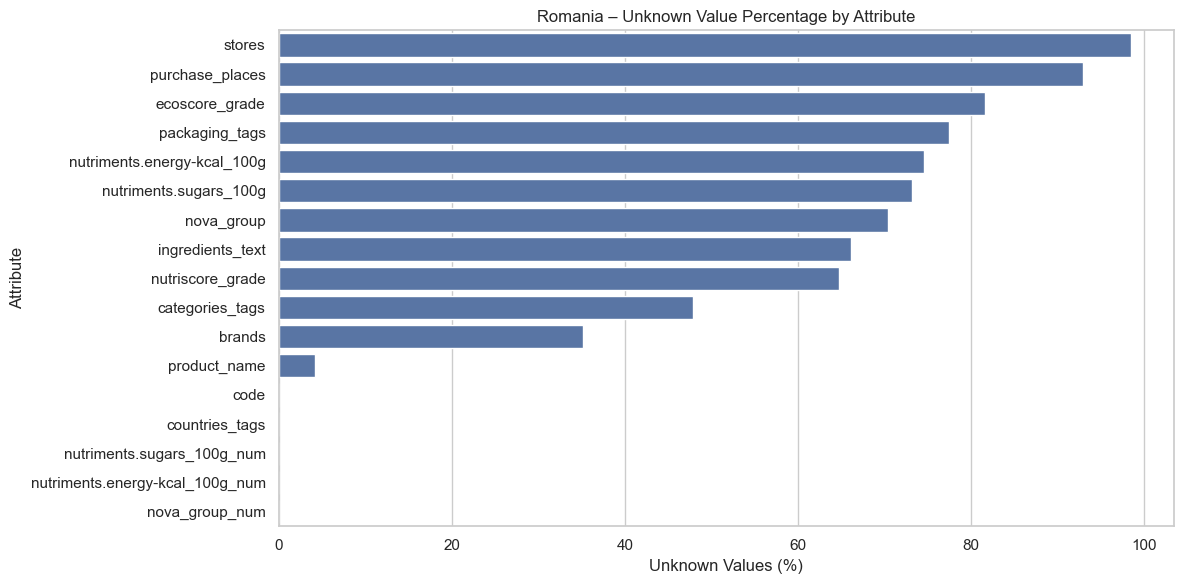

In [94]:
# ============================================================
# ROMANIA — UNKNOWN VALUE ANALYSIS
# ============================================================

romania_unknown_summary = []

for col in romania_df.columns:
    unknown_count = (
        romania_df[col].astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    romania_unknown_summary.append({
        "Attribute": col,
        "Unknown_Count": unknown_count,
        "Total_Records": len(romania_df),
        "Unknown_Percentage": round(
            unknown_count / len(romania_df) * 100, 2
        )
    })

romania_unknown_df = pd.DataFrame(romania_unknown_summary).sort_values(
    "Unknown_Percentage", ascending=False
)

display(romania_unknown_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=romania_unknown_df,
            x="Unknown_Percentage", y="Attribute")
plt.title("Romania – Unknown Value Percentage by Attribute")
plt.xlabel("Unknown Values (%)")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

Top 20 Products:


,Product_Name,Frequency
0,fanta,3
1,Unknown,3
2,Fanta Madness,2
3,fanta 1l,2
4,Fanta lămâie,1
5,Raison,1
6,Fanta Dark Orange,1
7,Fanta zero zahăr portocale,1
8,Fanta Portocale și fructul pasiunii,1
9,Fanta Zero Zahăr Portocale 2L,1


Total Product Records: 71
Unique Products: 65
Product Uniqueness Rate: 91.55 %


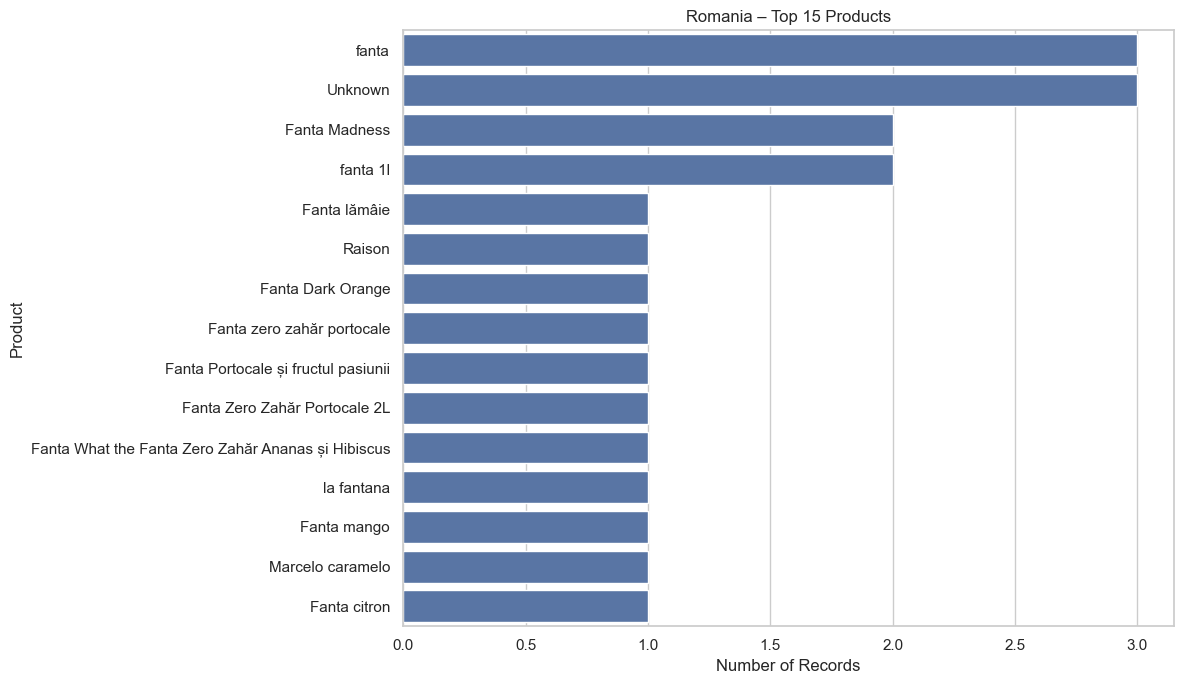

In [95]:
# ============================================================
# ROMANIA — PRODUCT ANALYSIS
# ============================================================

romania_product_counts = (
    romania_df["product_name"].value_counts().reset_index()
)
romania_product_counts.columns = ["Product_Name", "Frequency"]

print("Top 20 Products:")
display(romania_product_counts.head(20))

print("Total Product Records:", len(romania_df))
print("Unique Products:", romania_df["product_name"].nunique())
print(
    "Product Uniqueness Rate:",
    round(romania_df["product_name"].nunique() / len(romania_df) * 100, 2),
    "%"
)

plt.figure(figsize=(12, 7))
sns.barplot(data=romania_product_counts.head(15),
            x="Frequency", y="Product_Name")
plt.title("Romania – Top 15 Products")
plt.xlabel("Number of Records")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

Top 20 Brands:


,Brand,Product_Count
0,Fanta,25
1,Unknown,25
2,Coca Cola,10
3,"Fanta, Coca-Cola, Coca-Cola Company",2
4,Coca-Cola,2
5,coca cola,2
6,día de fantasía,1
7,fantail,1
8,"Fanta, Cadia, Coca-Cola, Coca-Cola Company",1
9,"Fanta, Coca-Cola",1


Unique Brands: 11
Brand Diversity Ratio: 15.49 %


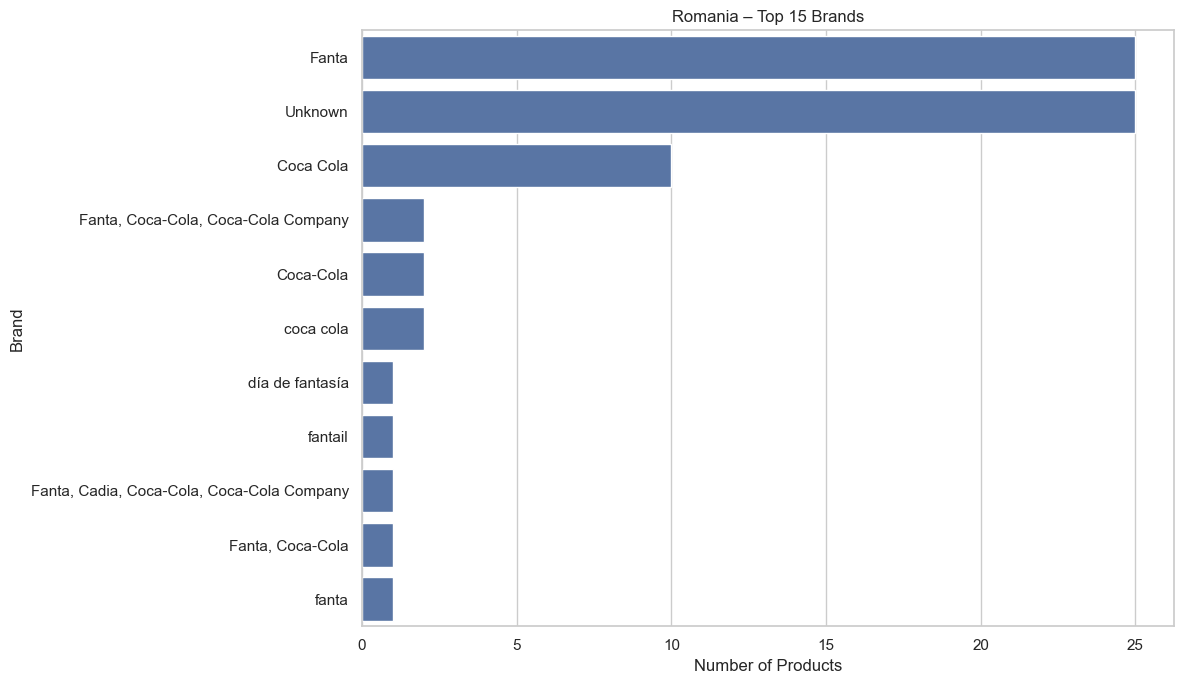

In [96]:
# ============================================================
# ROMANIA — BRAND ANALYSIS
# ============================================================

romania_brand_counts = (
    romania_df["brands"].value_counts().reset_index()
)
romania_brand_counts.columns = ["Brand", "Product_Count"]

print("Top 20 Brands:")
display(romania_brand_counts.head(20))

print("Unique Brands:", romania_df["brands"].nunique())

romania_brand_diversity = (
    romania_df["brands"].nunique() / len(romania_df) * 100
)
print("Brand Diversity Ratio:", round(romania_brand_diversity, 2), "%")

plt.figure(figsize=(12, 7))
sns.barplot(data=romania_brand_counts.head(15),
            x="Product_Count", y="Brand")
plt.title("Romania – Top 15 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Top 25 Categories:


categories_tags
beverages                               34
carbonated-drinks                       30
sodas                                   28
beverages-and-beverages-preparations    23
plant-based-foods-and-beverages         12
plant-based-beverages                   12
fruit-based-beverages                   11
sweetened-beverages                     11
fruit-sodas                              9
artificially-sweetened-beverages         9
diet-beverages                           2
orange-soft-drinks                       2
diet-sodas                               2
Soft Drinks                              2
snacks                                   1
ro:suc                                   1
ro:fanta-mango                           1
gummi-candies                            1
candies                                  1
confectioneries                          1
sweet-snacks                             1
ro:Suc-de-portocale                      1
ro:suc de portocale                   

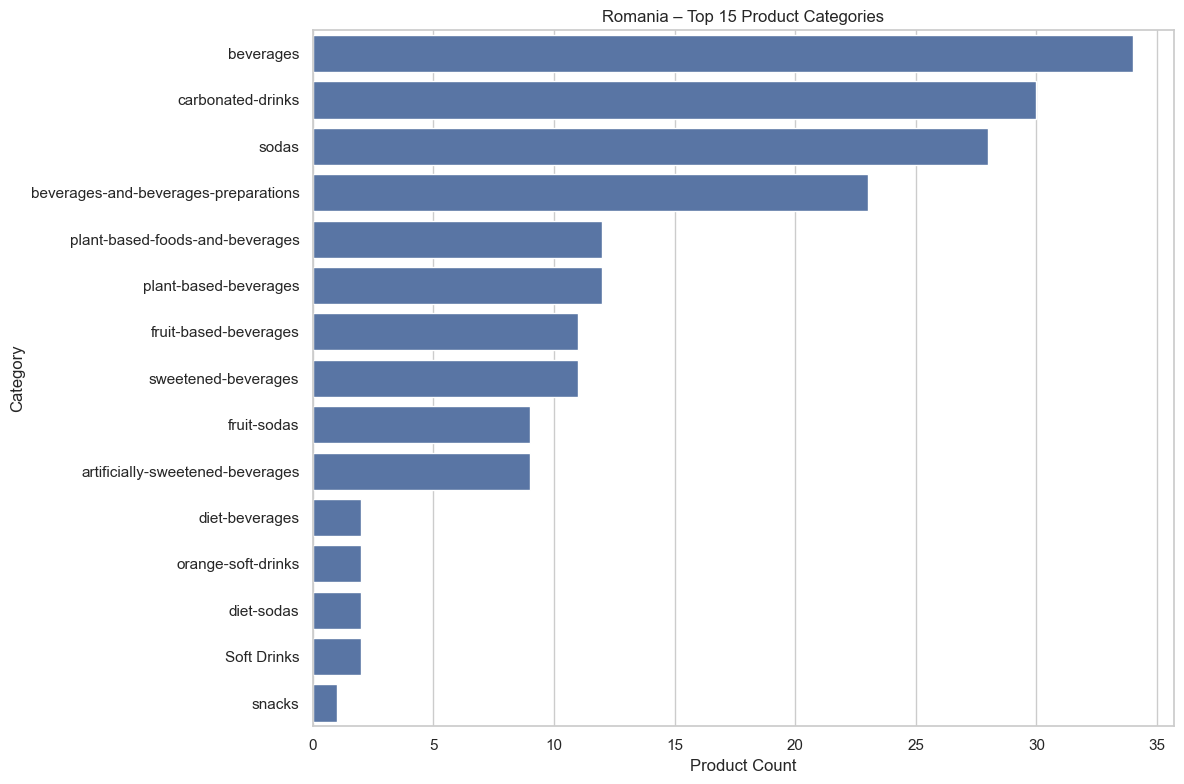

In [97]:
# ============================================================
# ROMANIA — CATEGORY ANALYSIS
# ============================================================

romania_category_series = (
    romania_df["categories_tags"].astype(str)
    .str.split(",").explode().str.strip()
)

romania_category_series = romania_category_series[
    romania_category_series.str.lower() != "unknown"
]

romania_category_counts = romania_category_series.value_counts()

print("Top 25 Categories:")
display(romania_category_counts.head(25))

romania_top_categories = romania_category_counts.head(15).reset_index()
romania_top_categories.columns = ["Category", "Product_Count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=romania_top_categories,
            x="Product_Count", y="Category")
plt.title("Romania – Top 15 Product Categories")
plt.xlabel("Product Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [98]:
# ============================================================
# ROMANIA — PACKAGING, STORE AND PURCHASE PLACE
# ============================================================

def analyze_multivalue_attribute(country_df, column, label):
    if column not in country_df.columns:
        print(f"Column not found: {column}")
        return pd.Series(dtype="int64")

    s = country_df[column].astype(str).str.split(",").explode().str.strip()
    s = s[s.str.lower() != "unknown"]
    counts = s.value_counts()

    print(f"Top {label}:")
    display(counts.head(20).to_frame("Count"))
    return counts

romania_packaging_counts = analyze_multivalue_attribute(
    romania_df, "packaging_tags", "Packaging Types"
)
romania_store_counts = analyze_multivalue_attribute(
    romania_df, "stores", "Stores"
)
romania_purchase_counts = analyze_multivalue_attribute(
    romania_df, "purchase_places", "Purchase Places"
)

Top Packaging Types:


,Count
packaging_tags,
plastic,13
pet-polyethylene-terephthalate,4
ro:sticlă,1
10,1
can,1


Top Stores:


,Count
stores,
Carrefour,1


Top Purchase Places:


,Count
purchase_places,
Romania,4
Constanta,1
România,1


Nutri-Score Distribution:


nutriscore_grade
unknown    46
c           7
e           7
b           6
d           5
Name: count, dtype: int64

Nutri-Score Percentage:


nutriscore_grade
unknown    64.79
c           9.86
e           9.86
b           8.45
d           7.04
Name: proportion, dtype: float64

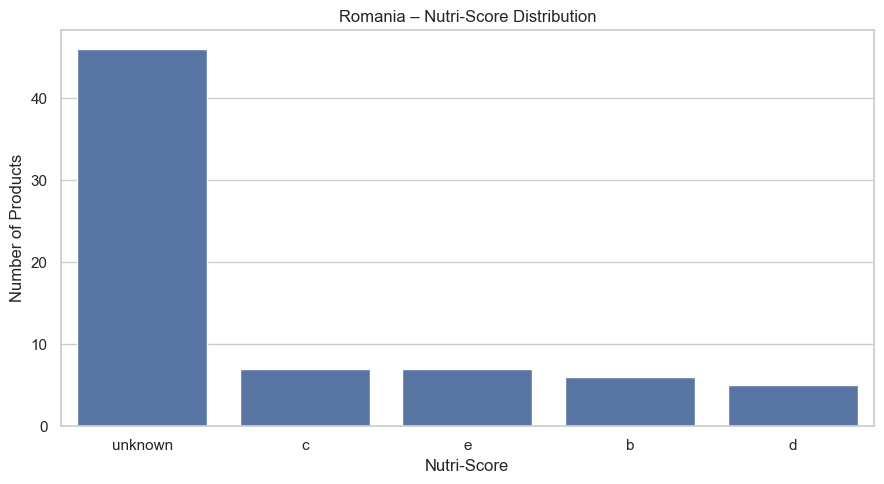

NOVA Group Distribution:


nova_group
Unknown    50
4.0        21
Name: count, dtype: int64

NOVA Group Percentage:


nova_group
Unknown    70.42
4.0        29.58
Name: proportion, dtype: float64

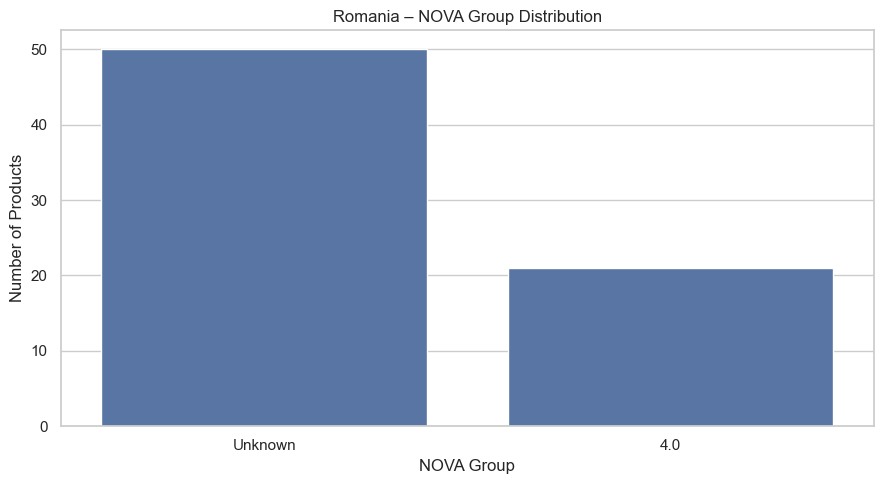

Eco-Score Distribution:


ecoscore_grade
Unknown           53
not-applicable    13
unknown            5
Name: count, dtype: int64

Eco-Score Percentage:


ecoscore_grade
Unknown           74.65
not-applicable    18.31
unknown            7.04
Name: proportion, dtype: float64

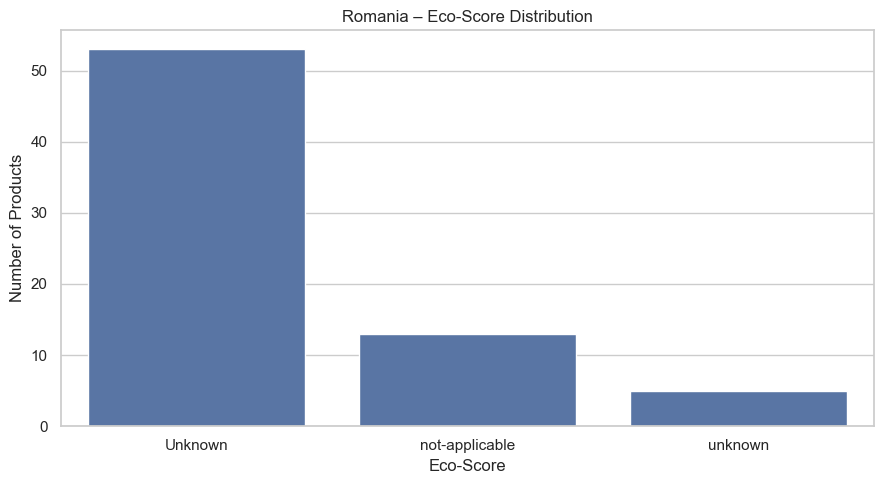

In [99]:
# ============================================================
# ROMANIA — NUTRI-SCORE, NOVA AND ECO-SCORE
# ============================================================

for col, label in [
    ("nutriscore_grade", "Nutri-Score"),
    ("nova_group", "NOVA Group"),
    ("ecoscore_grade", "Eco-Score")
]:
    if col in romania_df.columns:
        counts = romania_df[col].value_counts()
        print(f"{label} Distribution:")
        display(counts)
        print(f"{label} Percentage:")
        display(romania_df[col].value_counts(normalize=True).mul(100).round(2))

        plt.figure(figsize=(9, 5))
        sns.countplot(
            data=romania_df,
            x=col,
            order=romania_df[col].value_counts().index
        )
        plt.title(f"Romania – {label} Distribution")
        plt.xlabel(label)
        plt.ylabel("Number of Products")
        plt.tight_layout()
        plt.show()

Sugar Statistics:


count    19.000000
mean      6.268421
std      13.517316
min       0.000000
25%       0.100000
50%       0.300000
75%       7.450000
max      59.000000
Name: nutriments.sugars_100g_num, dtype: float64

Energy Statistics:


count     18.000000
mean      35.555556
std       77.678994
min        1.000000
25%        2.000000
50%        9.000000
75%       40.000000
max      337.000000
Name: nutriments.energy-kcal_100g_num, dtype: float64

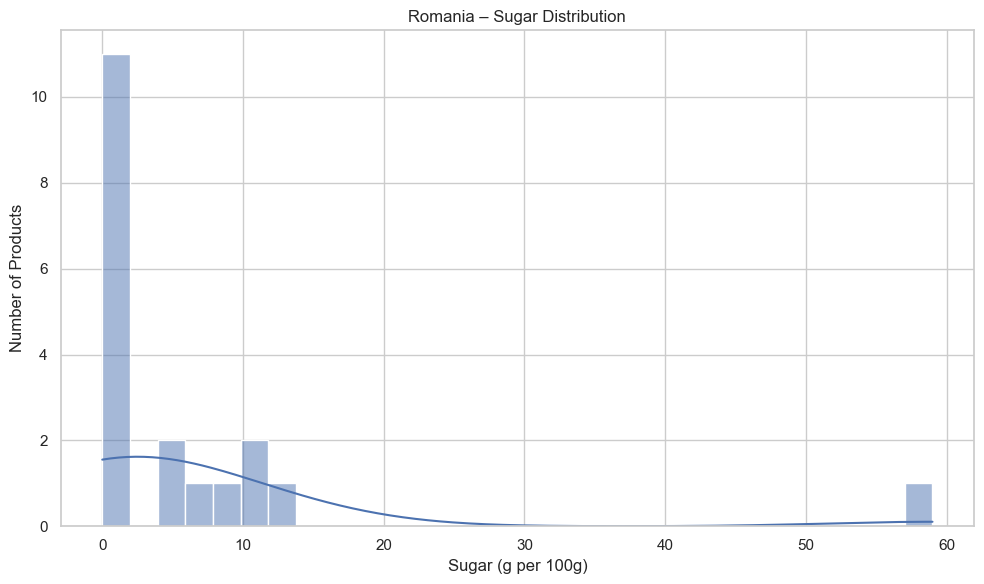

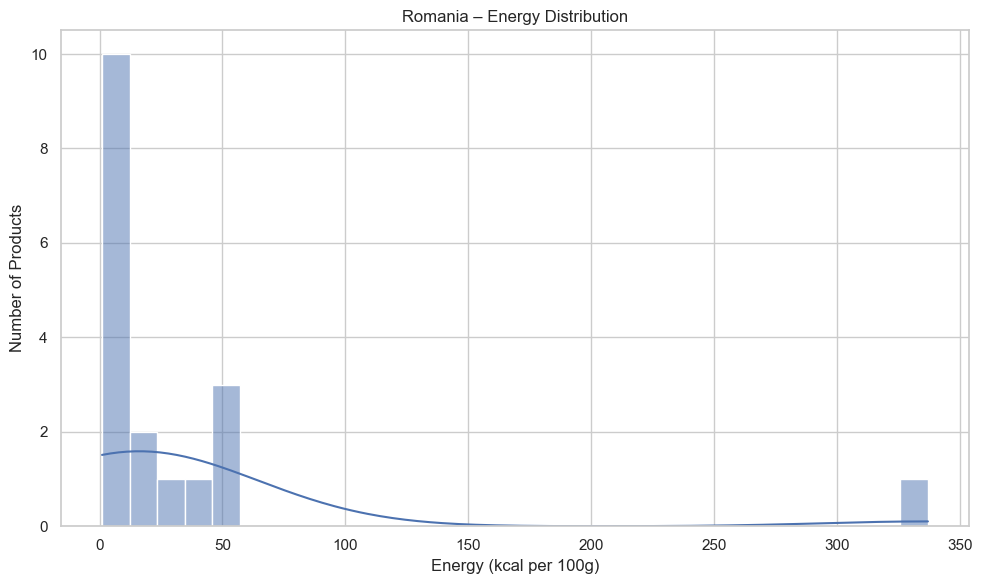

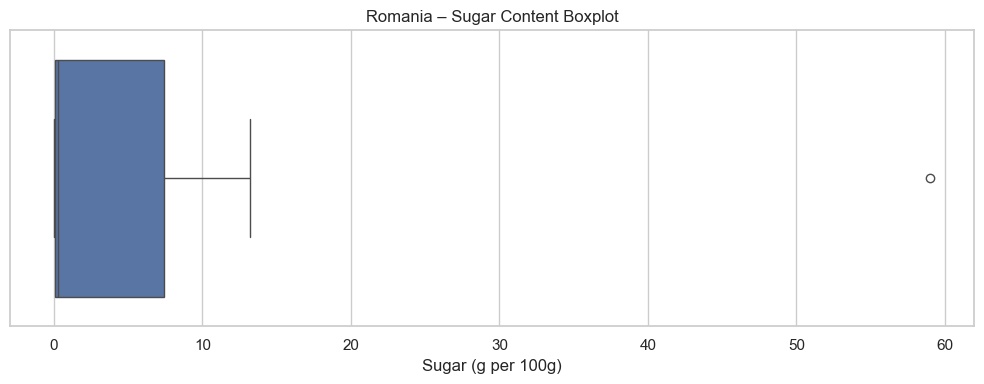

In [100]:
# ============================================================
# ROMANIA — SUGAR AND ENERGY
# ============================================================

romania_sugar = romania_df["nutriments.sugars_100g_num"].dropna()
romania_energy = romania_df["nutriments.energy-kcal_100g_num"].dropna()

print("Sugar Statistics:")
display(romania_sugar.describe())

print("Energy Statistics:")
display(romania_energy.describe())

plt.figure(figsize=(10, 6))
sns.histplot(romania_sugar, bins=30, kde=True)
plt.title("Romania – Sugar Distribution")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(romania_energy, bins=30, kde=True)
plt.title("Romania – Energy Distribution")
plt.xlabel("Energy (kcal per 100g)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=romania_sugar)
plt.title("Romania – Sugar Content Boxplot")
plt.xlabel("Sugar (g per 100g)")
plt.tight_layout()
plt.show()

Valid nutritional records: 16
Sugar–Energy Correlation: 0.995


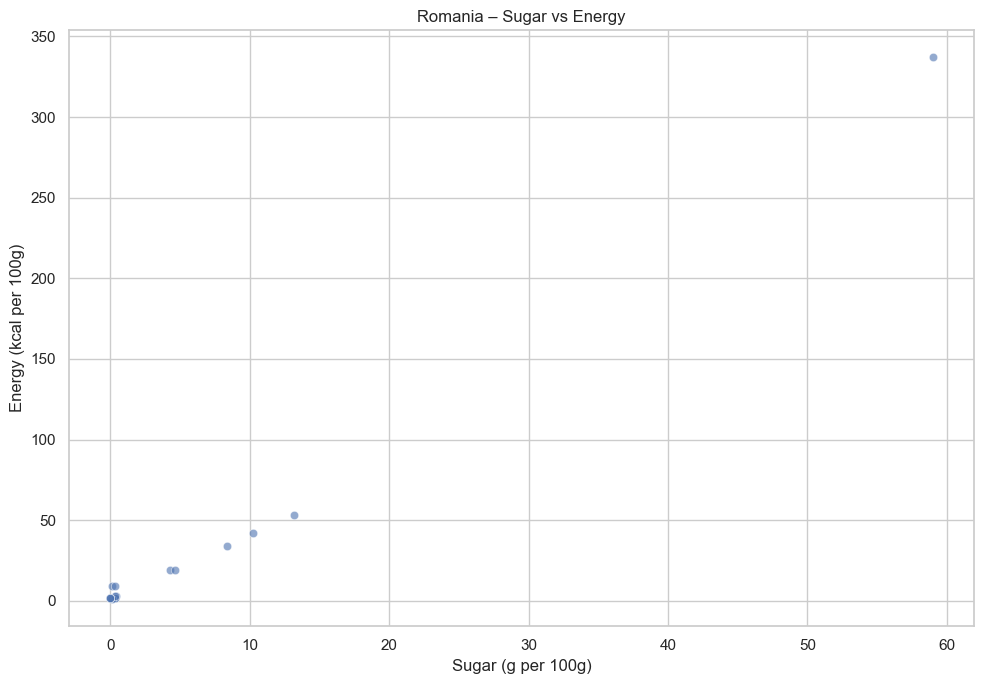

In [101]:
# ============================================================
# ROMANIA — SUGAR VS ENERGY
# ============================================================

romania_nutrition = romania_df[
    ["nutriments.sugars_100g_num", "nutriments.energy-kcal_100g_num"]
].dropna()

romania_sugar_energy_corr = (
    romania_nutrition["nutriments.sugars_100g_num"]
    .corr(romania_nutrition["nutriments.energy-kcal_100g_num"])
)

print("Valid nutritional records:", len(romania_nutrition))
print("Sugar–Energy Correlation:", round(romania_sugar_energy_corr, 3))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=romania_nutrition,
    x="nutriments.sugars_100g_num",
    y="nutriments.energy-kcal_100g_num",
    alpha=0.6
)
plt.title("Romania – Sugar vs Energy")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Energy (kcal per 100g)")
plt.tight_layout()
plt.show()

In [102]:
# ============================================================
# ROMANIA — OUTLIER ANALYSIS
# ============================================================

def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

romania_sugar_outliers = find_outliers(romania_sugar)
romania_energy_outliers = find_outliers(romania_energy)

print("Sugar Outliers:", len(romania_sugar_outliers))
print("Energy Outliers:", len(romania_energy_outliers))

print("\nHighest Sugar Products:")
display(
    romania_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.sugars_100g_num"]
    ].dropna(subset=["nutriments.sugars_100g_num"])
     .sort_values("nutriments.sugars_100g_num", ascending=False)
     .head(20)
)

print("\nHighest Energy Products:")
display(
    romania_df[
        ["product_name", "brands", "categories_tags",
         "nutriments.energy-kcal_100g_num"]
    ].dropna(subset=["nutriments.energy-kcal_100g_num"])
     .sort_values("nutriments.energy-kcal_100g_num", ascending=False)
     .head(20)
)

Sugar Outliers: 1
Energy Outliers: 1

Highest Sugar Products:


,product_name,brands,categories_tags,nutriments.sugars_100g_num
493,Marcelo caramelo,día de fantasía,"snacks, sweet-snacks, confectioneries, candies, gummi-candies",59.0
565,Fanta Tropical 0.5,Coca Cola,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas, sweetened-beverages",13.2
8,Fanta lămâie,Fanta,"plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, ...",11.1
604,Fanta Strawberry kiwi,Fanta,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",10.2
149,Raison,Fanta,ro:suc,8.4
16,Fanta Portocale și fructul pasiunii,Fanta,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",6.5
948,Peach And Jasmine,Fanta,Unknown,4.6
28,Fanta Dark Orange,Fanta,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",4.3
41,"Fanta zero zahăr cu zmeură, lămâie verde și baobab","Fanta, Coca-Cola, Coca-Cola Company","beverages, carbonated-drinks, artificially-sweetened-beverages, sodas, sweetened-beverages",0.4
40,Fanta zero zahăr portocale,"Fanta, Coca-Cola, Coca-Cola Company","plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, artific...",0.3



Highest Energy Products:


,product_name,brands,categories_tags,nutriments.energy-kcal_100g_num
493,Marcelo caramelo,día de fantasía,"snacks, sweet-snacks, confectioneries, candies, gummi-candies",337.0
565,Fanta Tropical 0.5,Coca Cola,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas, sweetened-beverages",53.0
566,Fanta Tropical 2l,Coca Cola,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",53.0
946,Fanta Lamaie,Fanta,Unknown,48.0
604,Fanta Strawberry kiwi,Fanta,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",42.0
149,Raison,Fanta,ro:suc,34.0
948,Peach And Jasmine,Fanta,Unknown,19.0
28,Fanta Dark Orange,Fanta,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",19.0
197,Fanta citron,Fanta,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",9.0
198,Fanta Orange Zero,Fanta,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",9.0


In [103]:
# ============================================================
# ROMANIA — BRAND NUTRITION ANALYSIS
# ============================================================

romania_brand_nutrition = (
    romania_df.groupby("brands")
    .agg(
        Product_Count=("product_name", "count"),
        Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
        Median_Sugar=("nutriments.sugars_100g_num", "median"),
        Avg_Energy=("nutriments.energy-kcal_100g_num", "mean"),
        Median_Energy=("nutriments.energy-kcal_100g_num", "median")
    )
    .reset_index()
)

romania_brand_nutrition = (
    romania_brand_nutrition[
        romania_brand_nutrition["Product_Count"] >= 3
    ]
    .sort_values("Product_Count", ascending=False)
)

display(romania_brand_nutrition.head(20))

,brands,Product_Count,Avg_Sugar,Median_Sugar,Avg_Energy,Median_Energy
2,Fanta,25,4.55,4.45,20.444444,19.0
6,Unknown,25,NaN,NaN,NaN,NaN
0,Coca Cola,10,2.72,0.10,22.200000,2.0


Sugar by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,
b,5,0.14,0.1,0.0,0.3
c,4,0.20,0.2,0.0,0.4
d,2,5.40,5.4,4.3,6.5
e,2,34.60,34.6,10.2,59.0
unknown,6,6.27,6.5,0.0,13.2


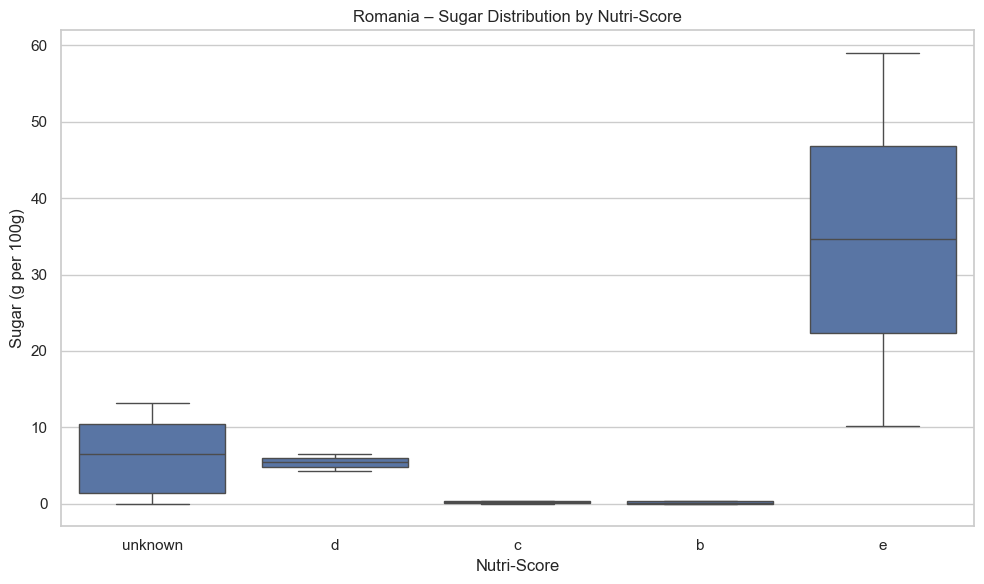

Energy by Nutri-Score:


,count,mean,median,min,max
nutriscore_grade,,,,,
b,5,4.8,2.0,2.0,9.0
c,4,2.0,2.0,1.0,3.0
d,1,19.0,19.0,19.0,19.0
e,2,189.5,189.5,42.0,337.0
unknown,6,35.0,41.0,3.0,53.0


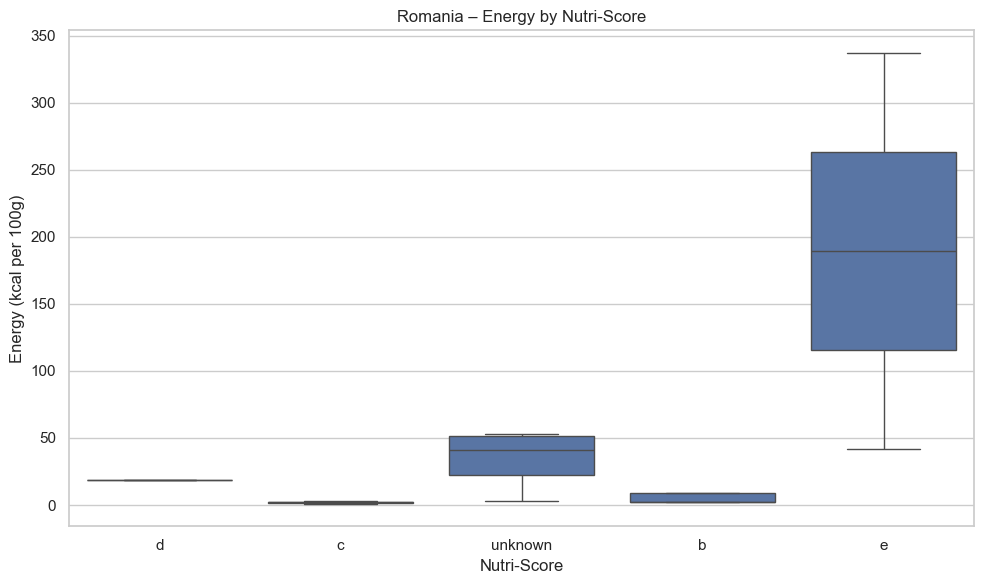

In [104]:
# ============================================================
# ROMANIA — NUTRI-SCORE VS SUGAR / ENERGY
# ============================================================

if "nutriscore_grade" in romania_df.columns:

    romania_nutri_sugar = romania_df[
        ["nutriscore_grade", "nutriments.sugars_100g_num"]
    ].dropna()

    print("Sugar by Nutri-Score:")
    display(
        romania_nutri_sugar.groupby("nutriscore_grade")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=romania_nutri_sugar,
        x="nutriscore_grade",
        y="nutriments.sugars_100g_num"
    )
    plt.title("Romania – Sugar Distribution by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

    romania_nutri_energy = romania_df[
        ["nutriscore_grade", "nutriments.energy-kcal_100g_num"]
    ].dropna()

    print("Energy by Nutri-Score:")
    display(
        romania_nutri_energy.groupby("nutriscore_grade")
        ["nutriments.energy-kcal_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=romania_nutri_energy,
        x="nutriscore_grade",
        y="nutriments.energy-kcal_100g_num"
    )
    plt.title("Romania – Energy by Nutri-Score")
    plt.xlabel("Nutri-Score")
    plt.ylabel("Energy (kcal per 100g)")
    plt.tight_layout()
    plt.show()

,count,mean,median,min,max
nova_group,,,,,
4.0,10,4.61,2.35,0.0,13.2
Unknown,9,8.11,0.30,0.0,59.0


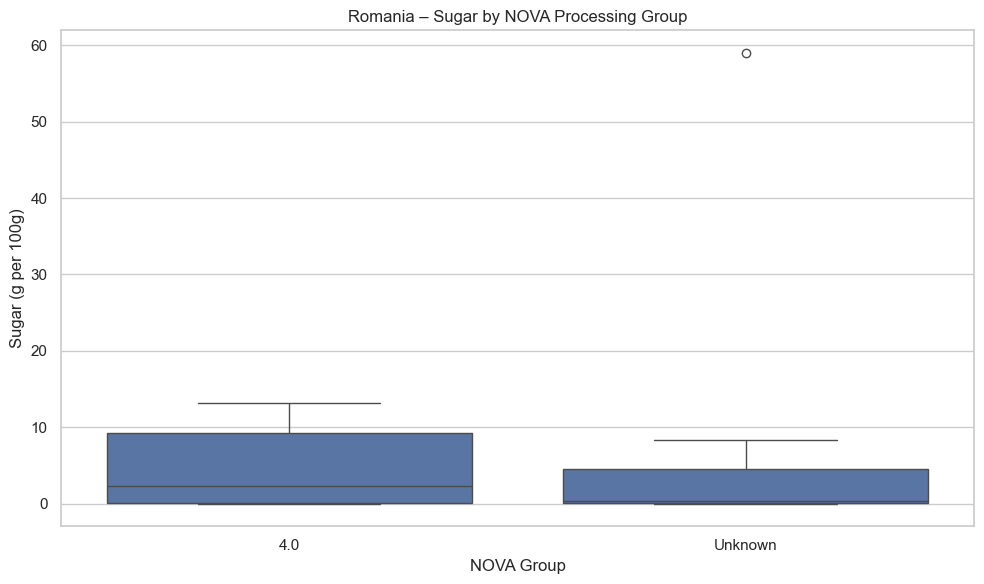

In [105]:
# ============================================================
# ROMANIA — NOVA VS SUGAR
# ============================================================

if "nova_group" in romania_df.columns:

    romania_nova_sugar = romania_df[
        ["nova_group", "nutriments.sugars_100g_num"]
    ].dropna()

    display(
        romania_nova_sugar.groupby("nova_group")
        ["nutriments.sugars_100g_num"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=romania_nova_sugar,
        x="nova_group",
        y="nutriments.sugars_100g_num"
    )
    plt.title("Romania – Sugar by NOVA Processing Group")
    plt.xlabel("NOVA Group")
    plt.ylabel("Sugar (g per 100g)")
    plt.tight_layout()
    plt.show()

,nova_group_num,nutriments.sugars_100g_num,nutriments.energy-kcal_100g_num
nova_group_num,NaN,NaN,NaN
nutriments.sugars_100g_num,NaN,1.000,0.995
nutriments.energy-kcal_100g_num,NaN,0.995,1.000


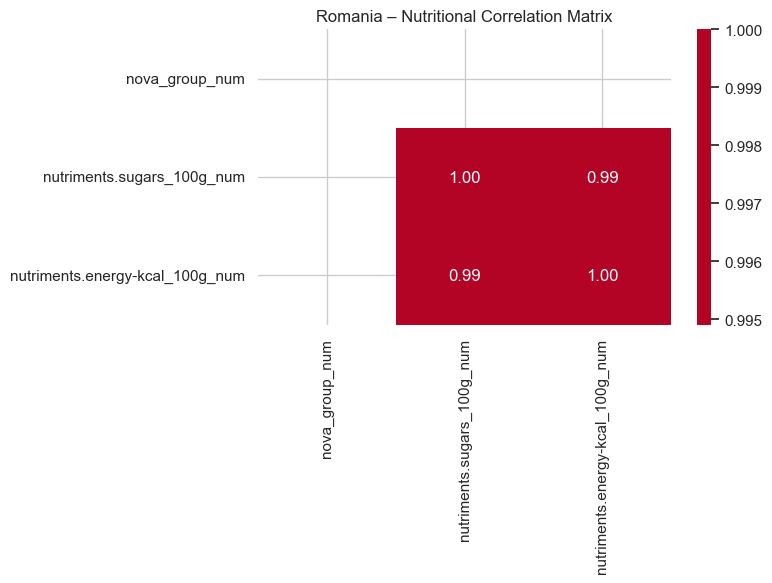

In [106]:
# ============================================================
# ROMANIA — CORRELATION
# ============================================================

corr_cols = [
    "nova_group_num",
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

available_corr_cols = [c for c in corr_cols if c in romania_df.columns]

romania_corr = romania_df[available_corr_cols].corr()

display(romania_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    romania_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Romania – Nutritional Correlation Matrix")
plt.tight_layout()
plt.show()

,Ingredient,Frequency
0,dioxid de carbon,15
1,apă,12
2,zahăr,6
3,acesulfam-k,6
4,arome naturale,5
5,antioxidant acid ascorbic,4
6,apa,4
7,1%),4
8,arome naturale de portocale cu alte arome naturale,4
9,conservant: sorbat de potasiu,4


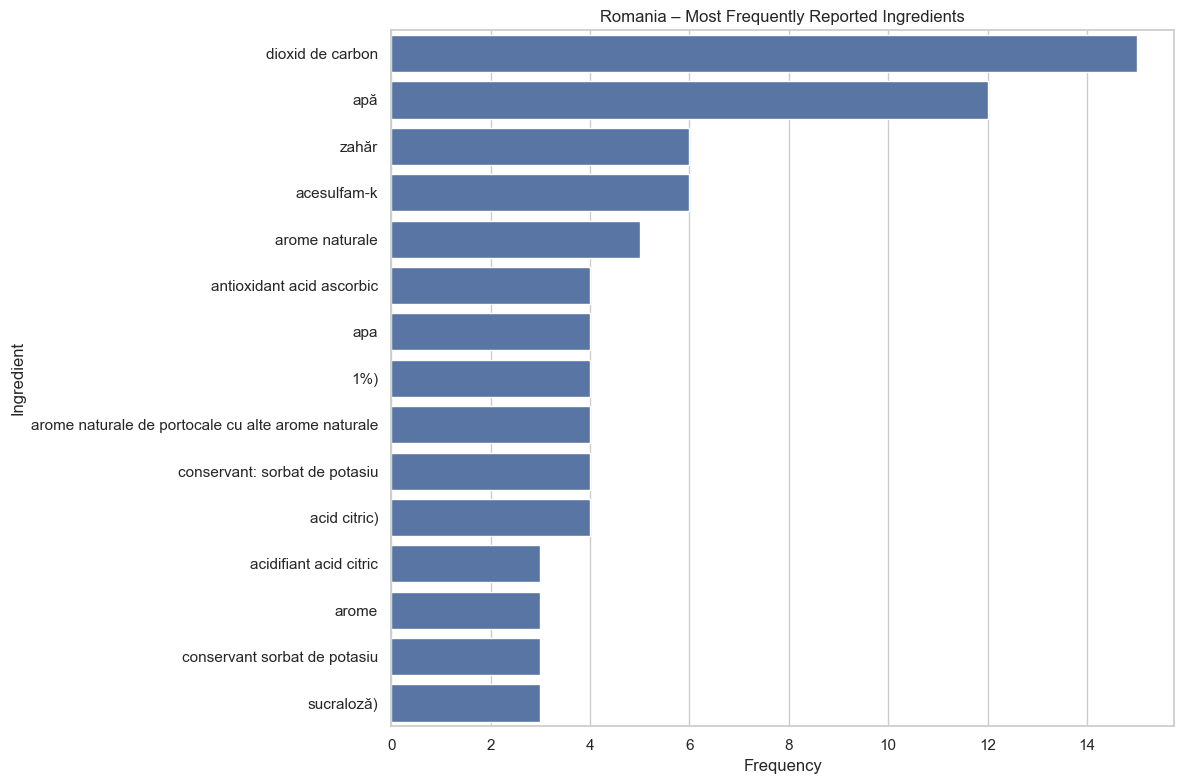

In [107]:
# ============================================================
# ROMANIA — INGREDIENT ANALYSIS
# ============================================================

if "ingredients_text" in romania_df.columns:

    ingredient_text = romania_df["ingredients_text"].astype(str).str.lower()
    all_ingredients = []

    for text in ingredient_text:
        if text != "unknown":
            for ingredient in text.split(","):
                ingredient = ingredient.strip()
                if ingredient and ingredient != "unknown":
                    all_ingredients.append(ingredient)

    romania_ingredient_counts = Counter(all_ingredients)

    romania_ingredient_df = pd.DataFrame(
        romania_ingredient_counts.most_common(30),
        columns=["Ingredient", "Frequency"]
    )

    display(romania_ingredient_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=romania_ingredient_df.head(15),
        x="Frequency",
        y="Ingredient"
    )
    plt.title("Romania – Most Frequently Reported Ingredients")
    plt.xlabel("Frequency")
    plt.ylabel("Ingredient")
    plt.tight_layout()
    plt.show()

In [108]:
# ============================================================
# ROMANIA — CATEGORY VS NUTRITION
# ============================================================

if "categories_tags" in romania_df.columns:

    romania_category_nutrition = (
        romania_df.groupby("categories_tags")
        .agg(
            Product_Count=("product_name", "count"),
            Avg_Sugar=("nutriments.sugars_100g_num", "mean"),
            Avg_Energy=("nutriments.energy-kcal_100g_num", "mean")
        )
        .reset_index()
    )

    romania_category_nutrition = (
        romania_category_nutrition[
            romania_category_nutrition["Product_Count"] >= 2
        ]
        .sort_values("Product_Count", ascending=False)
    )

    display(romania_category_nutrition.head(20))

,categories_tags,Product_Count,Avg_Sugar,Avg_Energy
0,Unknown,34,4.600000,33.500000
9,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",7,5.100000,47.500000
16,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-...",3,1.566667,12.333333
1,"beverages, artificially-sweetened-beverages",2,0.050000,1.500000
2,"beverages, carbonated-drinks, artificially-sweetened-beverages, sodas, diet-beverages, diet-sodas",2,0.000000,2.000000
12,"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas, sweetened-beverages",2,13.200000,53.000000


In [109]:
# ============================================================
# ROMANIA — ATTRIBUTE-LEVEL ANALYSIS
# ============================================================

categorical_columns = [
    "brands",
    "categories_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "nutriscore_grade",
    "nova_group",
    "ecoscore_grade"
]

for col in categorical_columns:
    if col in romania_df.columns:
        print("\n" + "=" * 70)
        print(f"ATTRIBUTE: {col}")
        print("=" * 70)

        counts = (
            romania_df[col]
            .astype(str)
            .value_counts()
            .head(15)
        )

        display(counts.to_frame("Count"))


ATTRIBUTE: brands


,Count
brands,
Fanta,25
Unknown,25
Coca Cola,10
"Fanta, Coca-Cola, Coca-Cola Company",2
Coca-Cola,2
coca cola,2
día de fantasía,1
fantail,1
"Fanta, Cadia, Coca-Cola, Coca-Cola Company",1



ATTRIBUTE: categories_tags


,Count
categories_tags,
Unknown,34
"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas",7
"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, fruit-sodas",3
"beverages, carbonated-drinks, artificially-sweetened-beverages, sodas, diet-beverages, diet-sodas",2
"beverages-and-beverages-preparations, beverages, carbonated-drinks, sodas, sweetened-beverages",2
"beverages, artificially-sweetened-beverages",2
"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, fruit-sodas, sweetened-beverages",1
ro:suc,1
"plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages, sodas, fruit-sodas, sweetened-beverages",1



ATTRIBUTE: packaging_tags


...

,Count
nutriscore_grade,
unknown,46
c,7
e,7
b,6
d,5



ATTRIBUTE: nova_group


,Count
nova_group,
Unknown,50
4.0,21



ATTRIBUTE: ecoscore_grade


,Count
ecoscore_grade,
Unknown,53
not-applicable,13
unknown,5


In [110]:
# ============================================================
# ROMANIA — NUMERICAL ATTRIBUTE ANALYSIS
# ============================================================

numerical_columns = [
    "nutriments.sugars_100g_num",
    "nutriments.energy-kcal_100g_num"
]

romania_numeric_summary = []

for col in numerical_columns:
    if col in romania_df.columns:
        romania_numeric_summary.append({
            "Attribute": col,
            "Count": romania_df[col].count(),
            "Mean": romania_df[col].mean(),
            "Median": romania_df[col].median(),
            "Std": romania_df[col].std(),
            "Minimum": romania_df[col].min(),
            "Maximum": romania_df[col].max()
        })

romania_numeric_summary = pd.DataFrame(romania_numeric_summary)
display(romania_numeric_summary.round(2))

,Attribute,Count,Mean,Median,Std,Minimum,Maximum
0,nutriments.sugars_100g_num,19,6.27,0.3,13.52,0.0,59.0
1,nutriments.energy-kcal_100g_num,18,35.56,9.0,77.68,1.0,337.0


In [111]:
# ============================================================
# ROMANIA — DATA QUALITY CHECK
# ============================================================

print("ROMANIA DATA QUALITY CHECK")
print("=" * 60)

print("Duplicate Rows:", romania_df.duplicated().sum())
print("Duplicate Product Names:", romania_df["product_name"].duplicated().sum())
print("Unique Products:", romania_df["product_name"].nunique())
print("Unique Brands:", romania_df["brands"].nunique())
print("Records:", len(romania_df))

ROMANIA DATA QUALITY CHECK
Duplicate Rows: 0
Duplicate Product Names: 6
Unique Products: 65
Unique Brands: 11
Records: 71


In [112]:
# ============================================================
# ROMANIA — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("🌍 ROMANIA – ADVANCED DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nTotal Records: {len(romania_df):,}")
print(f"Unique Products: {romania_df['product_name'].nunique():,}")
print(f"Unique Brands: {romania_df['brands'].nunique():,}")

print("\nTop 5 Brands:")
display(romania_brand_counts.head(5))

print("\nTop 5 Categories:")
display(romania_category_counts.head(5))

print("\nTop Packaging Types:")
display(romania_packaging_counts.head(5))

print("\nTop Stores:")
display(romania_store_counts.head(5))

print("\nTop Purchase Places:")
display(romania_purchase_counts.head(5))

if "nutriscore_grade" in romania_df.columns:
    print("\nNutri-Score Distribution:")
    display(romania_df["nutriscore_grade"].value_counts())

if "nova_group" in romania_df.columns:
    print("\nNOVA Distribution:")
    display(romania_df["nova_group"].value_counts())

if "ecoscore_grade" in romania_df.columns:
    print("\nEco-Score Distribution:")
    display(romania_df["ecoscore_grade"].value_counts())

print("\nNutritional Statistics:")
display(pd.DataFrame({
    "Metric": [
        "Average Sugar", "Median Sugar", "Maximum Sugar",
        "Average Energy", "Median Energy", "Maximum Energy"
    ],
    "Value": [
        romania_sugar.mean(), romania_sugar.median(), romania_sugar.max(),
        romania_energy.mean(), romania_energy.median(), romania_energy.max()
    ]
}).round(2))

print("\nSugar–Energy Correlation:", round(romania_sugar_energy_corr, 3))
print("\nAnalysis completed for Romania.")

🌍 ROMANIA – ADVANCED DATA ANALYSIS SUMMARY

Total Records: 71
Unique Products: 65
Unique Brands: 11

Top 5 Brands:


,Brand,Product_Count
0,Fanta,25
1,Unknown,25
2,Coca Cola,10
3,"Fanta, Coca-Cola, Coca-Cola Company",2
4,Coca-Cola,2



Top 5 Categories:


categories_tags
beverages                               34
carbonated-drinks                       30
sodas                                   28
beverages-and-beverages-preparations    23
plant-based-foods-and-beverages         12
Name: count, dtype: int64


Top Packaging Types:


...


Eco-Score Distribution:


ecoscore_grade
Unknown           53
not-applicable    13
unknown            5
Name: count, dtype: int64


Nutritional Statistics:


,Metric,Value
0,Average Sugar,6.27
1,Median Sugar,0.30
2,Maximum Sugar,59.00
3,Average Energy,35.56
4,Median Energy,9.00
5,Maximum Energy,337.00



Sugar–Energy Correlation: 0.995

Analysis completed for Romania.


# PART 6 — FIVE-COUNTRY COMPARATIVE ADVANCED ANALYSIS

All five individual analyses are now complete. This section compares the countries using the **same single dataframe `df`**.

In [113]:
# ============================================================
# 31. VERIFY FIVE COUNTRIES
# ============================================================

countries_to_check = [
    "united-states",
    "italy",
    "united-kingdom",
    "australia",
    "romania"
]

country_summary = (
    df[
        df["countries_tags"].astype(str).str.lower().isin(countries_to_check)
    ]
    .assign(Country=lambda x: x["countries_tags"].astype(str).str.lower())
    .groupby("Country")
    .size()
    .reindex(countries_to_check)
    .reset_index(name="Record_Count")
)

display(country_summary)

,Country,Record_Count
0,united-states,435
1,italy,315
2,united-kingdom,143
3,australia,95
4,romania,71


In [114]:
# ============================================================
# 32. RECORD / PRODUCT / BRAND COMPARISON
# ============================================================

comparison_df = (
    df[
        df["countries_tags"].astype(str).str.lower().isin(countries_to_check)
    ]
    .assign(Country=lambda x: x["countries_tags"].astype(str).str.lower())
    .groupby("Country")
    .agg(
        Records=("product_name", "count"),
        Unique_Products=("product_name", "nunique"),
        Unique_Brands=("brands", "nunique")
    )
    .reindex(countries_to_check)
    .reset_index()
)

comparison_df["Brand_Diversity_Percentage"] = (
    comparison_df["Unique_Brands"] /
    comparison_df["Records"] * 100
).round(2)

display(comparison_df)

,Country,Records,Unique_Products,Unique_Brands,Brand_Diversity_Percentage
0,united-states,435,338,88,20.23
1,italy,315,263,126,40.00
2,united-kingdom,143,101,30,20.98
3,australia,95,90,16,16.84
4,romania,71,65,11,15.49


In [115]:
# ============================================================
# 33. NUTRITIONAL COMPARISON
# ============================================================

nutrition_comparison = (
    df[
        df["countries_tags"].astype(str).str.lower().isin(countries_to_check)
    ]
    .assign(Country=lambda x: x["countries_tags"].astype(str).str.lower())
    .groupby("Country")
    .agg(
        Average_Sugar=("nutriments.sugars_100g_num", "mean"),
        Median_Sugar=("nutriments.sugars_100g_num", "median"),
        Maximum_Sugar=("nutriments.sugars_100g_num", "max"),
        Average_Energy=("nutriments.energy-kcal_100g_num", "mean"),
        Median_Energy=("nutriments.energy-kcal_100g_num", "median"),
        Maximum_Energy=("nutriments.energy-kcal_100g_num", "max")
    )
    .reindex(countries_to_check)
    .reset_index()
)

display(nutrition_comparison.round(2))

,Country,Average_Sugar,Median_Sugar,Maximum_Sugar,Average_Energy,Median_Energy,Maximum_Energy
0,united-states,14.71,2.0,254.0,182.62,9.35,26000.0
1,italy,NaN,NaN,NaN,NaN,NaN,NaN
2,united-kingdom,NaN,NaN,NaN,NaN,NaN,NaN
3,australia,13.62,4.2,99.9,195.47,93.10,536.0
4,romania,6.27,0.3,59.0,35.56,9.00,337.0


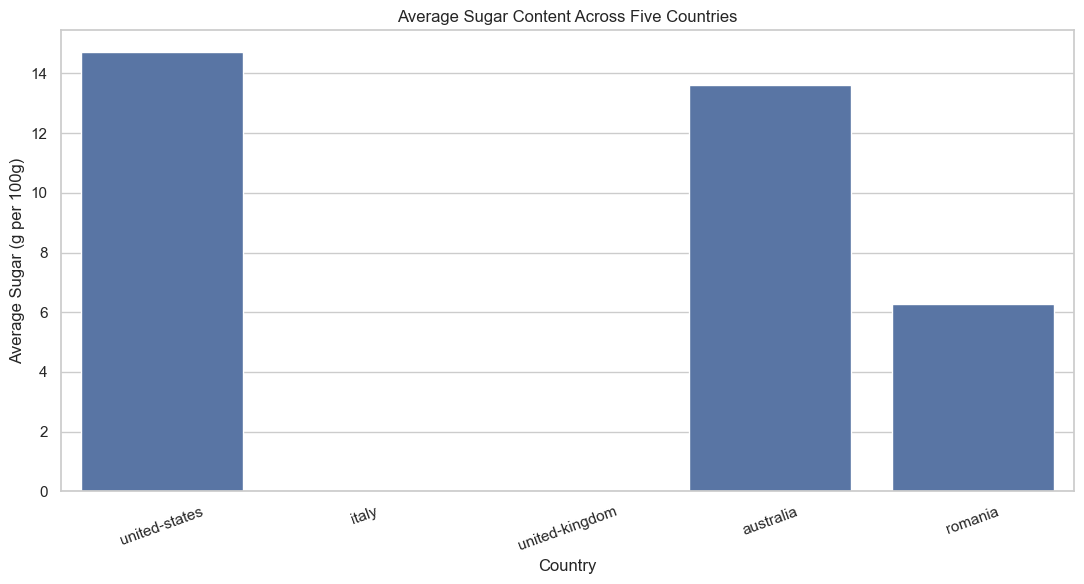

In [116]:
# ============================================================
# 34. AVERAGE SUGAR BY COUNTRY
# ============================================================

plt.figure(figsize=(11, 6))
sns.barplot(
    data=nutrition_comparison,
    x="Country",
    y="Average_Sugar"
)
plt.title("Average Sugar Content Across Five Countries")
plt.xlabel("Country")
plt.ylabel("Average Sugar (g per 100g)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

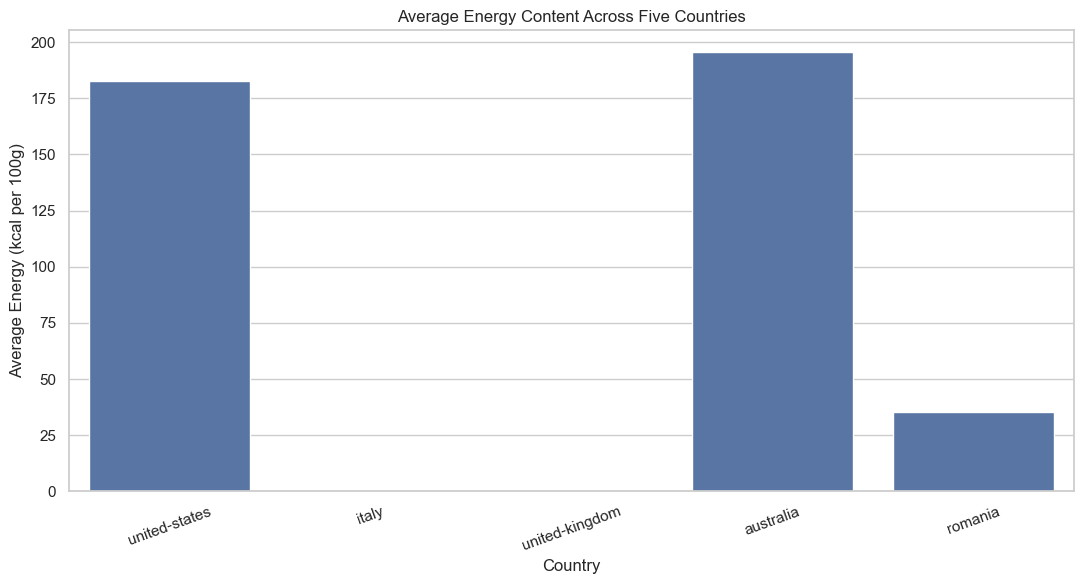

In [117]:
# ============================================================
# 35. AVERAGE ENERGY BY COUNTRY
# ============================================================

plt.figure(figsize=(11, 6))
sns.barplot(
    data=nutrition_comparison,
    x="Country",
    y="Average_Energy"
)
plt.title("Average Energy Content Across Five Countries")
plt.xlabel("Country")
plt.ylabel("Average Energy (kcal per 100g)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [118]:
# ============================================================
# 36. NUTRI-SCORE COMPARISON
# ============================================================

nutri_comparison = pd.crosstab(
    df["countries_tags"].astype(str).str.lower(),
    df["nutriscore_grade"]
).reindex(countries_to_check).fillna(0)

display(nutri_comparison)

nutri_percentage = (
    nutri_comparison
    .div(nutri_comparison.sum(axis=1), axis=0)
    * 100
).round(2)

print("Nutri-Score Percentage by Country:")
display(nutri_percentage)

nutriscore_grade,Unknown,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,,
united-states,0,1,150,48,8,54,0,174
italy,1,18,14,25,26,16,9,206
united-kingdom,0,1,6,14,11,5,0,106
australia,0,0,1,0,2,1,0,91
romania,0,0,6,7,5,7,0,46


Nutri-Score Percentage by Country:


nutriscore_grade,Unknown,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,,
united-states,0.00,0.23,34.48,11.03,1.84,12.41,0.00,40.00
italy,0.32,5.71,4.44,7.94,8.25,5.08,2.86,65.40
united-kingdom,0.00,0.70,4.20,9.79,7.69,3.50,0.00,74.13
australia,0.00,0.00,1.05,0.00,2.11,1.05,0.00,95.79
romania,0.00,0.00,8.45,9.86,7.04,9.86,0.00,64.79


In [119]:
# ============================================================
# 37. NOVA GROUP COMPARISON
# ============================================================

nova_comparison = pd.crosstab(
    df["countries_tags"].astype(str).str.lower(),
    df["nova_group"]
).reindex(countries_to_check).fillna(0)

display(nova_comparison)

nova_percentage = (
    nova_comparison
    .div(nova_comparison.sum(axis=1), axis=0)
    * 100
).round(2)

print("NOVA Percentage by Country:")
display(nova_percentage)

nova_group,1.0,3.0,4.0,Unknown
countries_tags,,,,
united-states,1,2,51,381
italy,6,7,23,279
united-kingdom,1,4,29,109
australia,0,0,26,69
romania,0,0,21,50


NOVA Percentage by Country:


nova_group,1.0,3.0,4.0,Unknown
countries_tags,,,,
united-states,0.23,0.46,11.72,87.59
italy,1.90,2.22,7.30,88.57
united-kingdom,0.70,2.80,20.28,76.22
australia,0.00,0.00,27.37,72.63
romania,0.00,0.00,29.58,70.42


In [120]:
# ============================================================
# 38. ECO-SCORE COMPARISON
# ============================================================

eco_comparison = pd.crosstab(
    df["countries_tags"].astype(str).str.lower(),
    df["ecoscore_grade"]
).reindex(countries_to_check).fillna(0)

display(eco_comparison)

eco_percentage = (
    eco_comparison
    .div(eco_comparison.sum(axis=1), axis=0)
    * 100
).round(2)

print("Eco-Score Percentage by Country:")
display(eco_percentage)

ecoscore_grade,Unknown,d,f,not-applicable,unknown
countries_tags,,,,,
united-states,346,2,2,3,82
italy,314,0,0,0,1
united-kingdom,134,0,0,1,8
australia,64,0,0,2,29
romania,53,0,0,13,5


Eco-Score Percentage by Country:


ecoscore_grade,Unknown,d,f,not-applicable,unknown
countries_tags,,,,,
united-states,79.54,0.46,0.46,0.69,18.85
italy,99.68,0.00,0.00,0.00,0.32
united-kingdom,93.71,0.00,0.00,0.70,5.59
australia,67.37,0.00,0.00,2.11,30.53
romania,74.65,0.00,0.00,18.31,7.04


In [121]:
# ============================================================
# 39. SUGAR–ENERGY CORRELATION BY COUNTRY
# ============================================================

country_correlations = []

for country in countries_to_check:
    temp = df[
        df["countries_tags"].astype(str).str.lower() == country
    ][
        [
            "nutriments.sugars_100g_num",
            "nutriments.energy-kcal_100g_num"
        ]
    ].dropna()

    country_correlations.append({
        "Country": country,
        "Valid_Records": len(temp),
        "Sugar_Energy_Correlation": (
            temp["nutriments.sugars_100g_num"]
            .corr(temp["nutriments.energy-kcal_100g_num"])
            if len(temp) > 1 else np.nan
        )
    })

country_correlations = pd.DataFrame(country_correlations)

display(country_correlations.round(3))

,Country,Valid_Records,Sugar_Energy_Correlation
0,united-states,324,0.062
1,italy,0,NaN
2,united-kingdom,0,NaN
3,australia,50,0.473
4,romania,16,0.995


In [122]:
# ============================================================
# 40. TOP BRANDS BY COUNTRY
# ============================================================

for country in countries_to_check:
    print("\n" + "=" * 70)
    print(country.upper())
    print("=" * 70)

    temp = df[
        df["countries_tags"].astype(str).str.lower() == country
    ]

    display(
        temp["brands"]
        .value_counts()
        .head(10)
        .to_frame("Product_Count")
    )


UNITED-STATES


,Product_Count
brands,
Fanta,76
Firehouse Subs,72
Unknown,49
Zaxby's,32
White Castle,30
Whataburger,14
Sonic,10
Church's Chicken,10
Jack in the Box,8



ITALY


,Product_Count
brands,
Unknown,79
Fanta,29
Fantasie Aromatiche,27
"Fantasy, Menz & Gasser",8
Gusto e fantasia,6
"Euroverde, Fantasie dell'Orto",5
Coop,5
Gallo,4
Selex,4



UNITED-KINGDOM


,Product_Count
brands,
Fanta,96
Unknown,14
Coca Cola,3
Brompton House,3
Sunfeast,2
"OceanSea,Tesco",1
Dorset cereals,1
"Sierra, Fanta",1
Gelatelli,1



AUSTRALIA


,Product_Count
brands,
Fantastic,36
Fanta,28
Unknown,12
Coles,4
Coca-Cola,2
Bare Bakers,2
Dark Fantasy,2
"Coles Supermarket, Coles",1
Fini,1



ROMANIA


,Product_Count
brands,
Fanta,25
Unknown,25
Coca Cola,10
"Fanta, Coca-Cola, Coca-Cola Company",2
Coca-Cola,2
coca cola,2
día de fantasía,1
fantail,1
"Fanta, Cadia, Coca-Cola, Coca-Cola Company",1


In [123]:
# ============================================================
# 41. TOP CATEGORIES BY COUNTRY
# ============================================================

for country in countries_to_check:
    print("\n" + "=" * 70)
    print(country.upper())
    print("=" * 70)

    temp = df[
        df["countries_tags"].astype(str).str.lower() == country
    ]

    categories = (
        temp["categories_tags"]
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
    )

    categories = categories[
        categories.str.lower() != "unknown"
    ]

    display(
        categories.value_counts()
        .head(10)
        .to_frame("Product_Count")
    )


UNITED-STATES


,Product_Count
categories_tags,
beverages,257
beverages-and-beverages-preparations,243
carbonated-drinks,19
sodas,18
plant-based-foods-and-beverages,13
snacks,11
sweet-snacks,10
confectioneries,9
plant-based-foods,7



ITALY


,Product_Count
categories_tags,
plant-based-foods-and-beverages,75
plant-based-foods,66
beverages,20
frozen-foods,17
snacks,16
fruits-and-vegetables-based-foods,15
sweet-snacks,14
meals,13
seeds,12



UNITED-KINGDOM


,Product_Count
categories_tags,
beverages,34
carbonated-drinks,25
sodas,23
beverages-and-beverages-preparations,22
plant-based-foods-and-beverages,18
fruit-based-beverages,15
plant-based-beverages,15
fruit-sodas,14
sweetened-beverages,11



AUSTRALIA


,Product_Count
categories_tags,
plant-based-foods-and-beverages,9
plant-based-foods,9
pastas,9
noodles,9
dried-products,8
dried-products-to-be-rehydrated,8
instant-noodles,8
crackers-appetizers,5
appetizers,5



ROMANIA


,Product_Count
categories_tags,
beverages,34
carbonated-drinks,30
sodas,28
beverages-and-beverages-preparations,23
plant-based-foods-and-beverages,12
plant-based-beverages,12
fruit-based-beverages,11
sweetened-beverages,11
fruit-sodas,9


In [124]:
# ============================================================
# 42. DATA QUALITY COMPARISON
# ============================================================

quality_rows = []

for country in countries_to_check:

    temp = df[
        df["countries_tags"].astype(str).str.lower() == country
    ]

    unknown_total = sum(
        temp[col].astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
        for col in temp.columns
    )

    quality_rows.append({
        "Country": country,
        "Records": len(temp),
        "Duplicate_Rows": temp.duplicated().sum(),
        "Unknown_Cells": unknown_total,
        "Unique_Products": temp["product_name"].nunique(),
        "Unique_Brands": temp["brands"].nunique()
    })

quality_comparison = pd.DataFrame(quality_rows)

display(quality_comparison)

,Country,Records,Duplicate_Rows,Unknown_Cells,Unique_Products,Unique_Brands
0,united-states,435,0,2843,338,88
1,italy,315,0,2843,263,126
2,united-kingdom,143,0,1269,101,30
3,australia,95,0,750,90,16
4,romania,71,0,559,65,11


#  PART 7 — AUTOMATED FINAL INSIGHTS

The following cell creates data-driven summary statements from the actual results in the notebook.

In [126]:
# ============================================================
# 43. AUTOMATED FINAL INSIGHTS
# ============================================================

print("=" * 80)
print("FINAL FIVE-COUNTRY DATA ANALYSIS INSIGHTS")
print("=" * 80)

highest_records = comparison_df.loc[
    comparison_df["Records"].idxmax()
]

highest_brands = comparison_df.loc[
    comparison_df["Unique_Brands"].idxmax()
]

highest_avg_sugar = nutrition_comparison.loc[
    nutrition_comparison["Average_Sugar"].idxmax()
]

lowest_avg_sugar = nutrition_comparison.loc[
    nutrition_comparison["Average_Sugar"].idxmin()
]

highest_avg_energy = nutrition_comparison.loc[
    nutrition_comparison["Average_Energy"].idxmax()
]

lowest_avg_energy = nutrition_comparison.loc[
    nutrition_comparison["Average_Energy"].idxmin()
]

print(
    f"\n• Highest number of records: "
    f"{highest_records['Country']} "
    f"({int(highest_records['Records']):,})"
)

print(
    f"• Highest number of unique brands: "
    f"{highest_brands['Country']} "
    f"({int(highest_brands['Unique_Brands']):,})"
)

print(
    f"• Highest average sugar: "
    f"{highest_avg_sugar['Country']} "
    f"({highest_avg_sugar['Average_Sugar']:.2f} g/100g)"
)

print(
    f"• Lowest average sugar: "
    f"{lowest_avg_sugar['Country']} "
    f"({lowest_avg_sugar['Average_Sugar']:.2f} g/100g)"
)

print(
    f"• Highest average energy: "
    f"{highest_avg_energy['Country']} "
    f"({highest_avg_energy['Average_Energy']:.2f} kcal/100g)"
)

print(
    f"• Lowest average energy: "
    f"{lowest_avg_energy['Country']} "
    f"({lowest_avg_energy['Average_Energy']:.2f} kcal/100g)"
)

FINAL FIVE-COUNTRY DATA ANALYSIS INSIGHTS

• Highest number of records: united-states (435)
• Highest number of unique brands: italy (126)
• Highest average sugar: united-states (14.71 g/100g)
• Lowest average sugar: romania (6.27 g/100g)
• Highest average energy: australia (195.47 kcal/100g)
• Lowest average energy: romania (35.56 kcal/100g)


#  Five-Country Advanced Data Analysis — Observations & Detailed Comparison

##  Project Overview

This project performs an advanced exploratory data analysis of food-product data from five countries:

- 🇺🇸 United States
- 🇮🇹 Italy
- 🇬🇧 United Kingdom
- 🇦🇺 Australia
- 🇷🇴 Romania

The analysis was performed using **one combined dataset**, while country-specific observations were generated by filtering the same dataframe.

The main objective of this analysis is to understand differences in:

- Product availability
- Brand diversity
- Product categories
- Packaging
- Stores and purchase locations
- Nutritional quality
- Nutri-Score
- NOVA food-processing groups
- Eco-Score
- Sugar content
- Energy content
- Ingredients
- Nutritional relationships
- Data quality

---

# 1.  Data Cleaning & Preparation — Observation

The dataset was first inspected for missing values, duplicate records, inconsistent entries, and different attribute types.

All missing and null values were standardized to **`Unknown`** rather than being removed. This approach preserves the original records and prevents unnecessary loss of information.

Additional numerical analysis columns were created for important nutritional attributes such as:

- Sugar per 100g
- Energy per 100g
- NOVA Group

The original categorical information was retained while numerical copies were created for statistical analysis.

### Key Observation

The cleaning process provides a consistent foundation for comparing all five countries. Using `Unknown` as a common missing-value label also makes attribute-level data-quality analysis easier.

---

# 2.  Country-Level Dataset Comparison

The same dataset was divided logically into five analytical subsets:

- United States
- Italy
- United Kingdom
- Australia
- Romania

No separate CSV files were created. Each country was analyzed using a temporary dataframe while the original combined dataframe remained unchanged.

### Observation

The number of records varies between countries. Therefore, absolute product counts should be interpreted together with percentages and ratios rather than comparing raw counts alone.

The country with the largest number of records represents the largest portion of the dataset, while the country with fewer records has a smaller representation.

---

# 3.  Product Analysis — Observation

Product-level analysis identifies the most frequently occurring products in each country.

The analysis helps determine:

- Which products dominate the dataset
- Whether product records are highly concentrated
- Whether the dataset contains many unique products
- Which countries show greater product diversity

### Comparative Observation

The product distributions are not expected to be identical across the five countries.

Differences can be influenced by:

- Local food preferences
- Market availability
- Brand presence
- Data collection coverage
- Regional product registration

A country with a high number of unique products demonstrates greater product variety within the available dataset.

### Important Interpretation

Product frequency does **not necessarily indicate popularity or market share**. It represents the number of records available in the dataset.

---

# 4.  Brand Analysis — Observation

Brand analysis was performed to identify the most frequently represented brands in each country.

The analysis also calculated the number of unique brands and the brand-diversity ratio.

### Comparative Observation

The five countries show differences in brand representation.

Some countries may have:

- A small number of dominant brands
- A highly fragmented brand market
- Many international brands
- A mixture of local and international brands

A high number of unique brands indicates greater brand variety in the available dataset.

### Brand Diversity

The Brand Diversity Percentage was calculated as:

**Brand Diversity = Unique Brands / Total Records × 100**

A higher value indicates that the dataset contains a wider range of brands relative to the number of records.

---

# 5.  Category Analysis — Observation

Product categories were analyzed to identify the most frequently represented food categories.

This analysis helps understand the structure of food products recorded in each country.

### Key Findings to Compare

For each country, examine:

1. The most common category
2. The top five categories
3. The number of different categories
4. Whether certain categories dominate the dataset

### Comparative Observation

Differences in category distribution can indicate differences in the types of products represented in each country's dataset.

However, category frequency should be interpreted as **dataset representation**, not direct evidence of consumer demand.

---

# 6.  Packaging Analysis — Observation

Packaging information was analyzed by splitting multi-value packaging fields and counting individual packaging types.

This allows the analysis to identify common packaging formats across countries.

### Comparative Observation

The packaging analysis provides insight into the types of packaging most frequently associated with products in each country.

Differences may reflect:

- Product categories
- Packaging practices
- Market conventions
- Data availability
- Product manufacturers

Packaging frequency alone should not be interpreted as an environmental impact measurement.

---

# 7.  Store Analysis — Observation

Store information was analyzed to identify the most frequently reported retail locations.

### Observation

The store analysis provides information about where products in the dataset are associated with retail distribution.

A high store count can indicate broad retail representation, while concentration around a few stores may indicate a more limited data source.

### Important Limitation

Store frequency should not be interpreted as actual market dominance unless the dataset represents the entire retail market.

---

# 8.  Purchase Place Analysis — Observation

Purchase-place information was analyzed to determine the most frequently reported purchasing locations.

### Observation

The results help identify common purchasing environments represented in the dataset.

Differences between countries may reflect:

- Retail structures
- Data collection practices
- Consumer purchasing environments
- Availability of purchase-place information

---

# 9.  Nutri-Score Analysis — Observation

Nutri-Score distribution was analyzed for all five countries.

The analysis examined the frequency and percentage of different Nutri-Score grades.

### Comparative Interpretation

Nutri-Score provides a simplified indication of the nutritional profile of products.

When comparing countries, attention should be given to:

- Distribution of favorable grades
- Distribution of less favorable grades
- Percentage of products with unknown scores
- Differences in score distributions between countries

### Important Observation

A country with a larger percentage of favorable Nutri-Score grades has a comparatively more favorable nutritional-score distribution within this dataset.

However, this does not mean that the overall country's food supply is healthier because the dataset may not represent every food product available in that country.

---

# 10.  NOVA Group Analysis — Observation

NOVA groups products according to their level of food processing.

The analysis examined the distribution of NOVA groups across all five countries.

### Comparative Observation

The distribution allows us to determine whether the available products are concentrated more heavily in:

- Minimally processed foods
- Processed culinary ingredients
- Processed foods
- Ultra-processed foods

A higher representation of NOVA Group 4 indicates a larger proportion of ultra-processed products in the analyzed dataset.

### Interpretation

This result should be interpreted as a characteristic of the dataset rather than a complete representation of national food consumption.

---

# 11.  Eco-Score Analysis — Observation

Eco-Score distributions were analyzed to compare environmental-performance classifications across countries.

### Comparative Observation

The Eco-Score analysis allows comparison of the proportion of products receiving different environmental grades.

Differences may be associated with:

- Product composition
- Packaging
- Production methods
- Transportation
- Agricultural inputs
- Availability of environmental information

### Important Limitation

Eco-Score values describe individual products and should not automatically be interpreted as the environmental performance of an entire country.

---

# 12. Sugar Analysis — Observation

Sugar content was analyzed using:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- Distribution
- Boxplot
- Outlier detection

### Comparative Analysis

The country with the highest average sugar value indicates the highest average sugar concentration among the analyzed products.

The country with the lowest average sugar value has the lowest average sugar concentration within the available records.

### Mean vs Median

Comparing the mean and median is important.

If:

**Mean > Median**

the distribution may be influenced by high-sugar products.

If:

**Mean ≈ Median**

the distribution is comparatively more balanced.

If:

**Mean < Median**

the distribution may contain relatively low-value observations affecting the average.

### Important Observation

Average sugar content should be interpreted together with the median and distribution because a small number of extremely high-sugar products can strongly influence the mean.

---

# 13.  Energy Analysis — Observation

Energy content was analyzed in kcal per 100g.

The analysis included:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- Histogram
- Distribution
- Outlier analysis

### Comparative Observation

The country with the highest average energy value contains, on average, more energy-dense products within the analyzed dataset.

The country with the lowest average energy value has comparatively lower average energy density.

### Interpretation

Energy density can vary substantially depending on product categories.

For example, processed snacks, confectionery, oils, and certain prepared foods can have substantially different energy values from fruits, vegetables, and other lower-energy products.

Therefore, country-level energy comparisons should also be considered alongside category composition.

---

# 14.  Sugar vs  Energy Analysis

The relationship between sugar and energy was analyzed using correlation and scatter plots.

### Interpretation of Correlation

Correlation values range approximately from:

**-1 to +1**

- Close to **+1** → strong positive relationship
- Close to **0** → weak or no linear relationship
- Close to **-1** → strong negative relationship

### Comparative Observation

The country with the strongest positive sugar-energy correlation shows the strongest linear relationship between sugar content and energy content among the analyzed products.

A weaker correlation indicates that energy content is influenced by factors other than sugar, such as:

- Fat
- Carbohydrates
- Protein
- Product composition

### Important Conclusion

Sugar is only one contributor to the energy content of food products.

Therefore, a high sugar-energy correlation does not mean that sugar is the only reason for high energy values.

---

# 15.  Outlier Analysis — Observation

Outliers were detected using the Interquartile Range (IQR) method.

The formula used was:

**IQR = Q3 − Q1**

Lower Bound:

**Q1 − 1.5 × IQR**

Upper Bound:

**Q3 + 1.5 × IQR**

### Observation

Outliers represent products whose nutritional values are unusually high or low compared with the rest of the country-specific distribution.

High nutritional outliers can represent:

- Very high-sugar products
- Highly energy-dense products
- Concentrated food products
- Special product formulations

Outliers should not automatically be removed because they may represent legitimate products.

---

# 16.  Highest Sugar Products

The analysis identified the products with the highest sugar concentration in each country.

### Observation

These products can be used for deeper investigation into:

- Brand
- Product category
- Ingredients
- Nutri-Score
- Energy content
- Processing level

This provides a product-level explanation behind country-level sugar differences.

---

# 17.  Highest Energy Products

The highest-energy products were identified for each country.

### Observation

These products can reveal which categories and brands contribute to the upper end of the energy distribution.

The results should be interpreted together with product categories because energy density differs substantially between food types.

---

# 18.  Brand-Level Nutritional Analysis

Average and median sugar and energy values were calculated for brands with at least three product records.

### Why Minimum Three Products?

A minimum product threshold reduces the influence of brands represented by only one product.

### Observation

This analysis allows comparison between brands based on:

- Product volume
- Average sugar
- Median sugar
- Average energy
- Median energy

A brand with a high average sugar value may have a product portfolio containing more sugar-dense products.

However, brand averages depend strongly on the types of products represented.

---

# 19. Nutri-Score vs Sugar

Sugar distributions were compared across Nutri-Score grades.

### Observation

The boxplot allows us to investigate whether products with different Nutri-Score classifications have different sugar distributions.

If poorer Nutri-Score categories show higher median sugar levels, this suggests that sugar concentration may be associated with less favorable nutritional classifications within the dataset.

However, Nutri-Score is based on multiple nutritional characteristics and is not determined by sugar alone.

---

# 20.  NOVA vs Sugar

Sugar content was compared across NOVA processing groups.

### Observation

This analysis helps determine whether different levels of food processing are associated with different sugar distributions.

If NOVA Group 4 shows higher average or median sugar than minimally processed groups, the result suggests that ultra-processed products in this dataset tend to have higher sugar levels.

However, not every ultra-processed product is necessarily high in sugar, and not every minimally processed product has low sugar.

---

# 21.  Nutri-Score vs  Energy

Energy content was compared across Nutri-Score grades.

### Observation

The analysis helps determine whether energy density varies across nutritional-score categories.

A higher-energy distribution in less favorable Nutri-Score groups may indicate that energy density contributes to their less favorable nutritional profiles.

Again, Nutri-Score incorporates multiple nutritional characteristics, so energy alone cannot explain the score.

---

# 22.  Ingredient Analysis

Ingredient text was separated into individual ingredients and frequency counts were calculated.

### Observation

The ingredient analysis identifies the most frequently reported ingredients in each country.

This provides additional insight beyond product categories and brands.

The results can help identify:

- Common base ingredients
- Frequently used sweeteners
- Oils and fats
- Additives
- Dairy ingredients
- Grains
- Flavoring ingredients

### Limitation

Ingredient names may appear in different languages or with slightly different spellings, so frequency counts may underestimate the true frequency of semantically identical ingredients.

---

# 23.  Category vs Nutrition

Average sugar and energy were calculated for categories with sufficient product representation.

### Observation

This analysis helps explain country-level nutritional differences.

For example, if a country contains a larger proportion of categories with high average energy, its overall average energy may also be higher.

Therefore:

**Country nutritional differences can be influenced by product-category composition.**

This is an important consideration when interpreting the five-country comparison.

---

# 24.  Attribute-Level Analysis

Each major categorical attribute was analyzed independently.

The attributes included:

- Brands
- Categories
- Packaging
- Stores
- Purchase Places
- Nutri-Score
- NOVA Group
- Eco-Score

### Observation

This provides a complete attribute-level profile for each country instead of focusing only on nutritional variables.

It helps answer:

> "What does the product dataset look like in each country?"

rather than only:

> "Which country has healthier products?"

---

# 25.  Numerical Attribute Analysis

Numerical variables were summarized using:

- Count
- Mean
- Median
- Standard deviation
- Minimum
- Maximum

### Observation

Using multiple descriptive statistics provides a more reliable interpretation than using the mean alone.

The median helps identify the typical observation, while standard deviation shows the variability of the data.

---

# 26.  Data Quality Comparison

Data quality was compared across countries using:

- Number of records
- Duplicate rows
- Unknown cells
- Unique products
- Unique brands

### Observation

A country with more `Unknown` values has lower attribute completeness for those fields.

A large number of duplicate product names does not necessarily indicate duplicate rows because the same product can legitimately appear multiple times with different attributes or records.

Therefore, duplicate names and duplicate rows were analyzed separately.

---

# 27. 🇺🇸 vs 🇮🇹 vs 🇬🇧 vs 🇦🇺 vs 🇷🇴 — Overall Comparison

The five-country analysis provides a multidimensional comparison rather than relying on a single metric.

| Analysis Area | What It Shows |
|---|---|
| Product Count | Dataset representation |
| Unique Products | Product variety |
| Unique Brands | Brand diversity |
| Categories | Product-type composition |
| Packaging | Packaging representation |
| Stores | Retail representation |
| Purchase Places | Purchasing environment |
| Nutri-Score | Nutritional classification |
| NOVA | Processing level |
| Eco-Score | Environmental classification |
| Sugar | Sugar concentration |
| Energy | Energy density |
| Sugar vs Energy | Nutritional relationship |
| Ingredients | Product composition |
| Outliers | Extreme nutritional values |
| Data Quality | Dataset completeness and consistency |

---

# 28.  How to Identify the Best/Worst Country

The analysis should **not** classify an entire country as simply "healthy" or "unhealthy" based on one metric.

Instead, evaluate several dimensions together.

### Nutritional Perspective

Consider:

- Average sugar
- Median sugar
- Average energy
- Nutri-Score distribution

### Processing Perspective

Consider:

- NOVA Group distribution
- Proportion of highly processed products

### Environmental Perspective

Consider:

- Eco-Score distribution

### Dataset Diversity Perspective

Consider:

- Product diversity
- Brand diversity
- Category diversity

This produces a more balanced interpretation.

---

# 29.  Key Analytical Insights

The complete analysis demonstrates that food-product datasets contain multiple dimensions that should be examined together.

### Insight 1 — Product Diversity

The five countries have different levels of product and brand representation. This indicates that the composition of the available dataset varies by country.

### Insight 2 — Nutritional Variation

Sugar and energy values vary across products and countries. Mean, median, and distribution analysis provide a better understanding than relying on a single statistic.

### Insight 3 — Processing Matters

NOVA analysis provides an additional perspective that cannot be obtained from sugar or energy alone.

### Insight 4 — Nutritional Scores Are Multi-Dimensional

Nutri-Score should not be interpreted solely through sugar. Energy, saturated fat, salt, fiber, protein, and other components contribute to nutritional classification.

### Insight 5 — Product Composition Influences Country-Level Results

Country averages can be influenced by the categories and product types represented in the dataset.

### Insight 6 — Data Quality Affects Interpretation

Unknown values, missing nutritional information, and uneven country representation must be considered when interpreting results.

---

# 30.  Important Limitations

Although the analysis is comprehensive, several limitations should be considered.

### Dataset Representation

The dataset may not represent the complete food market of each country.

### Sampling Bias

The number of products differs between countries, which may influence comparisons.

### Missing Information

Some attributes contain `Unknown` values.

### Product Duplication

Repeated products or product names may occur.

### Language Differences

Ingredient and category names may be recorded differently across countries.

### Correlation Does Not Mean Causation

A correlation between sugar and energy does not prove that sugar causes higher energy content.

### Country-Level Conclusions

Results describe the analyzed products, not the dietary behavior or health of the population of an entire country.

---

# 31.  Final Conclusion

The five-country advanced data analysis provides a comprehensive view of food-product characteristics across the United States, Italy, United Kingdom, Australia, and Romania.

The analysis combines **descriptive statistics, categorical analysis, nutritional analysis, visualization, correlation analysis, outlier detection, data-quality assessment, and cross-country comparison**.

The major analytical dimensions include product diversity, brand representation, category composition, packaging, retail information, nutritional quality, processing level, environmental classification, sugar, energy, and ingredients.

The most important conclusion is that **no single attribute is sufficient to determine the overall nutritional or environmental profile of a country's products**.

A reliable comparison requires multiple indicators to be evaluated together.

Therefore, the final analysis should focus on **patterns, distributions, relationships, and differences between countries rather than declaring one country universally better or worse**.

---

#  Final Project Summary

**Dataset:** Five-country food-product dataset

**Countries:** United States, Italy, United Kingdom, Australia, Romania

**Methodology:** Data Cleaning → EDA → Attribute Analysis → Nutritional Analysis → Statistical Analysis → Visualization → Country Comparison → Insights

**Main Techniques Used:**

- Data Cleaning
- Missing Value Handling
- Descriptive Statistics
- Frequency Analysis
- Distribution Analysis
- Cross-tabulation
- Correlation Analysis
- Outlier Detection
- Comparative Analysis
- Data Visualization

**Tools Used:**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook / VS Code

### Overall Outcome

The project successfully transforms the raw five-country dataset into a structured analytical framework that can be used to understand **product diversity, nutritional characteristics, food processing, environmental scores, and differences between countries**.